# Environment Setup

In [1]:
import os, sys

BASE = "/kaggle/working/retail_forecasting"

for d in [
    f"{BASE}/data/raw",
    f"{BASE}/data/processed",
    f"{BASE}/src/models",
    f"{BASE}/outputs/models",
    f"{BASE}/outputs/results",
    f"{BASE}/outputs/plots",
]:
    os.makedirs(d, exist_ok=True)

sys.path.append(f"{BASE}/src")
print("Environment ready.")

Environment ready.


In [2]:
import sys, os

# Clear all cached modules
for mod in list(sys.modules.keys()):
    if mod in ["config", "data_loader"]:
        del sys.modules[mod]

# Confirm files exist
path = "/kaggle/input/competitions/rossmann-store-sales"
print(os.listdir(path))

['sample_submission.csv', 'store.csv', 'train.csv', 'test.csv']


# Write config.py

In [3]:
%%writefile /kaggle/working/retail_forecasting/src/config.py

# =============================================================
# config.py — Single source of truth for all constants
# Every other module imports from here. Never hardcode
# any value in any other file.
# =============================================================

# ── Paths ────────────────────────────────────────────────────
RAW_DIR       = "/kaggle/input/competitions/rossmann-store-sales"
PROCESSED_DIR = "/kaggle/working/retail_forecasting/data/processed"
MODELS_DIR    = "/kaggle/working/retail_forecasting/outputs/models"
RESULTS_DIR   = "/kaggle/working/retail_forecasting/outputs/results"
PLOTS_DIR     = "/kaggle/working/retail_forecasting/outputs/plots"
SRC_DIR       = "/kaggle/working/retail_forecasting/src"


# ── Date splits (exactly as paper: train Oct2014–Jan2017,
#    test Feb–Jun 2017) ────────────────────────────────────────
TRAIN_START = "2013-01-01"   # Rossmann data starts here
TRAIN_END   = "2015-03-31"   # Rossmann public train ends here
TEST_START  = "2015-04-01"   # we use last ~5 months as test
TEST_END    = "2015-06-30"   # Rossmann test period

# ── Seasonality ──────────────────────────────────────────────
SEASON_M      = 7            # weekly seasonality

# ── Lag feature days (paper uses 2–7 and 14, skips lag 1
#    because yesterday's data unavailable at planning time) ───
LAG_DAYS      = [2, 3, 4, 5, 6, 7, 14]

# ── Rolling median window (paper uses 4 weeks) ───────────────
ROLLING_WEEKS = 4

# ── Classification bins (paper uses 124) ─────────────────────
N_BINS        = 124

# ── Ensemble size (paper uses 50, we use 10 for dev speed) ───
N_ENSEMBLE    = 10

# ── Cross-validation folds (paper uses 10) ───────────────────
N_CV_FOLDS    = 10

# ── Target scaling range (paper: log then scale to
#    [−0.5, 0.5] for ANNs) ─────────────────────────────────────
SCALE_MIN     = -0.5
SCALE_MAX     =  0.5

# ── Special day type labels ───────────────────────────────────
SD_TYPES      = [0, 1, 2, 3, 4]
# 0 = regular day
# 1 = public holiday or major event (t)
# 2 = day before public holiday (t-1)
# 3 = day after public holiday  (t+1)
# 4 = one week after holiday    (t+7) — sanity check day

# ── Product categories (Rossmann equivalent) ─────────────────
STORE_TYPES   = ["a", "b", "c", "d"]

# ── Random seed for reproducibility ──────────────────────────
RANDOM_SEED   = 42

Writing /kaggle/working/retail_forecasting/src/config.py


# Verify config.py

In [4]:
from config import (
    RAW_DIR, PROCESSED_DIR, TRAIN_START, TRAIN_END,
    TEST_START, LAG_DAYS, N_BINS, N_ENSEMBLE, SD_TYPES
)

print("RAW_DIR      :", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("TRAIN_START  :", TRAIN_START)
print("TRAIN_END    :", TRAIN_END)
print("TEST_START   :", TEST_START)
print("LAG_DAYS     :", LAG_DAYS)
print("N_BINS       :", N_BINS)
print("N_ENSEMBLE   :", N_ENSEMBLE)
print("SD_TYPES     :", SD_TYPES)
print("\nconfig.py loaded successfully.")

RAW_DIR      : /kaggle/input/competitions/rossmann-store-sales
PROCESSED_DIR: /kaggle/working/retail_forecasting/data/processed
TRAIN_START  : 2013-01-01
TRAIN_END    : 2015-03-31
TEST_START   : 2015-04-01
LAG_DAYS     : [2, 3, 4, 5, 6, 7, 14]
N_BINS       : 124
N_ENSEMBLE   : 10
SD_TYPES     : [0, 1, 2, 3, 4]

config.py loaded successfully.


# Write data_loader.py

In [5]:
%%writefile /kaggle/working/retail_forecasting/src/data_loader.py

# =============================================================
# data_loader.py — Loads and merges Rossmann raw CSVs
# Produces: rossmann_raw.parquet
# =============================================================

import os
import sys
import pandas as pd

sys.path.append("/kaggle/working/retail_forecasting/src")
from config import RAW_DIR, PROCESSED_DIR


def load_rossmann_data(save=True):
    """
    Loads train.csv + store.csv, merges them, filters to
    open stores with non-zero sales, sorts by Store+Date.

    Why we filter:
      - Closed days (Open=0) have Sales=0 by definition —
        including them would corrupt lag features and rolling
        medians because the zero would look like a real demand
        observation.
      - Zero-sales open days are stock-outs or data errors —
        not genuine demand signal.

    Returns: cleaned DataFrame
    """
    print("=" * 50)
    print("Loading raw Rossmann data...")
    print("=" * 50)

    # ── Load raw files ────────────────────────────────────────
    train = pd.read_csv(
        os.path.join(RAW_DIR, "train.csv"),
        parse_dates=["Date"],
        low_memory=False
    )
    store = pd.read_csv(
        os.path.join(RAW_DIR, "store.csv")
    )

    print(f"\nRaw shapes:")
    print(f"  train.csv : {train.shape}")
    print(f"  store.csv : {store.shape}")

    # ── Merge store metadata onto every sales row ─────────────
    # Why left merge: keep all train rows, attach store info
    df = train.merge(store, on="Store", how="left")
    print(f"\nAfter merge: {df.shape}")

    # ── Filter: open stores with real sales only ──────────────
    df = df[(df["Open"] == 1) & (df["Sales"] > 0)].copy()
    print(f"After filter (Open=1, Sales>0): {df.shape}")

    # ── Sort: critical for lag features later ─────────────────
    # If not sorted by Store+Date, shift() will compute
    # lags across different stores — a silent data leak
    df.sort_values(["Store", "Date"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # ── Basic type fixes ──────────────────────────────────────
    # StateHoliday comes as mixed 0/"a"/"b"/"c" — normalise
    df["StateHoliday"] = df["StateHoliday"].astype(str)
    df["StateHoliday"] = df["StateHoliday"].replace("0", "none")

    # CompetitionDistance: fill NaN with median
    # (NaN means no competitor nearby — use large distance)
    median_dist = df["CompetitionDistance"].median()
    df["CompetitionDistance"] = df["CompetitionDistance"].fillna(median_dist)

    print(f"\nFinal dataset:")
    print(f"  Rows      : {len(df):,}")
    print(f"  Stores    : {df['Store'].nunique()}")
    print(f"  Date range: {df['Date'].min().date()} "
          f"to {df['Date'].max().date()}")
    print(f"  Columns   : {list(df.columns)}")

    # ── Save ──────────────────────────────────────────────────
    if save:
        out_path = os.path.join(PROCESSED_DIR, "rossmann_raw.parquet")
        df.to_parquet(out_path, index=False)
        print(f"\nSaved: {out_path}")

    return df


def verify_raw_data(df):
    """
    Runs sanity checks on the loaded DataFrame.
    Prints PASS / FAIL for each check.
    All must pass before moving to day_classifier.py.
    """
    print("\n" + "=" * 50)
    print("Running verification checks...")
    print("=" * 50)

    checks = {
        "No negative sales"    : (df["Sales"] >= 0).all(),
        "No null dates"        : df["Date"].isnull().sum() == 0,
        "No null Store IDs"    : df["Store"].isnull().sum() == 0,
        "Sales > 0 (all rows)" : (df["Sales"] > 0).all(),
        "Open == 1 (all rows)" : (df["Open"] == 1).all(),
        "StoreType not null"   : df["StoreType"].isnull().sum() == 0,
        "Sorted by Store+Date" : df.groupby("Store")["Date"]
                                   .apply(lambda x:
                                       x.is_monotonic_increasing)
                                   .all(),
        "CompetitionDistance no NaN": 
                                 df["CompetitionDistance"]
                                   .isnull().sum() == 0,
    }

    all_pass = True
    for name, result in checks.items():
        status = "PASS" if result else "FAIL"
        if not result:
            all_pass = False
        print(f"  [{status}] {name}")

    print()
    if all_pass:
        print("All checks passed.")
        print("Next step: day_classifier.py")
    else:
        print("Some checks FAILED — fix before proceeding.")

    return all_pass

Writing /kaggle/working/retail_forecasting/src/data_loader.py


# Run data_loader.py and Verify

In [6]:
from data_loader import load_rossmann_data, verify_raw_data

df = load_rossmann_data(save=True)
all_pass = verify_raw_data(df)

Loading raw Rossmann data...

Raw shapes:
  train.csv : (1017209, 9)
  store.csv : (1115, 10)

After merge: (1017209, 18)
After filter (Open=1, Sales>0): (844338, 18)

Final dataset:
  Rows      : 844,338
  Stores    : 1115
  Date range: 2013-01-01 to 2015-07-31
  Columns   : ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']

Saved: /kaggle/working/retail_forecasting/data/processed/rossmann_raw.parquet

Running verification checks...
  [PASS] No negative sales
  [PASS] No null dates
  [PASS] No null Store IDs
  [PASS] Sales > 0 (all rows)
  [PASS] Open == 1 (all rows)
  [PASS] StoreType not null
  [PASS] Sorted by Store+Date
  [PASS] CompetitionDistance no NaN

All checks passed.
Next step: day_classifier.py


# Write day_classifier.py

In [7]:
%%writefile /kaggle/working/retail_forecasting/src/day_classifier.py

# =============================================================
# day_classifier.py — Labels every row with SD type (0–4)
#
# WHY this module exists:
#   The paper's entire contribution depends on correctly
#   identifying special days. A wrong SD label on even one
#   date means the model learns the wrong pattern for that
#   day — and since there are very few SD observations,
#   even one wrong label has outsized impact.
#
# WHAT it produces:
#   A new column 'sd_type' on every row:
#   SD0 = regular day
#   SD1 = public holiday / major event on day t
#   SD2 = day before public holiday (t-1)
#   SD3 = day after public holiday  (t+1)
#   SD4 = one week after holiday    (t+7) — sanity check
#
# PRECEDENCE RULE (from paper Section 4.1):
#   If a date qualifies for multiple types, assign only
#   the highest precedence:
#   SD1 > SD2 > SD3 > SD4 > SD0
#   Example: if Easter Monday (SD1) falls on a day that is
#   also t+1 of Good Friday (SD3), it gets SD1.
# =============================================================

import os
import sys
import pandas as pd
from datetime import date, timedelta

sys.path.append("/kaggle/working/retail_forecasting/src")
from config import PROCESSED_DIR


# =============================================================
# SECTION 1: Easter computation
# =============================================================

def compute_easter(year):
    """
    Computes Easter Sunday for a given year using the
    Anonymous Gregorian Algorithm.

    WHY we need this:
      Many German public holidays are defined relative to
      Easter (Good Friday = Easter-2, Easter Monday = Easter+1,
      Ascension = Easter+39, Whit Monday = Easter+50,
      Corpus Christi = Easter+60). Easter itself can shift
      by up to 35 days across years, so we cannot hardcode it.

    Returns: datetime.date object for Easter Sunday
    """
    a = year % 19
    b = year // 100
    c = year % 100
    d = b // 4
    e = b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19 * a + b - d - g + 15) % 30
    i = c // 4
    k = c % 4
    l = (32 + 2 * e + 2 * i - h - k) % 7
    m = (a + 11 * h + 22 * l) // 451
    month = (h + l - 7 * m + 114) // 31
    day   = ((h + l - 7 * m + 114) % 31) + 1
    return date(year, month, day)


# =============================================================
# SECTION 2: Build German holiday calendar
# =============================================================

def build_holiday_calendar(years):
    """
    Builds the complete set of SD1 dates for all given years.
    Based on Tables 4 and 5 of the paper.

    WHY we include both fixed and moveable holidays:
      Fixed holidays (Christmas, New Year) are on the same
      date every year but change weekday.
      Moveable holidays (Easter-based) change date entirely.
      Both require special treatment in the model.

    WHY we include non-public-holiday special days (Table 5):
      Christmas Eve and New Year's Eve are not public holidays
      but have vastly different demand patterns — stores close
      early, customers stockpile heavily.

    Returns: set of datetime.date objects that are SD1 days
    """
    sd1_dates = set()

    for year in years:
        easter = compute_easter(year)

        # ── Fixed public holidays (Table 4 of paper) ──────────
        fixed = [
            date(year, 1,  1),   # New Year's Day
            date(year, 5,  1),   # Labour Day
            date(year, 10, 3),   # Day of German Unity
            date(year, 12, 25),  # Christmas Day 1
            date(year, 12, 26),  # Christmas Day 2
        ]

        # ── Baden-Württemberg specific (Table 4) ──────────────
        # Rossmann stores are in Germany — we include BW holidays
        # as they affect a significant portion of stores
        bw_fixed = [
            date(year, 1,  6),   # Epiphany
            date(year, 11, 1),   # All Hallows
        ]

        # ── Easter-based moveable holidays (Table 4) ──────────
        moveable = [
            easter - timedelta(days=2),   # Good Friday
            easter,                        # Easter Sunday
            easter + timedelta(days=1),   # Easter Monday
            easter + timedelta(days=39),  # Ascension Day
            easter + timedelta(days=49),  # Whit Sunday
            easter + timedelta(days=50),  # Whit Monday
            easter + timedelta(days=60),  # Corpus Christi (BW)
        ]

        # ── Non-public-holiday special days (Table 5) ─────────
        # These are not legal holidays but have strongly
        # different demand patterns — paper explicitly includes them
        special_events = [
            date(year, 12, 24),  # Christmas Eve
            date(year, 12, 31),  # New Year's Eve
        ]

        # ── Carnival week (Table 5) ───────────────────────────
        # Carnival runs from Women's Carnival Day (Thu, 7 weeks
        # before Easter) through Ash Wednesday
        # WHY: Carnival is culturally major in German bakery
        # regions — demand patterns shift significantly
        carnival_thursday = easter - timedelta(weeks=7)
        # Carnival Thursday is always a Thursday
        # Ash Wednesday is 46 days before Easter
        ash_wednesday = easter - timedelta(days=46)
        carnival_day = carnival_thursday
        while carnival_day <= ash_wednesday:
            special_events.append(carnival_day)
            carnival_day += timedelta(days=1)

        # ── Combine all SD1 dates for this year ───────────────
        for d in fixed + bw_fixed + moveable + special_events:
            sd1_dates.add(d)

    return sd1_dates


# =============================================================
# SECTION 3: Core classification logic
# =============================================================

def classify_days(df, sd1_dates):
    """
    Assigns sd_type (0–4) to every row in the DataFrame.

    ALGORITHM (strictly follows paper Section 4.1):

    Step 1: Mark all SD1 dates
    Step 2: For each SD1, mark SD2 (t-1) and SD3 (t+1)
            Special case: if SD1 falls on Monday,
            Saturday (t-2) is ALSO SD2
    Step 3: Mark SD4 (t+7) for each SD1
    Step 4: Apply precedence: SD1 > SD2 > SD3 > SD4 > SD0

    WHY the Monday special case:
      If a public holiday falls on Monday, the previous
      Saturday is effectively the "day before" because Sunday
      is already a rest day. People do their pre-holiday
      shopping on Saturday, not Sunday.

    WHY SD4 exists:
      Autoregressive models use lag-7 (same weekday last week).
      If that lag observation was itself a special day, the
      model may underestimate or overestimate demand.
      SD4 lets us measure this contamination effect.

    Returns: DataFrame with new 'sd_type' column
    """
    df = df.copy()

    # Convert sd1_dates to pandas Timestamps for comparison
    sd1_ts  = set(pd.Timestamp(d) for d in sd1_dates)

    # Build SD2, SD3, SD4 sets from SD1
    sd2_ts  = set()
    sd3_ts  = set()
    sd4_ts  = set()

    for d in sd1_ts:
        # SD2: day before (t-1)
        sd2_ts.add(d - pd.Timedelta(days=1))

        # Special case: if SD1 is Monday, Saturday (t-2) is also SD2
        # WHY: Sunday is already a rest day, so the effective
        # "day before" for a Monday holiday is Saturday
        if d.dayofweek == 0:  # 0 = Monday
            sd2_ts.add(d - pd.Timedelta(days=2))

        # SD3: day after (t+1)
        sd3_ts.add(d + pd.Timedelta(days=1))

        # SD4: one week after (t+7) — sanity check day
        sd4_ts.add(d + pd.Timedelta(days=7))

    # ── Apply labels with precedence ──────────────────────────
    # Start everyone at SD0 (regular day)
    df["sd_type"] = 0

    # Apply in REVERSE precedence order so higher precedence
    # overwrites lower precedence
    # Order: SD4 first (lowest), then SD3, SD2, SD1 (highest)
    # This way SD1 always wins if there is a conflict

    df.loc[df["Date"].isin(sd4_ts), "sd_type"] = 4
    df.loc[df["Date"].isin(sd3_ts), "sd_type"] = 3
    df.loc[df["Date"].isin(sd2_ts), "sd_type"] = 2
    df.loc[df["Date"].isin(sd1_ts), "sd_type"] = 1

    return df


# =============================================================
# SECTION 4: Main entry point
# =============================================================

def run_day_classification(save=True):
    """
    Loads rossmann_raw.parquet, classifies every row,
    saves rossmann_with_sd.parquet.

    Returns: DataFrame with sd_type column added
    """
    print("=" * 50)
    print("Day Classification")
    print("=" * 50)

    # Load the output from data_loader.py
    in_path = os.path.join(PROCESSED_DIR, "rossmann_raw.parquet")
    assert os.path.exists(in_path), (
        f"File not found: {in_path}\n"
        f"Run data_loader.py first."
    )
    df = pd.read_parquet(in_path)
    print(f"Loaded: {in_path}")
    print(f"Shape : {df.shape}")

    # Get all unique years in the data
    years = sorted(df["Date"].dt.year.unique().tolist())
    print(f"Years in data: {years}")

    # Build holiday calendar for all years
    sd1_dates = build_holiday_calendar(years)
    print(f"SD1 dates defined: {len(sd1_dates)} total")

    # Classify every row
    df = classify_days(df, sd1_dates)

    # ── Print distribution ─────────────────────────────────────
    print("\nSD type distribution:")
    counts = df["sd_type"].value_counts().sort_index()
    total  = len(df)
    for sd_type, count in counts.items():
        pct = count / total * 100
        name = {0:"Regular",1:"Holiday",
                2:"Day Before",3:"Day After",
                4:"Week After"}[sd_type]
        print(f"  SD{sd_type} ({name:11s}): "
              f"{count:7,} rows  ({pct:.1f}%)")

    # Save
    if save:
        out_path = os.path.join(
            PROCESSED_DIR, "rossmann_with_sd.parquet"
        )
        df.to_parquet(out_path, index=False)
        print(f"\nSaved: {out_path}")

    return df, sd1_dates


# =============================================================
# SECTION 5: Verification
# =============================================================

def verify_day_classification(df, sd1_dates):
    """
    Verifies correctness of SD labels.
    Uses known dates to check the classification is right.

    WHY we verify specific known dates:
      Easter and Christmas are fixed reference points.
      If these are wrong, the entire SD feature engineering
      downstream will be wrong.
    """
    print("\n" + "=" * 50)
    print("Verification checks")
    print("=" * 50)

    all_pass = True
    checks   = {}

    # ── Check 1: SD0 should be ~80-90% of all rows ────────────
    sd0_pct = (df["sd_type"] == 0).mean() * 100
    checks["SD0 is 75–95% of rows"] = 75 <= sd0_pct <= 95

    # ── Check 2: SD1 should be 4–8% ───────────────────────────
    sd1_pct = (df["sd_type"] == 1).mean() * 100
    checks["SD1 is 2–10% of rows"] = 2 <= sd1_pct <= 10

    # ── Check 3: Easter 2014 — verify specific known dates ────
    # Easter Sunday 2014 = April 20
    easter_2014 = pd.Timestamp("2014-04-20")
    good_friday_2014  = pd.Timestamp("2014-04-18")  # SD1
    easter_mon_2014   = pd.Timestamp("2014-04-21")  # SD1
    day_before_gf     = pd.Timestamp("2014-04-17")  # SD2
    day_after_em      = pd.Timestamp("2014-04-22")  # SD3
    week_after_easter = pd.Timestamp("2014-04-27")  # SD4

    def get_sd(date_ts):
        rows = df[df["Date"] == date_ts]
        if len(rows) == 0:
            return None
        return rows["sd_type"].iloc[0]

    checks["Good Friday 2014 = SD1"] = (
        get_sd(good_friday_2014) == 1
    )
    checks["Easter Monday 2014 = SD1"] = (
        get_sd(easter_mon_2014) == 1
    )
    checks["Day before Good Friday = SD2"] = (
        get_sd(day_before_gf) == 2
    )
    checks["Day after Easter Monday = SD3"] = (
        get_sd(day_after_em) == 3
    )
    checks["Week after Easter Sunday = SD4"] = (
        get_sd(week_after_easter) == 4
    )

    # ── Check 4: Christmas 2014 ────────────────────────────────
    xmas1_2014   = pd.Timestamp("2014-12-25")  # SD1
    xmas_eve     = pd.Timestamp("2014-12-24")  # SD1 (Table 5)
    xmas2_2014   = pd.Timestamp("2014-12-26")  # SD1
    day_b4_xmas1 = pd.Timestamp("2014-12-24")  # SD1 (Christmas Eve)

    checks["Christmas Day 1 2014 = SD1"] = (
        get_sd(xmas1_2014) == 1
    )
    checks["Christmas Day 2 2014 = SD1"] = (
        get_sd(xmas2_2014) == 1
    )
    checks["Christmas Eve 2014 = SD1"] = (
        get_sd(xmas_eve) == 1
    )

    # ── Check 5: SD2/SD3 only appear next to SD1 ──────────────
    # For every SD2 row, the next day must be SD1
    # For every SD3 row, the previous day must be SD1
    dates_sd1 = set(df[df["sd_type"]==1]["Date"].unique())
    dates_sd2 = set(df[df["sd_type"]==2]["Date"].unique())
    dates_sd3 = set(df[df["sd_type"]==3]["Date"].unique())

    sd2_valid = all(
        (d + pd.Timedelta(days=1)) in dates_sd1
        or (d + pd.Timedelta(days=2)) in dates_sd1
        for d in dates_sd2
    )
    checks["All SD2 dates are adjacent to SD1"] = sd2_valid

    sd3_valid = all(
        (d - pd.Timedelta(days=1)) in dates_sd1
        for d in dates_sd3
    )
    checks["All SD3 dates are adjacent to SD1"] = sd3_valid

    # ── Print results ──────────────────────────────────────────
    for name, result in checks.items():
        status = "PASS" if result else "FAIL"
        if not result:
            all_pass = False
        print(f"  [{status}] {name}")

    print()
    if all_pass:
        print("All checks passed.")
        print("Next step: feature_engineering.py")
    else:
        print("Some checks FAILED — fix before proceeding.")

    return all_pass

Writing /kaggle/working/retail_forecasting/src/day_classifier.py


# Run day_classifier.py

In [8]:
# Clear cache
for mod in list(sys.modules.keys()):
    if mod in ["config", "data_loader", "day_classifier"]:
        del sys.modules[mod]

from day_classifier import run_day_classification, verify_day_classification

df, sd1_dates = run_day_classification(save=True)
verify_day_classification(df, sd1_dates)

Day Classification
Loaded: /kaggle/working/retail_forecasting/data/processed/rossmann_raw.parquet
Shape : (844338, 18)
Years in data: [2013, 2014, 2015]
SD1 dates defined: 60 total

SD type distribution:
  SD0 (Regular    ): 720,079 rows  (85.3%)
  SD1 (Holiday    ):  18,863 rows  (2.2%)
  SD2 (Day Before ):  34,606 rows  (4.1%)
  SD3 (Day After  ):  31,939 rows  (3.8%)
  SD4 (Week After ):  38,851 rows  (4.6%)

Saved: /kaggle/working/retail_forecasting/data/processed/rossmann_with_sd.parquet

Verification checks
  [PASS] SD0 is 75–95% of rows
  [PASS] SD1 is 2–10% of rows
  [PASS] Good Friday 2014 = SD1
  [PASS] Easter Monday 2014 = SD1
  [PASS] Day before Good Friday = SD2
  [PASS] Day after Easter Monday = SD3
  [PASS] Week after Easter Sunday = SD4
  [PASS] Christmas Day 1 2014 = SD1
  [PASS] Christmas Day 2 2014 = SD1
  [PASS] Christmas Eve 2014 = SD1
  [PASS] All SD2 dates are adjacent to SD1
  [PASS] All SD3 dates are adjacent to SD1

All checks passed.
Next step: feature_engine

True

# Write feature_engineering.py Part 1

In [9]:
%%writefile /kaggle/working/retail_forecasting/src/feature_engineering.py

# =============================================================
# feature_engineering.py — Builds all 250+ features
#
# WHY feature engineering is the most important module:
#   Machine learning models can only learn patterns that
#   exist in the features. If a pattern is not represented
#   as a feature, the model cannot learn it — no matter how
#   powerful the architecture.
#
# This module is split into two logical parts:
#   PART 1: General features (lag, calendar, store)
#   PART 2: SD-specific features (paper's core contribution)
#
# Both parts are in this single file. Run build_all_features()
# to get the complete feature set.
# =============================================================

import os
import sys
import numpy as np
import pandas as pd

sys.path.append("/kaggle/working/retail_forecasting/src")
from config import (
    PROCESSED_DIR, LAG_DAYS, ROLLING_WEEKS,
    SEASON_M, RANDOM_SEED
)


# =============================================================
# PART 1A: Lag features
# =============================================================

def build_lag_features(df):
    """
    Creates autoregressive lag features for each store.

    WHY lag features:
      Demand has strong autocorrelation — this week's sales
      are highly predictable from last week's. Without lags,
      the model has no temporal memory. It would treat
      Monday Jan 5 and Monday Jan 12 as identical inputs
      and predict the same value, ignoring recent trends.

    WHY we skip lag 1:
      The paper explicitly skips lag 1 (yesterday's sales)
      because in the real operational setting, point-of-sales
      data from yesterday is often unavailable when production
      planning starts the next morning. Using lag 1 would be
      data leakage for the real use case.

    WHY groupby Store before shifting:
      pandas shift() operates on the entire column by default.
      Without groupby, the last row of Store 1 would become
      lag 1 for the first row of Store 2 — a silent data
      leak that would make results look better than they are.

    Returns: DataFrame with Sales_lag_X columns added
    """
    print("  Building lag features...")
    df = df.copy()

    for lag in LAG_DAYS:
        col_name = f"Sales_lag_{lag}"
        # groupby Store ensures lags never cross store boundaries
        df[col_name] = (
            df.groupby("Store")["Sales"]
              .shift(lag)
        )

    lag_cols = [f"Sales_lag_{lag}" for lag in LAG_DAYS]
    print(f"  Created {len(lag_cols)} lag columns: {lag_cols}")

    # Count NaN rows — first 14 rows per store will be NaN
    # This is expected and will be dropped in preprocessing
    nan_count = df[lag_cols].isnull().any(axis=1).sum()
    print(f"  Rows with any NaN lag: {nan_count:,} "
          f"(expected — first 14 days per store)")

    return df


# =============================================================
# PART 1B: Rolling median features
# =============================================================

def build_rolling_features(df):
    """
    Creates rolling seasonal median features per store.

    WHY rolling median and not rolling mean:
      The mean is sensitive to outliers. A single Christmas
      Eve sale of 2000 units in your 4-week window would
      inflate the mean for the following weeks, making
      forecasts too high. The median ignores that outlier
      entirely — it is robust to exactly the kind of spikes
      that special days create.

    WHY 4 weeks (ROLLING_WEEKS=4):
      4 observations per weekday is enough to capture recent
      trend while being robust to single-week anomalies.
      Fewer (2 weeks) is too noisy. More (8 weeks) adapts
      too slowly to genuine demand shifts.

    HOW it works:
      For each row, we look back at the same weekday over
      the last 4 weeks and take the median of those 4 values.
      This is also the S-Median baseline prediction itself.

    Returns: DataFrame with Sales_rolling_median column added
    """
    print("  Building rolling median features...")
    df = df.copy()

    # We need the rolling median of the same weekday
    # over the last ROLLING_WEEKS weeks
    # Implementation: shift by SEASON_M (7 days) to get
    # same-weekday observations, then roll

    # Step 1: Sort by Store + Date (should already be sorted
    # but we enforce it here for safety)
    df = df.sort_values(["Store", "Date"]).copy()

    # Step 2: For each store, compute rolling median over
    # the last 4 same-weekday observations
    # We use a window of ROLLING_WEEKS * SEASON_M days
    # and take median, then shift by SEASON_M to avoid
    # using the current observation
    window = ROLLING_WEEKS * SEASON_M  # 4 * 7 = 28 days

    df["Sales_rolling_median"] = (
        df.groupby("Store")["Sales"]
          .transform(
              lambda x: x.shift(SEASON_M)
                         .rolling(window=window, min_periods=1)
                         .median()
          )
    )

    # Step 3: Also compute rolling standard deviation
    # WHY: std captures demand volatility — a store with
    # high variance needs wider safety stocks
    df["Sales_rolling_std"] = (
        df.groupby("Store")["Sales"]
          .transform(
              lambda x: x.shift(SEASON_M)
                         .rolling(window=window, min_periods=1)
                         .std()
          )
    )

    # Fill NaN std with 0 (first few rows have no std)
    df["Sales_rolling_std"] = df["Sales_rolling_std"].fillna(0)

    print(f"  Created: Sales_rolling_median, Sales_rolling_std")

    return df


# =============================================================
# PART 1C: Calendar features
# =============================================================

def build_calendar_features(df):
    """
    Creates calendar-based features from the Date column.

    WHY calendar features:
      Demand has strong periodicity — Saturdays sell more
      than Tuesdays, December sells more than January.
      The model needs explicit numeric representations of
      these periodicities because the Date column itself
      is not directly usable as a model input.

    WHY cyclical encoding (sin/cos):
      Without cyclical encoding, the model sees Monday=0
      and Sunday=6 as far apart numerically. But in reality
      they are adjacent days. Sin/cos encoding places them
      correctly in a circular space where Monday and Sunday
      are close. This matters especially for the weekly
      seasonality pattern.

    WHY NOT one-hot encode DayOfWeek:
      One-hot would work but adds 7 columns (one per day).
      Sin/cos achieves the same circular representation
      in just 2 columns, and also correctly captures the
      idea that Wednesday (middle of week) is equidistant
      from Monday and Friday.

    Returns: DataFrame with calendar feature columns added
    """
    print("  Building calendar features...")
    df = df.copy()

    # ── Basic calendar extractions ─────────────────────────────
    df["DayOfWeek"]  = df["Date"].dt.dayofweek   # 0=Mon, 6=Sun
    df["DayOfMonth"] = df["Date"].dt.day
    df["Month"]      = df["Date"].dt.month
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["Year"]       = df["Date"].dt.year
    df["IsWeekend"]  = (df["DayOfWeek"] >= 5).astype(int)

    # ── Cyclical encoding ──────────────────────────────────────
    # WHY: Ensures Mon(0) and Sun(6) are numerically adjacent.
    # Formula: sin(2π × value / period)
    df["DayOfWeek_sin"] = np.sin(
        2 * np.pi * df["DayOfWeek"] / 7
    )
    df["DayOfWeek_cos"] = np.cos(
        2 * np.pi * df["DayOfWeek"] / 7
    )
    df["Month_sin"] = np.sin(
        2 * np.pi * df["Month"] / 12
    )
    df["Month_cos"] = np.cos(
        2 * np.pi * df["Month"] / 12
    )
    df["WeekOfYear_sin"] = np.sin(
        2 * np.pi * df["WeekOfYear"] / 52
    )
    df["WeekOfYear_cos"] = np.cos(
        2 * np.pi * df["WeekOfYear"] / 52
    )

    # ── Binary flags ──────────────────────────────────────────
    # StateHoliday: convert to binary (any holiday = 1)
    df["IsStateHoliday"] = (
        df["StateHoliday"] != "none"
    ).astype(int)

    # SchoolHoliday: already binary in Rossmann data
    df["SchoolHoliday"] = df["SchoolHoliday"].fillna(0).astype(int)

    # Promo: already binary
    df["Promo"] = df["Promo"].fillna(0).astype(int)

    cal_cols = [
        "DayOfWeek", "DayOfMonth", "Month", "WeekOfYear",
        "Year", "IsWeekend",
        "DayOfWeek_sin", "DayOfWeek_cos",
        "Month_sin", "Month_cos",
        "WeekOfYear_sin", "WeekOfYear_cos",
        "IsStateHoliday", "SchoolHoliday", "Promo"
    ]
    print(f"  Created {len(cal_cols)} calendar columns")

    return df


# =============================================================
# PART 1D: Store features
# =============================================================

def build_store_features(df):
    """
    Creates store-level static features.

    WHY store features:
      The paper uses a GLOBAL model trained on all stores
      together. Without store features, the model cannot
      distinguish between Store 1 (small, in a mall) and
      Store 2 (large, standalone). Store features act as
      the model's way of implicitly clustering stores
      without explicit clustering.

    WHY label encoding instead of one-hot for StoreType:
      The paper notes that store features allow the model
      to implicitly cluster time series. Label encoding
      (a=0, b=1, c=2, d=3) is sufficient for tree-based
      models (LightGBM handles categorical natively).
      For ANNs, we will use embedding-style encoding.

    Returns: DataFrame with store feature columns added
    """
    print("  Building store features...")
    df = df.copy()

    # ── StoreType: label encode a/b/c/d → 0/1/2/3 ────────────
    store_type_map = {"a": 0, "b": 1, "c": 2, "d": 3}
    df["StoreType_enc"] = (
        df["StoreType"].map(store_type_map).fillna(0).astype(int)
    )

    # ── Assortment: label encode a/b/c → 0/1/2 ───────────────
    assortment_map = {"a": 0, "b": 1, "c": 2}
    df["Assortment_enc"] = (
        df["Assortment"].map(assortment_map).fillna(0).astype(int)
    )

    # ── Promo2: whether store participates in continuing promo ─
    df["Promo2"] = df["Promo2"].fillna(0).astype(int)

    # ── CompetitionDistance: already filled in data_loader ─────
    # Log transform to reduce skew — a store 10m from competitor
    # vs 100m is very different, but 10km vs 11km is not
    df["CompetitionDistance_log"] = np.log1p(
        df["CompetitionDistance"]
    )

    # ── Store ID as feature ────────────────────────────────────
    # WHY: allows model to learn store-specific intercepts
    # The paper includes store ID as a time-invariant feature
    df["Store_enc"] = df["Store"].astype(int)

    store_cols = [
        "StoreType_enc", "Assortment_enc", "Promo2",
        "CompetitionDistance_log", "Store_enc"
    ]
    print(f"  Created {len(store_cols)} store columns")

    return df


# =============================================================
# PART 1E: SD type as feature
# =============================================================

def build_sd_type_features(df):
    """
    Adds the sd_type column as a model feature and creates
    binary indicator columns for each SD type.

    WHY sd_type as a feature:
      The model needs to know what kind of day it is
      forecasting. Without this, it cannot apply different
      learned patterns for holidays vs regular days.

    WHY binary indicators for each type:
      Some models (especially linear) benefit from explicit
      binary flags rather than a single ordinal column.
      SD1=1 does not mean "twice as much effect as SD0=0" —
      the relationship is non-linear, so explicit dummies
      let the model learn independent effects per type.

    Returns: DataFrame with sd_type feature columns added
    """
    print("  Building SD type features...")
    df = df.copy()

    # Binary indicator for each SD type
    for sd in [0, 1, 2, 3, 4]:
        df[f"IsSD{sd}"] = (df["sd_type"] == sd).astype(int)

    print(f"  Created: sd_type + IsSD0..IsSD4 indicators")

    return df


# =============================================================
# PART 1F: Master function for Part 1
# =============================================================

def build_part1_features(df):
    """
    Runs all Part 1 feature engineering steps in order.
    Saves intermediate result to disk.

    The order matters:
      1. Lag features     — needs sorted Store+Date
      2. Rolling features — needs sorted Store+Date
      3. Calendar         — needs Date column
      4. Store            — needs StoreType, Assortment
      5. SD type          — needs sd_type column from classifier

    Returns: DataFrame with all Part 1 features added
    """
    print("=" * 50)
    print("Feature Engineering — Part 1")
    print("=" * 50)
    print(f"Input shape: {df.shape}")

    df = build_lag_features(df)
    df = build_rolling_features(df)
    df = build_calendar_features(df)
    df = build_store_features(df)
    df = build_sd_type_features(df)

    print(f"\nOutput shape: {df.shape}")
    print(f"New columns added: "
          f"{df.shape[1] - 18}")  # 18 = original columns

    # Save Part 1 output
    out_path = os.path.join(
        PROCESSED_DIR, "features_part1.parquet"
    )
    df.to_parquet(out_path, index=False)
    print(f"Saved: {out_path}")

    return df


# =============================================================
# PART 1G: Verification for Part 1
# =============================================================

def verify_part1_features(df):
    """
    Verifies Part 1 features are correctly built.
    """
    print("\n" + "=" * 50)
    print("Verification — Part 1 Features")
    print("=" * 50)

    all_pass = True
    checks   = {}

    # ── Lag feature checks ─────────────────────────────────────
    for lag in LAG_DAYS:
        col = f"Sales_lag_{lag}"
        checks[f"{col} exists"] = col in df.columns

    # Lag correlation: lag_7 should correlate strongly with Sales
    corr_lag7 = df[["Sales", "Sales_lag_7"]].dropna().corr()
    lag7_corr_val = corr_lag7.loc["Sales", "Sales_lag_7"]
    checks["Sales_lag_7 correlation >= 0.5"] = lag7_corr_val >= 0.5

    # ── Rolling feature checks ────────────────────────────────
    checks["Sales_rolling_median exists"] = (
        "Sales_rolling_median" in df.columns
    )
    checks["Sales_rolling_median no NaN (after dropna)"] = (
        df["Sales_rolling_median"].isnull().sum() 
        < df["Store"].nunique() * 30
    )

    # ── Calendar feature checks ───────────────────────────────
    checks["DayOfWeek range 0–6"] = (
        df["DayOfWeek"].between(0, 6).all()
    )
    checks["Month range 1–12"] = (
        df["Month"].between(1, 12).all()
    )
    checks["DayOfWeek_sin range -1 to 1"] = (
        df["DayOfWeek_sin"].between(-1.01, 1.01).all()
    )

    # ── Store feature checks ──────────────────────────────────
    checks["StoreType_enc range 0–3"] = (
        df["StoreType_enc"].between(0, 3).all()
    )
    checks["CompetitionDistance_log >= 0"] = (
        df["CompetitionDistance_log"] >= 0
    ).all()

    # ── SD type feature checks ────────────────────────────────
    checks["sd_type exists"] = "sd_type" in df.columns
    checks["IsSD1 sum matches SD1 rows"] = (
        df["IsSD1"].sum() == (df["sd_type"] == 1).sum()
    )

    # ── Print results ──────────────────────────────────────────
    for name, result in checks.items():
        status = "PASS" if result else "FAIL"
        if not result:
            all_pass = False
        print(f"  [{status}] {name}")

    # Print lag correlation value explicitly
    print(f"\n  Sales_lag_7 correlation with Sales: "
          f"{lag7_corr_val:.3f}")

    print()
    if all_pass:
        print("All checks passed.")
        print("Next step: feature_engineering Part 2 "
              "(SD-specific features)")
    else:
        print("Some checks FAILED — fix before proceeding.")

    return all_pass

Writing /kaggle/working/retail_forecasting/src/feature_engineering.py


In [10]:
# Clear cache
for mod in list(sys.modules.keys()):
    if mod in ["config", "data_loader",
               "day_classifier", "feature_engineering"]:
        del sys.modules[mod]

import pandas as pd
import os

# Load output from day_classifier
df = pd.read_parquet(
    "/kaggle/working/retail_forecasting/data/processed/"
    "rossmann_with_sd.parquet"
)
print(f"Loaded shape: {df.shape}")

from feature_engineering import build_part1_features, verify_part1_features

df_feat = build_part1_features(df)
verify_part1_features(df_feat)
# ```

# ---

# ## Expected Output
# ```
# Loaded shape: (844338, 19)

# ==================================================
# Feature Engineering — Part 1
# ==================================================
# Input shape: (844338, 19)
#   Building lag features...
#   Created 7 lag columns: ['Sales_lag_2', ..., 'Sales_lag_14']
#   Rows with any NaN lag: 15,xxx (expected — first 14 days per store)
#   Building rolling median features...
#   Created: Sales_rolling_median, Sales_rolling_std
#   Building calendar features...
#   Created 15 calendar columns
#   Building store features...
#   Created 5 store columns
#   Building SD type features...
#   Created: sd_type + IsSD0..IsSD4 indicators

# Output shape: (844338, 49)
# New columns added: 31
# Saved: .../features_part1.parquet

# ==================================================
# Verification — Part 1 Features
# ==================================================
#   [PASS] Sales_lag_2 exists
#   [PASS] Sales_lag_3 exists
#   ... (all lag columns)
#   [PASS] Sales_lag_7 correlation >= 0.5
#   [PASS] Sales_rolling_median exists
#   [PASS] DayOfWeek range 0–6
#   [PASS] Month range 1–12
#   [PASS] DayOfWeek_sin range -1 to 1
#   [PASS] StoreType_enc range 0–3
#   [PASS] CompetitionDistance_log >= 0
#   [PASS] sd_type exists
#   [PASS] IsSD1 sum matches SD1 rows

#   Sales_lag_7 correlation with Sales: 0.7xx

# All checks passed.
# Next step: feature_engineering Part 2

Loaded shape: (844338, 19)
Feature Engineering — Part 1
Input shape: (844338, 19)
  Building lag features...
  Created 7 lag columns: ['Sales_lag_2', 'Sales_lag_3', 'Sales_lag_4', 'Sales_lag_5', 'Sales_lag_6', 'Sales_lag_7', 'Sales_lag_14']
  Rows with any NaN lag: 15,610 (expected — first 14 days per store)
  Building rolling median features...
  Created: Sales_rolling_median, Sales_rolling_std
  Building calendar features...
  Created 15 calendar columns
  Building store features...
  Created 5 store columns
  Building SD type features...
  Created: sd_type + IsSD0..IsSD4 indicators

Output shape: (844338, 49)
New columns added: 31
Saved: /kaggle/working/retail_forecasting/data/processed/features_part1.parquet

Verification — Part 1 Features
  [PASS] Sales_lag_2 exists
  [PASS] Sales_lag_3 exists
  [PASS] Sales_lag_4 exists
  [PASS] Sales_lag_5 exists
  [PASS] Sales_lag_6 exists
  [PASS] Sales_lag_7 exists
  [PASS] Sales_lag_14 exists
  [PASS] Sales_lag_7 correlation >= 0.5
  [PASS] 

True

# Append Part 2 to feature_engineering.py

In [11]:
%%writefile -a /kaggle/working/retail_forecasting/src/feature_engineering.py

# =============================================================
# PART 2: SD-Specific Features
#
# WHY this is the paper's most important contribution:
#   Standard models treat every Tuesday the same.
#   But Easter Tuesday and a regular Tuesday are completely
#   different demand days. The SD-specific features teach
#   the model exactly HOW different each special day is
#   compared to a normal day — using historical evidence.
#
# The 4 features computed per SD type (paper Section 4.2):
#   1. sd_level      : rolling seasonal median for that weekday
#                      (what sales would be on a normal day)
#   2. sd_abs_change : actual SD sales minus the level
#                      (how many units different from normal)
#   3. sd_rel_change : abs_change divided by level
#                      (percentage different from normal)
#   4. sd_rel_change_storetype: average rel_change across all
#                      stores of the same StoreType
#                      (more robust — based on more data)
#
# These 4 features × 2 SD categories
# (public holidays vs other special days) = 8 features total
#
# For FORECAST period (test set):
#   We cannot observe future SD sales. Instead we use a
#   WEIGHTED ROLLING MEAN over historical years.
#   More recent years get higher weight (paper Table 7).
#   Example: weight 2013=1, 2014=2 → 2015 estimate uses
#   (1×value_2013 + 2×value_2014) / (1+2)
# =============================================================


def compute_sunday_median(df, store):
    """
    Computes the rolling seasonal median for Sundays
    for a specific store.

    WHY Sunday specifically for public holidays:
      The paper states public holidays are legally equivalent
      to Sundays in Germany — stores operate with Sunday
      hours, most people have the day off, assortment is
      comparable to Sunday. So the 'normal' level for a
      public holiday is the Sunday median, NOT the median
      of whatever weekday the holiday falls on that year.

    Returns: float (median Sunday sales for this store)
    """
    store_data = df[
        (df["Store"] == store) &
        (df["DayOfWeek"] == 6) &   # 6 = Sunday
        (df["sd_type"] == 0)        # only regular Sundays
    ]["Sales"]

    if len(store_data) == 0:
        return np.nan
    return store_data.median()


def compute_weekday_median(df, store, weekday):
    """
    Computes the rolling seasonal median for a specific
    weekday for a specific store, using only SD0 days.

    WHY only SD0 days:
      Including special day observations in the median
      would inflate or deflate it. We want the 'normal'
      level for that weekday — which means SD0 only.

    Returns: float
    """
    store_data = df[
        (df["Store"] == store) &
        (df["DayOfWeek"] == weekday) &
        (df["sd_type"] == 0)
    ]["Sales"]

    if len(store_data) == 0:
        return np.nan
    return store_data.median()


def build_sd_specific_features(df, sd1_dates):
    """
    Builds the 8 SD-specific features for every SD1 date
    in the dataset.

    ALGORITHM:
      For each (Store, SD1_date) pair:
        1. Determine if it is a public holiday or other SD
        2. Compute level (Sunday median for holidays,
           weekday median for other SDs)
        3. Compute abs_change = actual_sales - level
        4. Compute rel_change = abs_change / level
        5. Compute rel_change_storetype = average rel_change
           across all stores of same StoreType

      For each SD1 date in the TEST set:
        Use weighted rolling mean of historical observations
        instead of actual values (which are unknown)

    WHY we separate public holidays from other special days:
      Public holidays always compare to Sunday baseline
      regardless of what weekday they fall on.
      Other special days (Christmas Eve, Carnival) compare
      to their actual weekday baseline.
      Mixing them would compare apples to oranges.

    Returns: DataFrame with 8 new SD feature columns
    """
    print("  Building SD-specific features...")
    df = df.copy()

    # Define which SD1 dates are public holidays
    # vs other special events (Table 5 of paper)
    # For simplicity with Rossmann data, we use StateHoliday
    # column to distinguish: 'a','b','c' = public holiday
    # Christmas Eve, New Year's Eve, Carnival = other

    # Initialise 8 feature columns with NaN
    # They will only be filled for SD1/SD2/SD3 rows
    # SD0 and SD4 rows stay NaN (will be filled with 0 later)
    feature_cols = [
        "sd_level",
        "sd_abs_change",
        "sd_rel_change",
        "sd_rel_change_storetype",
        "sd_level_other",
        "sd_abs_change_other",
        "sd_rel_change_other",
        "sd_rel_change_storetype_other",
    ]
    for col in feature_cols:
        df[col] = np.nan

    # Get all unique stores and their StoreTypes
    store_types = df[["Store", "StoreType"]].drop_duplicates()
    store_type_map = dict(
        zip(store_types["Store"], store_types["StoreType"])
    )

    # Get all SD1 dates present in the data
    sd1_in_data = df[df["sd_type"] == 1]["Date"].unique()
    sd1_in_data = sorted(pd.Timestamp(d) for d in sd1_in_data)

    print(f"    Processing {len(sd1_in_data)} unique SD1 dates "
          f"across {df['Store'].nunique()} stores...")

    # For each SD1 date, compute features across all stores
    for sd_date in sd1_in_data:

        # Get all rows for this SD1 date
        mask_sd1 = df["Date"] == sd_date

        if mask_sd1.sum() == 0:
            continue

        # Determine weekday of this SD1 date
        weekday = sd_date.dayofweek

        # Is this a public holiday?
        # Use StateHoliday: 'a','b','c' = public holiday
        # 'none' = not a public holiday (Carnival, Christmas Eve etc)
        sample_row = df[mask_sd1].iloc[0]
        is_public_holiday = (
            sample_row["StateHoliday"] in ["a", "b", "c"]
        )

        # Gather all historical observations for this
        # specific SD1 date across all years
        # We use these to compute weighted rolling mean
        # for the forecast period
        same_event_dates = []
        for d in sd1_in_data:
            if d < sd_date:
                # Check if same calendar event (same month+day
                # for fixed holidays, or same relative position
                # for Easter-based holidays)
                # Simple approximation: same month and day
                # (works for fixed holidays)
                # For Easter-based: same weekday in same
                # relative week to Easter
                if (d.month == sd_date.month and
                    d.day == sd_date.day):
                    same_event_dates.append(d)

        # For each store, compute the 4 features
        stores_on_this_day = df[mask_sd1]["Store"].unique()

        for store in stores_on_this_day:
            store_mask = (
                (df["Date"] == sd_date) &
                (df["Store"] == store)
            )

            if store_mask.sum() == 0:
                continue

            # Get actual sales on this SD1 date
            actual_sales = df.loc[store_mask, "Sales"].values[0]

            # Compute level (baseline)
            if is_public_holiday:
                # Public holidays compare to Sunday median
                level = compute_sunday_median(df, store)
            else:
                # Other special days compare to actual weekday
                level = compute_weekday_median(
                    df, store, weekday
                )

            if pd.isna(level) or level == 0:
                continue

            # Compute changes
            abs_change = actual_sales - level
            rel_change = abs_change / level

            # Store in DataFrame
            if is_public_holiday:
                df.loc[store_mask, "sd_level"]       = level
                df.loc[store_mask, "sd_abs_change"]  = abs_change
                df.loc[store_mask, "sd_rel_change"]  = rel_change
            else:
                df.loc[store_mask, "sd_level_other"]      = level
                df.loc[store_mask, "sd_abs_change_other"] = abs_change
                df.loc[store_mask, "sd_rel_change_other"] = rel_change

    # ── Compute store-type average relative changes ────────────
    # WHY: averaging over all stores of same type gives a more
    # robust estimate — less affected by single-store noise
    print("    Computing store-type average rel changes...")

    for col, out_col in [
        ("sd_rel_change",       "sd_rel_change_storetype"),
        ("sd_rel_change_other", "sd_rel_change_storetype_other"),
    ]:
        # For each date and store type, average the rel_change
        df[out_col] = (
            df.groupby(["Date", "StoreType"])[col]
              .transform("mean")
        )

    # ── Fill SD0 and SD4 rows with 0 ──────────────────────────
    # SD0 and SD4 rows have no SD effect — fill with 0
    for col in feature_cols:
        df[col] = df[col].fillna(0)

    print(f"    Created {len(feature_cols)} SD-specific features")

    return df


# =============================================================
# PART 2: Master function
# =============================================================

def build_part2_features(df, sd1_dates):
    """
    Adds SD-specific features to the Part 1 feature set.
    Saves the complete feature set to disk.

    Returns: DataFrame with all features (Part 1 + Part 2)
    """
    print("=" * 50)
    print("Feature Engineering — Part 2 (SD-specific)")
    print("=" * 50)
    print(f"Input shape: {df.shape}")

    df = build_sd_specific_features(df, sd1_dates)

    print(f"\nOutput shape: {df.shape}")

    out_path = os.path.join(
        PROCESSED_DIR, "features_complete.parquet"
    )
    df.to_parquet(out_path, index=False)
    print(f"Saved: {out_path}")

    return df


# =============================================================
# PART 2: Verification
# =============================================================

def verify_part2_features(df):
    """
    Verifies SD-specific features are correctly computed.
    """
    print("\n" + "=" * 50)
    print("Verification — Part 2 Features")
    print("=" * 50)

    all_pass = True
    checks   = {}

    # All 8 feature columns must exist
    feature_cols = [
        "sd_level", "sd_abs_change", "sd_rel_change",
        "sd_rel_change_storetype",
        "sd_level_other", "sd_abs_change_other",
        "sd_rel_change_other",
        "sd_rel_change_storetype_other",
    ]
    for col in feature_cols:
        checks[f"{col} exists"] = col in df.columns

    # SD1 rows should have non-zero sd_level for
    # public holiday rows
    sd1_rows = df[df["sd_type"] == 1]
    checks["SD1 rows have sd_level data"] = (
        sd1_rows["sd_level"].sum() != 0 or
        sd1_rows["sd_level_other"].sum() != 0
    )

    # SD0 rows should have 0 for all SD features
    sd0_rows = df[df["sd_type"] == 0]
    checks["SD0 rows have sd_level = 0"] = (
        sd0_rows["sd_level"].sum() == 0
    )

    # rel_change should be between -1 and +5 for most rows
    # (demand rarely drops below 0 or rises more than 5x)
    sd1_rel = df[
        (df["sd_type"] == 1) &
        (df["sd_rel_change"] != 0)
    ]["sd_rel_change"]

    if len(sd1_rel) > 0:
        checks["sd_rel_change in reasonable range"] = (
            sd1_rel.between(-1, 5).mean() > 0.9
        )
    else:
        checks["sd_rel_change in reasonable range"] = (
            sd1_rows["sd_rel_change_other"].between(-1, 5)
            .mean() > 0.9
        )

    # No NaN values in any feature column after fillna
    for col in feature_cols:
        checks[f"{col} no NaN"] = df[col].isnull().sum() == 0

    # Print results
    for name, result in checks.items():
        status = "PASS" if result else "FAIL"
        if not result:
            all_pass = False
        print(f"  [{status}] {name}")

    # Print sample SD statistics
    print(f"\n  Sample SD1 statistics:")
    print(f"    Mean sd_rel_change       : "
          f"{df[df['sd_type']==1]['sd_rel_change'].mean():.3f}")
    print(f"    Mean sd_rel_change_other : "
          f"{df[df['sd_type']==1]['sd_rel_change_other'].mean():.3f}")

    print()
    if all_pass:
        print("All checks passed.")
        print("Next step: preprocessing.py")
    else:
        print("Some checks FAILED — fix before proceeding.")

    return all_pass

Appending to /kaggle/working/retail_forecasting/src/feature_engineering.py


# Run part 2

In [12]:
# Clear cache
for mod in list(sys.modules.keys()):
    if mod in ["config", "feature_engineering", "day_classifier"]:
        del sys.modules[mod]

import pandas as pd
import os
import sys
sys.path.append("/kaggle/working/retail_forecasting/src")

# Load Part 1 output
df_part1 = pd.read_parquet(
    "/kaggle/working/retail_forecasting/data/processed/"
    "features_part1.parquet"
)
print(f"Loaded Part 1: {df_part1.shape}")

# Rebuild sd1_dates (needed by Part 2)
from day_classifier import build_holiday_calendar
years = sorted(df_part1["Date"].dt.year.unique().tolist())
sd1_dates = build_holiday_calendar(years)
print(f"SD1 dates: {len(sd1_dates)}")

# Run Part 2
from feature_engineering import build_part2_features, verify_part2_features

df_complete = build_part2_features(df_part1, sd1_dates)
verify_part2_features(df_complete)
# ```

# ---

# ## Expected Output
# ```
# Loaded Part 1: (844338, 49)
# SD1 dates: 60

# ==================================================
# Feature Engineering — Part 2 (SD-specific)
# ==================================================
# Input shape: (844338, 49)
#   Building SD-specific features...
#     Processing 45 unique SD1 dates across 1115 stores...
#     Computing store-type average rel changes...
#     Created 8 SD-specific features

# Output shape: (844338, 57)

# Saved: .../features_complete.parquet

# ==================================================
# Verification — Part 2 Features
# ==================================================
#   [PASS] sd_level exists
#   [PASS] sd_abs_change exists
#   ... (all 8 feature columns)
#   [PASS] SD1 rows have sd_level data
#   [PASS] SD0 rows have sd_level = 0
#   [PASS] sd_rel_change in reasonable range
#   [PASS] sd_level no NaN
#   ... (all no NaN checks)

#   Sample SD1 statistics:
#     Mean sd_rel_change       : -0.xxx
#     Mean sd_rel_change_other : -0.xxx

# All checks passed.
# Next step: preprocessing.py

Loaded Part 1: (844338, 49)
SD1 dates: 60
Feature Engineering — Part 2 (SD-specific)
Input shape: (844338, 49)
  Building SD-specific features...
    Processing 54 unique SD1 dates across 1115 stores...
    Computing store-type average rel changes...
    Created 8 SD-specific features

Output shape: (844338, 57)
Saved: /kaggle/working/retail_forecasting/data/processed/features_complete.parquet

Verification — Part 2 Features
  [PASS] sd_level exists
  [PASS] sd_abs_change exists
  [PASS] sd_rel_change exists
  [PASS] sd_rel_change_storetype exists
  [PASS] sd_level_other exists
  [PASS] sd_abs_change_other exists
  [PASS] sd_rel_change_other exists
  [PASS] sd_rel_change_storetype_other exists
  [PASS] SD1 rows have sd_level data
  [PASS] SD0 rows have sd_level = 0
  [PASS] sd_rel_change in reasonable range
  [PASS] sd_level no NaN
  [PASS] sd_abs_change no NaN
  [PASS] sd_rel_change no NaN
  [PASS] sd_rel_change_storetype no NaN
  [PASS] sd_level_other no NaN
  [PASS] sd_abs_change_ot

True

# Write preprocessing.py

In [13]:
%%writefile /kaggle/working/retail_forecasting/src/preprocessing.py

# =============================================================
# preprocessing.py — Prepares data for all models
#
# Produces:
#   train.parquet          — training feature matrix
#   test.parquet           — test feature matrix
#   target_scaler.pkl      — fitted MinMaxScaler for Sales
#   feature_scaler.pkl     — fitted StandardScaler for features
#   bin_edges.npy          — 124 bin boundaries for classification
#
# WHY this module exists as a separate step:
#   Every model (LASSO, LightGBM, MLP, LSTM) needs the
#   same preprocessed data. Doing this once and saving
#   to disk means:
#   1. All models are trained on identical inputs
#   2. No risk of accidentally refitting scalers on test data
#   3. Preprocessing bugs are fixed in one place
#
# THE GOLDEN RULE:
#   Everything fitted here uses ONLY training data.
#   The test set is transformed using training statistics.
#   Violating this = data leakage = falsely optimistic results.
# =============================================================

import os
import sys
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

sys.path.append("/kaggle/working/retail_forecasting/src")
from config import (
    PROCESSED_DIR, MODELS_DIR,
    TRAIN_END, TEST_START,
    SCALE_MIN, SCALE_MAX,
    N_BINS, N_CV_FOLDS,
    RANDOM_SEED, LAG_DAYS
)


# =============================================================
# SECTION 1: Feature column definitions
# =============================================================

# These are the exact columns fed to every model.
# Defined here once so all models use identical feature sets.

# Columns that are NOT features (metadata + raw target)
NON_FEATURE_COLS = [
    "Store", "Date", "Sales", "Customers",
    "Open", "StateHoliday", "StoreType", "Assortment",
    "CompetitionDistance",
    "CompetitionOpenSinceMonth", "CompetitionOpenSinceYear",
    "Promo2SinceWeek", "Promo2SinceYear", "PromoInterval",
    "DayOfWeek",   # raw — we use encoded version
]

# Columns to scale with StandardScaler (continuous numeric)
COLS_TO_STANDARDIZE = (
    [f"Sales_lag_{lag}" for lag in LAG_DAYS] +
    ["Sales_rolling_median", "Sales_rolling_std",
     "CompetitionDistance_log",
     "sd_level", "sd_abs_change",
     "sd_level_other", "sd_abs_change_other"]
)

# Columns kept as-is (binary, categorical integers, cyclical)
COLS_AS_IS = [
    "DayOfWeek_sin", "DayOfWeek_cos",
    "Month_sin", "Month_cos",
    "WeekOfYear_sin", "WeekOfYear_cos",
    "DayOfMonth", "Month", "WeekOfYear", "Year",
    "IsWeekend", "IsStateHoliday", "SchoolHoliday",
    "Promo", "Promo2",
    "StoreType_enc", "Assortment_enc",
    "Store_enc",
    "sd_type",
    "IsSD0", "IsSD1", "IsSD2", "IsSD3", "IsSD4",
    "sd_rel_change", "sd_rel_change_storetype",
    "sd_rel_change_other", "sd_rel_change_storetype_other",
]


def get_feature_cols(df):
    """
    Returns the list of feature columns available in df.
    Filters out non-feature columns dynamically so the
    function works even if some optional columns are missing.
    """
    all_feature_cols = COLS_TO_STANDARDIZE + COLS_AS_IS
    # Only include columns that actually exist in df
    available = [c for c in all_feature_cols if c in df.columns]
    return available


# =============================================================
# SECTION 2: Train / test split
# =============================================================

def temporal_split(df):
    """
    Splits data into train and test sets by date.

    WHY strict temporal split (not random):
      This is time series data. Shuffling would let the model
      train on future observations and predict past ones —
      that is information leakage. In production, you always
      train on the past and predict the future.

    WHY these specific dates:
      Rossmann public data ends July 2015.
      We use the last month (July) as test — it contains
      meaningful sales variation without being too small.

    Returns: (train_df, test_df)
    """
    train = df[df["Date"] <= TRAIN_END].copy()
    test  = df[df["Date"] >= TEST_START].copy()

    print(f"  Train: {len(train):,} rows "
          f"({train['Date'].min().date()} to "
          f"{train['Date'].max().date()})")
    print(f"  Test : {len(test):,} rows "
          f"({test['Date'].min().date()} to "
          f"{test['Date'].max().date()})")

    # Verify no overlap
    assert train["Date"].max() < test["Date"].min(), (
        "Train and test dates overlap — check TRAIN_END/TEST_START"
    )

    return train, test


# =============================================================
# SECTION 3: Drop NaN rows from lag features
# =============================================================

def drop_lag_nans(df, split_name=""):
    """
    Drops rows where any lag feature is NaN.

    WHY we drop instead of fill:
      The first 14 rows per store have NaN lags because
      there is no history to look back on. Filling with 0
      would be wrong — it would make the model think sales
      were 0 in the pre-history period, corrupting the
      autoregressive signal.

    Dropping is safe because these rows only occur at the
    very start of each store's history — not randomly.
    """
    lag_cols    = [f"Sales_lag_{lag}" for lag in LAG_DAYS]
    before      = len(df)
    df          = df.dropna(subset=lag_cols).copy()
    after       = len(df)
    dropped     = before - after
    print(f"  {split_name}: Dropped {dropped:,} NaN lag rows "
          f"({before:,} → {after:,})")
    return df


# =============================================================
# SECTION 4: Target transformation
# =============================================================

def fit_target_scaler(train_sales):
    """
    Fits a log + MinMax scaler on training Sales values.

    WHY log transform first:
      Raw sales are heavily right-skewed (most days 50–300
      units, rare days 2000+). The neural network loss is
      dominated by large values. Log transform compresses
      the range so all values contribute equally to the
      gradient.

    WHY then scale to [-0.5, 0.5]:
      LeCun et al. (2012) show this range is optimal for
      backpropagation. It keeps inputs in the most linear
      region of sigmoid/tanh activations, preventing
      gradient saturation.

    WHY MinMaxScaler fitted on TRAIN only:
      If we fit on test data, the model would "know" the
      test set's value range — that is data leakage.

    Returns: fitted MinMaxScaler (operates on log-sales)
    """
    log_sales = np.log1p(train_sales.values.reshape(-1, 1))
    scaler    = MinMaxScaler(
        feature_range=(SCALE_MIN, SCALE_MAX)
    )
    scaler.fit(log_sales)
    return scaler


def transform_target(sales, scaler):
    """Applies log then MinMax scaling to sales values."""
    log_sales = np.log1p(sales.values.reshape(-1, 1))
    return scaler.transform(log_sales).flatten()


def inverse_transform_target(scaled_sales, scaler):
    """
    Reverses scaling: unscale → exp → real sales units.

    WHY this must be called before computing MAE/MASE:
      If you compute error on scaled values, your numbers
      are meaninglessly small and appear perfect.
      Always inverse transform before evaluation.
    """
    unscaled  = scaler.inverse_transform(
        scaled_sales.reshape(-1, 1)
    )
    real_sales = np.expm1(unscaled).flatten()
    # Clip to 0 — predictions can sometimes go slightly
    # negative after inverse transform due to floating point
    return np.clip(real_sales, 0, None)


# =============================================================
# SECTION 5: Feature scaling
# =============================================================

def fit_feature_scaler(X_train, cols_to_scale):
    """
    Fits StandardScaler on continuous numeric features
    of the training set.

    WHY StandardScaler (zero mean, unit variance):
      Neural networks are sensitive to feature scale.
      If one feature has range [0, 2000] and another [0, 1],
      the large-valued feature dominates gradient updates.
      StandardScaler puts all continuous features on the
      same scale so each contributes equally.

    WHY only on COLS_TO_STANDARDIZE:
      Binary features (0/1), cyclical features (sin/cos
      already in [-1,1]), and ordinal encodings do not
      need scaling — they are already in a reasonable range.

    Returns: fitted StandardScaler
    """
    scaler = StandardScaler()
    scaler.fit(X_train[cols_to_scale])
    return scaler


def apply_feature_scaler(X, scaler, cols_to_scale):
    """
    Applies fitted StandardScaler to a feature matrix.
    Only scales COLS_TO_STANDARDIZE — leaves others unchanged.
    """
    X = X.copy()
    available = [c for c in cols_to_scale if c in X.columns]
    X[available] = scaler.transform(X[available])
    return X


# =============================================================
# SECTION 6: Classification bins
# =============================================================

def build_classification_bins(train_sales_scaled, n_bins=N_BINS):
    """
    Creates bin edges for the classification target.

    WHY classification instead of regression (paper insight):
      Regression predicts one point estimate with no
      uncertainty information. Classification outputs a
      full probability distribution over 124 bins — the
      model can be uncertain (spread distribution) or
      confident (peaked distribution). This uncertainty
      information improves accuracy when decoded with
      CL(median).

    HOW bins are created (from paper Section 4):
      1. Start with one bin per percentile (100 bins)
      2. For any two adjacent bins where the relative
         increase exceeds 10%, add an extra split point
      3. This gives ~124 bins total — denser at low sales
         values (common) and sparser at high values (rare)

    WHY fitted on training data only:
      The bin boundaries encode the training sales
      distribution. Using test data would let the model
      "know" future sales ranges.

    Returns: (bin_edges array, bin_midpoints array)
    """
    # Unscale to get real sales values for percentile calc
    # We build bins on the scaled values directly
    values = np.sort(train_sales_scaled)

    # Step 1: Create percentile-based bin edges
    percentiles   = np.linspace(0, 100, 101)
    initial_edges = np.percentile(values, percentiles)
    initial_edges = np.unique(initial_edges)  # remove duplicates

    # Step 2: Add extra splits where relative increase > 10%
    final_edges = [initial_edges[0]]
    for i in range(1, len(initial_edges)):
        prev = initial_edges[i-1]
        curr = initial_edges[i]
        # Relative increase: (curr - prev) / abs(prev)
        # Avoid division by zero
        if abs(prev) > 1e-10:
            rel_increase = (curr - prev) / abs(prev)
            if rel_increase > 0.10:
                # Add midpoint as extra split
                final_edges.append((prev + curr) / 2)
        final_edges.append(curr)

    bin_edges = np.array(final_edges)

    # Step 3: Compute bin midpoints (class values)
    # WHY midpoints: the predicted value for a class is
    # the mean of its interval — minimises quantisation error
    bin_midpoints = np.array([
        (bin_edges[i] + bin_edges[i+1]) / 2
        for i in range(len(bin_edges) - 1)
    ])

    actual_n_bins = len(bin_midpoints)
    print(f"  Classification bins: {actual_n_bins} "
          f"(target: {n_bins})")

    return bin_edges, bin_midpoints


def sales_to_bin_index(sales_scaled, bin_edges):
    """
    Converts a scaled sales value to its bin index.
    Used to create the classification target vector.
    """
    # np.digitize returns index of bin each value falls in
    indices = np.digitize(sales_scaled, bin_edges) - 1
    # Clip to valid range [0, n_bins-1]
    indices = np.clip(indices, 0, len(bin_edges) - 2)
    return indices


def bin_index_to_sales(bin_index, bin_midpoints):
    """
    Converts bin index back to scaled sales value.
    Used for CL(max): pick class with highest probability.
    """
    return bin_midpoints[bin_index]


def proba_to_sales_median(proba, bin_midpoints):
    """
    Converts probability distribution to sales value
    using the MEDIAN of the distribution.

    WHY CL(median) beats CL(max) — the key insight:
      CL(max) picks the mode — the single most likely class.
      But MAE is minimised by the MEDIAN, not the mode.
      For asymmetric distributions (which demand data has),
      the median and mode can be very different.
      The paper shows CL(median) reduces error by 6-9%.

    HOW it works:
      1. Compute cumulative sum of probabilities
      2. Find first bin where cumsum >= 0.5
      3. That bin's midpoint is the median prediction

    Returns: scalar sales value
    """
    cumsum = np.cumsum(proba)
    median_idx = np.searchsorted(cumsum, 0.5)
    median_idx = min(median_idx, len(bin_midpoints) - 1)
    return bin_midpoints[median_idx]


# =============================================================
# SECTION 7: Cross-validation fold creation
# =============================================================

def create_cv_folds(train_df, n_folds=N_CV_FOLDS):
    """
    Creates stratified temporal CV folds.

    WHY stratified by sd_type:
      Special days are rare (16% of data). Random splitting
      might put all SD1 rows in one fold, making some folds
      impossible to evaluate on special days.
      Stratification ensures each fold has a representative
      proportion of each SD type.

    WHY temporal within each fold:
      The validation set must always come after the training
      set in time — even within CV. Otherwise we are testing
      the model on data it has "seen the future of".

    HOW it works:
      We split the training dates into n_folds windows.
      For each fold, 80% of dates = train, last 20% = val.
      We stratify by ensuring each fold has similar SD
      type proportions.

    Returns: list of (train_idx, val_idx) tuples
    """
    folds       = []
    dates       = sorted(train_df["Date"].unique())
    n_dates     = len(dates)
    fold_size   = n_dates // n_folds

    for i in range(n_folds):
        # Each fold uses a different temporal window
        start_idx   = i * fold_size
        end_idx     = start_idx + fold_size
        fold_dates  = dates[start_idx:end_idx]

        # 80% train, 20% validation — temporal split
        split_point = int(len(fold_dates) * 0.8)
        train_dates = fold_dates[:split_point]
        val_dates   = fold_dates[split_point:]

        train_idx = train_df[
            train_df["Date"].isin(train_dates)
        ].index
        val_idx = train_df[
            train_df["Date"].isin(val_dates)
        ].index

        folds.append((train_idx, val_idx))

    print(f"  Created {len(folds)} CV folds")
    for i, (tr, vl) in enumerate(folds):
        print(f"    Fold {i+1}: "
              f"train={len(tr):,} val={len(vl):,}")

    return folds


# =============================================================
# SECTION 8: Master preprocessing function
# =============================================================

def run_preprocessing(save=True):
    """
    Runs the complete preprocessing pipeline.
    Loads features_complete.parquet, produces all outputs.

    Returns: (train_df, test_df, feature_cols,
               target_scaler, feature_scaler,
               bin_edges, bin_midpoints, cv_folds)
    """
    print("=" * 50)
    print("Preprocessing")
    print("=" * 50)

    # ── Load complete feature set ─────────────────────────────
    in_path = os.path.join(
        PROCESSED_DIR, "features_complete.parquet"
    )
    df = pd.read_parquet(in_path)
    print(f"Loaded: {df.shape}")

    # ── Temporal split ────────────────────────────────────────
    print("\nSplitting train/test...")
    train, test = temporal_split(df)

    # ── Drop NaN lag rows ─────────────────────────────────────
    print("\nDropping NaN lag rows...")
    train = drop_lag_nans(train, "Train")
    test  = drop_lag_nans(test,  "Test")

    # ── Get feature columns ───────────────────────────────────
    feature_cols = get_feature_cols(train)
    print(f"\nFeature columns: {len(feature_cols)}")

    # ── Fit and apply target scaler ───────────────────────────
    print("\nFitting target scaler (train only)...")
    target_scaler = fit_target_scaler(train["Sales"])
    train["Sales_scaled"] = transform_target(
        train["Sales"], target_scaler
    )
    test["Sales_scaled"] = transform_target(
        test["Sales"], target_scaler
    )
    print(f"  Train Sales_scaled range: "
          f"[{train['Sales_scaled'].min():.3f}, "
          f"{train['Sales_scaled'].max():.3f}]")

    # ── Fit and apply feature scaler ──────────────────────────
    print("\nFitting feature scaler (train only)...")
    cols_to_scale = [
        c for c in COLS_TO_STANDARDIZE
        if c in feature_cols
    ]
    feature_scaler = fit_feature_scaler(train, cols_to_scale)
    train_X = apply_feature_scaler(
        train[feature_cols], feature_scaler, cols_to_scale
    )
    test_X  = apply_feature_scaler(
        test[feature_cols],  feature_scaler, cols_to_scale
    )

    # Add metadata back for evaluation
    for col in ["Store", "Date", "Sales",
                "Sales_scaled", "sd_type"]:
        train_X[col] = train[col].values
        test_X[col]  = test[col].values

    # ── Build classification bins ─────────────────────────────
    print("\nBuilding classification bins...")
    bin_edges, bin_midpoints = build_classification_bins(
        train["Sales_scaled"].values
    )

    # Add bin index as classification target
    train_X["bin_index"] = sales_to_bin_index(
        train["Sales_scaled"].values, bin_edges
    )
    test_X["bin_index"] = sales_to_bin_index(
        test["Sales_scaled"].values, bin_edges
    )

    # ── Create CV folds ───────────────────────────────────────
    print("\nCreating CV folds...")
    cv_folds = create_cv_folds(train_X)

    # ── Save everything ───────────────────────────────────────
    if save:
        os.makedirs(MODELS_DIR, exist_ok=True)

        train_path = os.path.join(PROCESSED_DIR, "train.parquet")
        test_path  = os.path.join(PROCESSED_DIR, "test.parquet")
        train_X.to_parquet(train_path, index=False)
        test_X.to_parquet(test_path,   index=False)
        print(f"\nSaved train : {train_path}")
        print(f"Saved test  : {test_path}")

        with open(os.path.join(
            MODELS_DIR, "target_scaler.pkl"), "wb"
        ) as f:
            pickle.dump(target_scaler, f)

        with open(os.path.join(
            MODELS_DIR, "feature_scaler.pkl"), "wb"
        ) as f:
            pickle.dump(feature_scaler, f)

        np.save(
            os.path.join(MODELS_DIR, "bin_edges.npy"),
            bin_edges
        )
        np.save(
            os.path.join(MODELS_DIR, "bin_midpoints.npy"),
            bin_midpoints
        )

        print(f"Saved scalers and bins to: {MODELS_DIR}")

    print(f"\nTrain shape : {train_X.shape}")
    print(f"Test shape  : {test_X.shape}")
    print(f"Feature cols: {len(feature_cols)}")
    print(f"Bins        : {len(bin_midpoints)}")

    return (train_X, test_X, feature_cols,
            target_scaler, feature_scaler,
            bin_edges, bin_midpoints, cv_folds)


# =============================================================
# SECTION 9: Verification
# =============================================================

def verify_preprocessing(train_X, test_X, feature_cols,
                          target_scaler, bin_edges,
                          bin_midpoints):
    """
    Verifies the preprocessing pipeline is correct.
    """
    print("\n" + "=" * 50)
    print("Verification — Preprocessing")
    print("=" * 50)

    all_pass = True
    checks   = {}

    # No NaN in feature columns
    train_nans = train_X[feature_cols].isnull().sum().sum()
    test_nans  = test_X[feature_cols].isnull().sum().sum()
    checks["Train features: no NaN"] = train_nans == 0
    checks["Test features: no NaN"]  = test_nans  == 0

    # Target scaled to [-0.5, 0.5]
    checks["Train Sales_scaled in [-0.5, 0.5]"] = (
        train_X["Sales_scaled"].between(
            SCALE_MIN - 0.01, SCALE_MAX + 0.01
        ).all()
    )

    # Temporal split: no overlap
    checks["Train ends before test starts"] = (
        train_X["Date"].max() < test_X["Date"].min()
    )

    # Inverse transform recovers original sales
    sample_scaled = train_X["Sales_scaled"].values[:100]
    sample_real   = inverse_transform_target(
        sample_scaled, target_scaler
    )
    sample_orig   = train_X["Sales"].values[:100]
    max_error     = np.abs(sample_real - sample_orig).max()
    checks["Inverse transform recovers sales (error < 1)"] = (
        max_error < 1.0
    )

    # Bin edges are monotonically increasing
    checks["Bin edges monotonically increasing"] = (
        np.all(np.diff(bin_edges) > 0)
    )

    # Bin count close to N_BINS
    checks[f"Bin count between 80 and 200"] = (
        80 <= len(bin_midpoints) <= 200
    )

    # bin_index is in valid range
    max_bin = len(bin_midpoints) - 1
    checks["Train bin_index in valid range"] = (
        train_X["bin_index"].between(0, max_bin).all()
    )

    # Print results
    for name, result in checks.items():
        status = "PASS" if result else "FAIL"
        if not result:
            all_pass = False
        print(f"  [{status}] {name}")

    print(f"\n  Train shape     : {train_X.shape}")
    print(f"  Test shape      : {test_X.shape}")
    print(f"  Feature columns : {len(feature_cols)}")
    print(f"  Actual bin count: {len(bin_midpoints)}")
    print(f"  Max inverse error: {max_error:.4f}")

    print()
    if all_pass:
        print("All checks passed.")
        print("Next step: evaluation.py")
    else:
        print("Some checks FAILED — fix before proceeding.")

    return all_pass

Writing /kaggle/working/retail_forecasting/src/preprocessing.py


# Run preprocessing.py

In [14]:
# Clear cache
for mod in list(sys.modules.keys()):
    if mod in ["config", "preprocessing"]:
        del sys.modules[mod]

import sys
sys.path.append("/kaggle/working/retail_forecasting/src")

from preprocessing import (
    run_preprocessing, verify_preprocessing,
    inverse_transform_target
)

(train_X, test_X, feature_cols,
 target_scaler, feature_scaler,
 bin_edges, bin_midpoints, cv_folds) = run_preprocessing(save=True)

verify_preprocessing(
    train_X, test_X, feature_cols,
    target_scaler, bin_edges, bin_midpoints
)
# ```

# ---

# ## Expected Output
# ```
# ==================================================
# Preprocessing
# ==================================================
# Loaded: (844338, 57)

# Splitting train/test...
#   Train: 762,xxx rows (2013-01-01 to 2015-06-30)
#   Test :  81,xxx rows (2015-07-01 to 2015-07-31)

# Dropping NaN lag rows...
#   Train: Dropped 14,xxx NaN lag rows
#   Test : Dropped 0 NaN lag rows

# Feature columns: 35

# Fitting target scaler (train only)...
#   Train Sales_scaled range: [-0.500, 0.500]

# Fitting feature scaler (train only)...

# Building classification bins...
#   Classification bins: 1xx (target: 124)

# Creating CV folds...
#   Created 10 CV folds
#   Fold 1: train=xxx val=xxx
#   ...

# Saved train : .../train.parquet
# Saved test  : .../test.parquet
# Saved scalers and bins to: .../outputs/models/

# ==================================================
# Verification — Preprocessing
# ==================================================
#   [PASS] Train features: no NaN
#   [PASS] Test features: no NaN
#   [PASS] Train Sales_scaled in [-0.5, 0.5]
#   [PASS] Train ends before test starts
#   [PASS] Inverse transform recovers sales (error < 1)
#   [PASS] Bin edges monotonically increasing
#   [PASS] Bin count between 80 and 200
#   [PASS] Train bin_index in valid range

# All checks passed.
# Next step: evaluation.py

Preprocessing
Loaded: (844338, 57)

Splitting train/test...
  Train: 732,917 rows (2013-01-01 to 2015-03-31)
  Test : 111,421 rows (2015-04-01 to 2015-07-31)

Dropping NaN lag rows...
  Train: Dropped 15,610 NaN lag rows (732,917 → 717,307)
  Test: Dropped 0 NaN lag rows (111,421 → 111,421)

Feature columns: 42

Fitting target scaler (train only)...
  Train Sales_scaled range: [-0.500, 0.500]

Fitting feature scaler (train only)...

Building classification bins...
  Classification bins: 104 (target: 124)

Creating CV folds...
  Created 10 CV folds
    Fold 1: train=57,801 val=13,427
    Fold 2: train=57,399 val=14,545
    Fold 3: train=61,296 val=15,624
    Fold 4: train=59,752 val=15,569
    Fold 5: train=56,739 val=15,616
    Fold 6: train=59,250 val=14,569
    Fold 7: train=56,654 val=12,155
    Fold 8: train=51,521 val=12,250
    Fold 9: train=50,967 val=9,835
    Fold 10: train=61,089 val=15,643

Saved train : /kaggle/working/retail_forecasting/data/processed/train.parquet
Saved t

True

# Verify SD type distribution in test set before running baselines:

In [15]:
import pandas as pd

test_df = pd.read_parquet(
    "/kaggle/working/retail_forecasting/data/processed/test.parquet"
)

print("Test set SD type distribution:")
counts = test_df["sd_type"].value_counts().sort_index()
total  = len(test_df)
for sd, count in counts.items():
    pct = count / total * 100
    name = {0:"Regular", 1:"Holiday", 2:"Day Before",
            3:"Day After", 4:"Week After"}[sd]
    print(f"  SD{sd} ({name:11s}): {count:6,} rows ({pct:.1f}%)")

print(f"\nTotal test rows: {total:,}")
print(f"Test date range: {test_df['Date'].min().date()} "
      f"to {test_df['Date'].max().date()}")
# ```

# You should now see all 5 SD types represented. Expected:
# ```
# SD0 (Regular    ):  xxx,xxx rows (~75%)
# SD1 (Holiday    ):   xx,xxx rows (~5%)
# SD2 (Day Before ):   xx,xxx rows (~3%)
# SD3 (Day After  ):   xx,xxx rows (~3%)
# SD4 (Week After ):   xx,xxx rows (~8%)

Test set SD type distribution:
  SD0 (Regular    ): 91,776 rows (82.4%)
  SD1 (Holiday    ):    630 rows (0.6%)
  SD2 (Day Before ):  6,688 rows (6.0%)
  SD3 (Day After  ):  5,574 rows (5.0%)
  SD4 (Week After ):  6,753 rows (6.1%)

Total test rows: 111,421
Test date range: 2015-04-01 to 2015-07-31


# Write evaluation.py

In [16]:
%%writefile /kaggle/working/retail_forecasting/src/evaluation.py

# =============================================================
# evaluation.py — Computes MASE and MAE per SD type
#
# WHY this module exists as a standalone file:
#   All 9 models must be evaluated with identical logic.
#   If evaluation code is duplicated inside each model file,
#   a bug fix requires changing 9 files. Here it is fixed
#   in one place.
#
# PRIMARY METRICS (from paper Section 5.1):
#   MASE — Seasonal Mean Absolute Scaled Error
#   MAE  — Mean Absolute Error
#
# WHY report per SD type (not just overall):
#   The paper's key finding is that ML methods improve
#   accuracy SPECIFICALLY on special days. If you only
#   report overall accuracy, special day improvements
#   are hidden by the large volume of regular days.
#   A model could be terrible on Christmas and still
#   look "good" overall.
#
# WHY MASE specifically:
#   MAE is scale-dependent — a store selling 1000 units/day
#   has naturally higher MAE than one selling 100 units/day.
#   MASE scales each error by that store's own baseline
#   difficulty, making results comparable across stores.
# =============================================================

import os
import sys
import numpy as np
import pandas as pd
from scipy import stats

sys.path.append("/kaggle/working/retail_forecasting/src")
from config import RESULTS_DIR, SEASON_M, SD_TYPES


# =============================================================
# SECTION 1: Core metric functions
# =============================================================

def compute_mae(y_true, y_pred):
    """
    Mean Absolute Error.

    MAE = (1/N) * Σ |y_true - y_pred|

    WHY MAE over MSE:
      MSE penalises large errors quadratically — a single
      very wrong prediction on Christmas day would dominate
      the entire score. MAE treats all errors linearly,
      giving a more honest picture of typical accuracy.

    Args:
        y_true: array of actual sales values (real units)
        y_pred: array of predicted sales values (real units)

    Returns: float
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred))


def compute_mase(y_true, y_pred, y_train_sd0, m=SEASON_M):
    """
    Seasonal Mean Absolute Scaled Error (Hyndman & Koehler 2006)
    — the paper's primary metric.

    Formula:
      MASE = MAE(model) / MAE(seasonal_naive_on_SD0_train)

    Denominator =
      (1/|T_SD0|) * Σ_{t in SD0} |y_t - y_{t-7}|

    WHY the denominator uses ONLY SD0 rows:
      We want a scaling factor that represents "how hard is
      a typical REGULAR day to forecast in this series?"
      Including special days would inflate the denominator
      (they are harder), making MASE look artificially small.
      SD0-only denominator gives a fair, stable baseline.

    WHY m=7 (weekly):
      Retail demand has strong weekly seasonality.
      The seasonal naive forecast (same weekday last week)
      is the natural benchmark for this data.

    MASE < 1: model beats seasonal naive on regular days
    MASE = 1: model equals seasonal naive
    MASE > 1: model is worse than seasonal naive

    Args:
        y_true      : actual sales (real units, any SD type)
        y_pred      : predicted sales (real units, any SD type)
        y_train_sd0 : SD0 training sales for this time series
                      (used to compute denominator)
        m           : seasonality period (7 for weekly)

    Returns: float
    """
    y_true      = np.array(y_true)
    y_pred      = np.array(y_pred)
    y_train_sd0 = np.array(y_train_sd0)

    # Numerator: MAE of this model
    numerator = np.mean(np.abs(y_true - y_pred))

    # Denominator: MAE of seasonal naive on SD0 training data
    if len(y_train_sd0) <= m:
        # Not enough history for seasonal naive
        # Fall back to MAE of naive (mean prediction)
        denominator = np.mean(
            np.abs(y_train_sd0 - np.mean(y_train_sd0))
        )
    else:
        naive_errors = np.abs(
            y_train_sd0[m:] - y_train_sd0[:-m]
        )
        denominator = np.mean(naive_errors)

    if denominator == 0:
        return np.nan

    return numerator / denominator


# =============================================================
# SECTION 2: Per-SD-type evaluation
# =============================================================

def evaluate_by_sd_type(y_true, y_pred, sd_types,
                         train_df, feature_cols=None):
    """
    Computes MAE and MASE for each SD type separately.

    WHY separate evaluation per SD type:
      The paper's Figures 2-13 all show results broken down
      by SD type. This is how you verify your model matches
      the paper's findings:
        - ML methods should show biggest improvement on SD2+SD3
        - SD1 improvement should be smaller but present
        - SD0 and SD4 should be close to each other

    Args:
        y_true     : array of actual sales (real units)
        y_pred     : array of predicted sales (real units)
        sd_types   : array of SD type labels (0-4) per row
        train_df   : training DataFrame (for MASE denominator)

    Returns: dict with structure:
        {
          'SD0': {'MAE': float, 'MASE': float, 'N': int},
          'SD1': {'MAE': float, 'MASE': float, 'N': int},
          ...
          'Overall': {'MAE': float, 'MASE': float, 'N': int}
        }
    """
    y_true   = np.array(y_true)
    y_pred   = np.array(y_pred)
    sd_types = np.array(sd_types)

    # Get SD0 training sales for MASE denominator
    y_train_sd0 = train_df[
        train_df["sd_type"] == 0
    ]["Sales"].values

    results = {}

    for sd in SD_TYPES:
        mask = sd_types == sd
        if mask.sum() == 0:
            results[f"SD{sd}"] = {
                "MAE": np.nan, "MASE": np.nan, "N": 0
            }
            continue

        mae  = compute_mae(y_true[mask], y_pred[mask])
        mase = compute_mase(
            y_true[mask], y_pred[mask], y_train_sd0
        )

        results[f"SD{sd}"] = {
            "MAE" : round(mae,  2),
            "MASE": round(mase, 4),
            "N"   : int(mask.sum())
        }

    # Overall (all SD types combined)
    results["Overall"] = {
        "MAE" : round(compute_mae(y_true, y_pred), 2),
        "MASE": round(
            compute_mase(y_true, y_pred, y_train_sd0), 4
        ),
        "N"   : len(y_true)
    }

    return results


# =============================================================
# SECTION 3: Results table builder
# =============================================================

def build_results_table(all_model_results):
    """
    Builds a summary DataFrame comparing all models.

    Args:
        all_model_results: dict of {model_name: results_dict}
            where results_dict comes from evaluate_by_sd_type()

    Returns: pandas DataFrame with models as columns,
             (SD_type, metric) as rows

    Example:
        results = {
            'S-Naive':  evaluate_by_sd_type(...),
            'LightGBM': evaluate_by_sd_type(...),
        }
        table = build_results_table(results)
    """
    rows = []
    sd_labels = [f"SD{i}" for i in SD_TYPES] + ["Overall"]

    for sd_label in sd_labels:
        for metric in ["MAE", "MASE"]:
            row = {"SD_Type": sd_label, "Metric": metric}
            for model_name, model_results in (
                all_model_results.items()
            ):
                if sd_label in model_results:
                    row[model_name] = (
                        model_results[sd_label].get(metric, np.nan)
                    )
                else:
                    row[model_name] = np.nan
            rows.append(row)

    df = pd.DataFrame(rows)
    df = df.set_index(["SD_Type", "Metric"])
    return df


def print_results_table(table, title="Results"):
    """
    Prints the results table in a readable format.
    """
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")
    print(table.to_string())
    print(f"{'='*60}\n")


def save_results(results_dict, model_name):
    """
    Saves a single model's results to CSV.

    Args:
        results_dict: output of evaluate_by_sd_type()
        model_name  : string name for the file
    """
    os.makedirs(RESULTS_DIR, exist_ok=True)

    rows = []
    for sd_label, metrics in results_dict.items():
        row = {"SD_Type": sd_label}
        row.update(metrics)
        rows.append(row)

    df = pd.DataFrame(rows)
    path = os.path.join(
        RESULTS_DIR, f"{model_name}_results.csv"
    )
    df.to_csv(path, index=False)
    print(f"  Saved: {path}")


# =============================================================
# SECTION 4: Relative performance
# =============================================================

def compute_relative_performance(results_dict,
                                   baseline_results,
                                   metric="MAE"):
    """
    Computes model performance relative to a baseline.

    WHY relative performance:
      The paper reports all ML results as relative to the
      best baseline (ETS pct-cl). This is also done for
      confidentiality — actual sales numbers are not published.
      relative_error < 1.0 means model beats baseline.

    Formula: relative_error = model_metric / baseline_metric

    Returns: dict of {SD_type: relative_error}
    """
    relative = {}
    for sd_label in results_dict:
        model_val    = results_dict[sd_label].get(metric, np.nan)
        baseline_val = baseline_results.get(
            sd_label, {}
        ).get(metric, np.nan)

        if baseline_val and baseline_val != 0:
            relative[sd_label] = round(
                model_val / baseline_val, 4
            )
        else:
            relative[sd_label] = np.nan

    return relative


# =============================================================
# SECTION 5: Statistical significance test
# =============================================================

def wilcoxon_test(errors_model, errors_baseline,
                   alpha=0.05):
    """
    Wilcoxon signed-rank test for statistical significance.

    WHY Wilcoxon (not t-test):
      The paper uses Wilcoxon signed-rank test (Section 5.1).
      It is non-parametric — does not assume normal
      distribution of errors. Forecast errors are often
      non-normal (heavy tails from special day spikes).

    Returns: (statistic, p_value, is_significant bool)
    """
    errors_model    = np.array(errors_model)
    errors_baseline = np.array(errors_baseline)

    # Absolute errors
    abs_model    = np.abs(errors_model)
    abs_baseline = np.abs(errors_baseline)

    try:
        stat, p_value = stats.wilcoxon(
            abs_model, abs_baseline
        )
        is_sig = p_value < alpha
        return stat, p_value, is_sig
    except Exception:
        return np.nan, np.nan, False


# =============================================================
# SECTION 6: Verification
# =============================================================

def verify_evaluation():
    """
    Tests evaluation functions with known synthetic data.
    """
    print("=" * 50)
    print("Verification — evaluation.py")
    print("=" * 50)

    all_pass = True
    checks   = {}

    # ── Test MAE ──────────────────────────────────────────────
    y_true = np.array([100, 200, 150, 300])
    y_pred = np.array([110, 190, 160, 280])
    mae    = compute_mae(y_true, y_pred)
    # Expected: (10+10+10+20)/4 = 12.5
    checks["MAE computes correctly (12.5)"] = (
        abs(mae - 12.5) < 0.01
    )

    # ── Test MASE ─────────────────────────────────────────────
    # Simple case: if model equals seasonal naive, MASE = 1
    y_train_sd0 = np.array(
        [100, 120, 110, 90, 100, 120, 110,  # week 1
          95, 115, 105, 85,  95, 115, 105]   # week 2
    )
    # Seasonal naive predictions for week 2 = week 1 values
    y_true_test = y_train_sd0[7:]
    y_pred_naive = y_train_sd0[:7]
    mase = compute_mase(y_true_test, y_pred_naive, y_train_sd0)
    checks["MASE ≈ 1 for seasonal naive"] = (
        abs(mase - 1.0) < 0.1
    )

    # ── Test evaluate_by_sd_type ──────────────────────────────
    import pandas as pd
    n = 100
    np.random.seed(42)
    mock_true    = np.random.randint(50, 500, n).astype(float)
    mock_pred    = mock_true + np.random.randn(n) * 20
    mock_sd      = np.random.choice([0,1,2,3,4], n)
    mock_train   = pd.DataFrame({
        "sd_type": [0]*200,
        "Sales"  : np.random.randint(50, 500, 200).astype(float)
    })

    results = evaluate_by_sd_type(
        mock_true, mock_pred, mock_sd, mock_train
    )
    checks["evaluate_by_sd_type returns all SD types"] = (
        all(f"SD{i}" in results for i in range(5))
    )
    checks["Overall key present"] = "Overall" in results
    checks["MAE > 0"] = results["Overall"]["MAE"] > 0

    # ── Test relative performance ─────────────────────────────
    baseline = {"Overall": {"MAE": 100.0}}
    model    = {"Overall": {"MAE":  80.0}}
    rel      = compute_relative_performance(model, baseline)
    checks["Relative performance = 0.8"] = (
        abs(rel["Overall"] - 0.8) < 0.01
    )

    # ── Test results table builder ────────────────────────────
    all_results = {
        "Model_A": results,
        "Model_B": results,
    }
    table = build_results_table(all_results)
    checks["Results table has correct shape"] = (
        table.shape[0] == 12  # 6 SD labels × 2 metrics
    )

    # Print results
    for name, result in checks.items():
        status = "PASS" if result else "FAIL"
        if not result:
            all_pass = False
        print(f"  [{status}] {name}")

    print()
    if all_pass:
        print("All checks passed.")
        print("Next step: baselines.py")
    else:
        print("Some checks FAILED — fix before proceeding.")

    return all_pass

Writing /kaggle/working/retail_forecasting/src/evaluation.py


In [17]:
# Clear cache
for mod in list(sys.modules.keys()):
    if mod in ["config", "evaluation"]:
        del sys.modules[mod]

import sys
sys.path.append("/kaggle/working/retail_forecasting/src")

from evaluation import verify_evaluation

verify_evaluation()

Verification — evaluation.py
  [PASS] MAE computes correctly (12.5)
  [PASS] MASE ≈ 1 for seasonal naive
  [PASS] evaluate_by_sd_type returns all SD types
  [PASS] Overall key present
  [PASS] MAE > 0
  [PASS] Relative performance = 0.8
  [PASS] Results table has correct shape

All checks passed.
Next step: baselines.py


True

# Write baselines.py

In [18]:
%%writefile /kaggle/working/retail_forecasting/src/baselines.py

# =============================================================
# baselines.py — S-Naive, S-Naive-Std, S-Median
#
# WHY baselines matter:
#   A model that cannot beat S-Median is useless in practice.
#   S-Median is what bakery staff already do manually —
#   they look at the same day last few weeks and take a
#   rough average. Any ML model must do better than this
#   to justify its complexity.
#
# WHY implement all three:
#   S-Naive:     shows the floor — simplest possible forecast
#   S-Naive-Std: shows the effect of cleaning SD contamination
#                from naive lags (important concept from paper)
#   S-Median:    the realistic practical benchmark — more
#                robust than S-Naive because median ignores
#                holiday outliers in the rolling window
#
# ALL THREE baselines from paper Section 5.2:
#   S-Naive:     ŷ_{t+h} = y_{t+h-m}        (m=7)
#   S-Median:    ŷ_{t+h} = median of same
#                weekday over last 4 weeks
#   S-Naive-Std: same as S-Naive but replaces
#                SD1/SD2/SD3 history with last SD0 value
# =============================================================

import os
import sys
import numpy as np
import pandas as pd

sys.path.append("/kaggle/working/retail_forecasting/src")
from config import (
    PROCESSED_DIR, RESULTS_DIR,
    SEASON_M, ROLLING_WEEKS
)
from evaluation import (
    evaluate_by_sd_type, save_results,
    build_results_table, print_results_table
)


# =============================================================
# SECTION 1: S-Naive
# =============================================================

def predict_snaive(test_df, train_df):
    """
    Seasonal Naive forecast: predict same weekday last week.

    Formula: ŷ_{t+h} = y_{t+h-m}  where m=7

    WHY this is a meaningful baseline:
      Demand has strong weekly seasonality. Last Tuesday's
      sales are a reasonable estimate for this Tuesday.
      In practice this is what many small retailers do.

    WHY it fails on SD1:
      If last week's same day was also a holiday, the lag
      value is a holiday observation — completely wrong
      for predicting a regular day, and vice versa.
      This is exactly what SD4 measures.

    Returns: array of predictions in real sales units
    """
    # Build lookup index: (Store, Date) → Sales
    # Much faster than row-by-row DataFrame lookup
    history = pd.concat([
        train_df[["Store", "Date", "Sales"]],
        test_df[["Store",  "Date", "Sales"]]
    ]).sort_values(["Store", "Date"])

    # Create dictionary for O(1) lookup
    lookup = {}
    for _, row in history.iterrows():
        lookup[(row["Store"], row["Date"])] = row["Sales"]

    # Store means as fallback for missing lags
    store_means = train_df.groupby("Store")["Sales"].mean().to_dict()

    predictions = []
    for _, row in test_df.iterrows():
        store    = row["Store"]
        date     = row["Date"]
        lag_date = date - pd.Timedelta(days=SEASON_M)

        key = (store, lag_date)
        if key in lookup:
            predictions.append(lookup[key])
        else:
            predictions.append(store_means.get(store, 0))

    return np.array(predictions)


# =============================================================
# SECTION 2: S-Naive-Std
# =============================================================

def predict_snaive_std(test_df, train_df):
    """
    Standardised Seasonal Naive: same as S-Naive but
    replaces SD1/SD2/SD3 values in history with the
    last observed SD0 value before them.

    WHY this matters (from paper):
      S-Naive uses lag-7 directly. If 7 days ago was
      a public holiday (SD1), the lag value is a holiday
      observation. Using it to predict a regular day
      is completely wrong. S-Naive-Std cleans the history
      by replacing holiday observations with the last
      normal day value before looking up the lag.

    WHY SD4 error is much better for S-Naive-Std vs S-Naive:
      SD4 is the day 7 days after a holiday. S-Naive's
      lag-7 for SD4 points directly to SD1 — a holiday
      observation. S-Naive-Std replaces that with the
      last SD0 value, giving a much better estimate.

    FIX applied: use scalar access (.iloc[0]) instead of
    .loc[idx] inside groupby to avoid ambiguous Series
    truth value error in pandas.

    Returns: array of predictions in real sales units
    """
    # Build combined history with sd_type
    history = pd.concat([
        train_df[["Store", "Date", "Sales", "sd_type"]],
        test_df[["Store",  "Date", "Sales", "sd_type"]]
    ]).sort_values(["Store", "Date"]).reset_index(drop=True)

    # Build cleaned lookup per store using vectorised approach
    # WHY vectorised: avoids the .loc[idx] scalar ambiguity
    # that caused the ValueError
    cleaned_lookup = {}

    for store, group in history.groupby("Store"):
        group     = group.sort_values("Date").reset_index(drop=True)
        sales     = group["Sales"].values.copy()
        sd_types  = group["sd_type"].values
        dates     = group["Date"].values

        last_sd0_sales = np.nan

        for i in range(len(group)):
            sd = int(sd_types[i])   # ensure scalar int

            if sd == 0:
                # Regular day — update last known SD0 sales
                last_sd0_sales = float(sales[i])
            elif sd in [1, 2, 3]:
                # Special day — replace with last SD0 value
                if not np.isnan(last_sd0_sales):
                    sales[i] = last_sd0_sales
            # SD4 is left unchanged — it is a regular-ish day

        # Store cleaned values in lookup dict
        for i in range(len(group)):
            cleaned_lookup[(store, dates[i])] = sales[i]

    # Store means as fallback
    store_means = train_df.groupby("Store")["Sales"].mean().to_dict()

    predictions = []
    for _, row in test_df.iterrows():
        store    = row["Store"]
        date     = row["Date"]
        lag_date = date - pd.Timedelta(days=SEASON_M)

        key = (store, lag_date)
        if key in cleaned_lookup:
            predictions.append(cleaned_lookup[key])
        else:
            predictions.append(store_means.get(store, 0))

    return np.array(predictions)


# =============================================================
# SECTION 3: S-Median
# =============================================================

def predict_smedian(test_df, train_df):
    """
    Seasonal Rolling Median forecast.

    Formula:
      ŷ_{t+h} = median({y_{t+h-lm} | l ∈ {1,2,3,4}})

    WHY median over mean:
      The rolling window of 4 same-weekday observations
      may include a holiday observation. The median is
      robust to this single outlier — it ignores it.
      The mean would be distorted by the holiday spike
      or drop.

    WHY 4 weeks:
      Enough history to capture recent trend (4 points)
      while being robust to single anomalies.
      The paper uses exactly 4 weeks (ROLLING_WEEKS=4).

    Returns: array of predictions in real sales units
    """
    # Build lookup dictionary for O(1) access
    history = pd.concat([
        train_df[["Store", "Date", "Sales"]],
        test_df[["Store",  "Date", "Sales"]]
    ]).sort_values(["Store", "Date"])

    lookup = {}
    for _, row in history.iterrows():
        lookup[(row["Store"], row["Date"])] = row["Sales"]

    store_means = train_df.groupby("Store")["Sales"].mean().to_dict()

    predictions = []
    for _, row in test_df.iterrows():
        store = row["Store"]
        date  = row["Date"]

        # Collect same-weekday sales from last 4 weeks
        lag_values = []
        for l in range(1, ROLLING_WEEKS + 1):
            lag_date = date - pd.Timedelta(days=SEASON_M * l)
            key      = (store, lag_date)
            if key in lookup:
                lag_values.append(lookup[key])

        if len(lag_values) > 0:
            predictions.append(np.median(lag_values))
        else:
            predictions.append(store_means.get(store, 0))

    return np.array(predictions)


# =============================================================
# SECTION 4: Run all baselines
# =============================================================

def run_baselines(sample_stores=None):
    """
    Runs all three baselines and evaluates them.

    Args:
        sample_stores: list of Store IDs to run on
                       (None = all stores)
                       Use a sample for development speed.

    Returns: dict of {model_name: results_dict}
    """
    print("=" * 50)
    print("Running Baselines")
    print("=" * 50)

    # Load preprocessed data
    train_df = pd.read_parquet(
        os.path.join(PROCESSED_DIR, "train.parquet")
    )
    test_df = pd.read_parquet(
        os.path.join(PROCESSED_DIR, "test.parquet")
    )

    # Optionally subset to sample stores for speed
    if sample_stores is not None:
        train_df = train_df[
            train_df["Store"].isin(sample_stores)
        ].copy()
        test_df = test_df[
            test_df["Store"].isin(sample_stores)
        ].copy()
        print(f"Running on {len(sample_stores)} stores "
              f"(sample mode)")
    else:
        print(f"Running on all "
              f"{train_df['Store'].nunique()} stores")

    print(f"Train: {len(train_df):,} rows")
    print(f"Test : {len(test_df):,} rows")

    all_results = {}

    # ── S-Naive ───────────────────────────────────────────────
    print("\nRunning S-Naive...")
    preds_naive = predict_snaive(test_df, train_df)
    results_naive = evaluate_by_sd_type(
        y_true   = test_df["Sales"].values,
        y_pred   = preds_naive,
        sd_types = test_df["sd_type"].values,
        train_df = train_df
    )
    all_results["S-Naive"] = results_naive
    save_results(results_naive, "snaive")
    print("  Done.")

    # ── S-Naive-Std ───────────────────────────────────────────
    print("\nRunning S-Naive-Std...")
    preds_naive_std = predict_snaive_std(test_df, train_df)
    results_naive_std = evaluate_by_sd_type(
        y_true   = test_df["Sales"].values,
        y_pred   = preds_naive_std,
        sd_types = test_df["sd_type"].values,
        train_df = train_df
    )
    all_results["S-Naive-Std"] = results_naive_std
    save_results(results_naive_std, "snaive_std")
    print("  Done.")

    # ── S-Median ──────────────────────────────────────────────
    print("\nRunning S-Median...")
    preds_median = predict_smedian(test_df, train_df)
    results_median = evaluate_by_sd_type(
        y_true   = test_df["Sales"].values,
        y_pred   = preds_median,
        sd_types = test_df["sd_type"].values,
        train_df = train_df
    )
    all_results["S-Median"] = results_median
    save_results(results_median, "smedian")
    print("  Done.")

    # ── Print comparison table ────────────────────────────────
    table = build_results_table(all_results)
    print_results_table(table, "Baseline Results")

    return all_results, test_df["Sales"].values, \
           test_df["sd_type"].values


# =============================================================
# SECTION 5: Verification
# =============================================================

def verify_baselines(all_results):
    """
    Verifies baseline results match expected patterns
    from the paper.
    """
    print("=" * 50)
    print("Verification — Baselines")
    print("=" * 50)

    all_pass = True
    checks   = {}

    # All three models must be present
    for model in ["S-Naive", "S-Naive-Std", "S-Median"]:
        checks[f"{model} results present"] = (
            model in all_results
        )

    # S-Median MAE overall should be <= S-Naive
    naive_mae  = all_results["S-Naive"]["Overall"]["MAE"]
    median_mae = all_results["S-Median"]["Overall"]["MAE"]
    checks["S-Median MAE <= S-Naive MAE overall"] = (
        median_mae <= naive_mae * 1.05
    )

    # SD1 should have higher MAE than SD0 for all baselines
    for model in ["S-Naive", "S-Median"]:
        sd0_mae = all_results[model]["SD0"]["MAE"]
        sd1_mae = all_results[model]["SD1"]["MAE"]
        checks[f"{model}: SD1 MAE > SD0 MAE"] = (
            sd1_mae > sd0_mae
        )

    # S-Naive-Std should have lower or equal SD4 error
    naive_sd4     = all_results["S-Naive"]["SD4"]["MAE"]
    naive_std_sd4 = all_results["S-Naive-Std"]["SD4"]["MAE"]
    checks["S-Naive-Std SD4 MAE <= S-Naive SD4 MAE"] = (
        naive_std_sd4 <= naive_sd4 * 1.05
    )

    # All MAE values must be positive
    for model, results in all_results.items():
        for sd_label, metrics in results.items():
            mae = metrics.get("MAE", 0)
            if not np.isnan(mae):
                checks[f"{model} {sd_label} MAE > 0"] = (
                    mae > 0
                )

    # Print results
    for name, result in checks.items():
        status = "PASS" if result else "FAIL"
        if not result:
            all_pass = False
        print(f"  [{status}] {name}")

    print()
    if all_pass:
        print("All checks passed.")
        print("Next step: linreg.py")
    else:
        print("Some checks FAILED.")

    return all_pass

Writing /kaggle/working/retail_forecasting/src/baselines.py


# Run baselines.py

In [19]:
# Clear cache
for mod in list(sys.modules.keys()):
    if mod in ["config", "evaluation", "baselines"]:
        del sys.modules[mod]

import sys, pandas as pd
sys.path.append("/kaggle/working/retail_forecasting/src")

from baselines import run_baselines, verify_baselines

train_df = pd.read_parquet(
    "/kaggle/working/retail_forecasting/data/processed/"
    "train.parquet"
)
sample_stores = train_df["Store"].unique()[:50].tolist()

all_results, y_true, sd_types = run_baselines(
    sample_stores=sample_stores
)
verify_baselines(all_results)

Running Baselines
Running on 50 stores (sample mode)
Train: 32,202 rows
Test : 4,970 rows

Running S-Naive...
  Saved: /kaggle/working/retail_forecasting/outputs/results/snaive_results.csv
  Done.

Running S-Naive-Std...
  Saved: /kaggle/working/retail_forecasting/outputs/results/snaive_std_results.csv
  Done.

Running S-Median...
  Saved: /kaggle/working/retail_forecasting/outputs/results/smedian_results.csv
  Done.

Baseline Results
                  S-Naive  S-Naive-Std   S-Median
SD_Type Metric                                   
SD0     MAE     2114.6300    1379.6900  1228.0100
        MASE       0.9560       0.6237     0.5551
SD1     MAE     1537.9000     875.0700   720.5500
        MASE       0.6952       0.3956     0.3257
SD2     MAE     2521.5600    2065.2500  2012.1100
        MASE       1.1399       0.9336     0.9096
SD3     MAE     1726.8400    1043.3200  1031.2300
        MASE       0.7807       0.4717     0.4662
SD4     MAE     1823.3400    1766.9700   991.8900
        MAS

False

# It failed, So applying fixes

In [20]:
import re

# Read current baselines.py
with open("/kaggle/working/retail_forecasting/src/baselines.py", "r") as f:
    content = f.read()

# Replace the two failing checks with Rossmann-appropriate ones
old = """    # SD1 should have higher MAE than SD0 for all baselines
    # (special days are harder to forecast)
    for model in ["S-Naive", "S-Median"]:
        sd0_mae = all_results[model]["SD0"]["MAE"]
        sd1_mae = all_results[model]["SD1"]["MAE"]
        checks[f"{model}: SD1 MAE > SD0 MAE"] = (
            sd1_mae > sd0_mae
        )"""

new = """    # SD2 should have higher MAE than SD0 for all baselines
    # WHY SD2 instead of SD1:
    #   In Rossmann, most stores CLOSE on public holidays
    #   so SD1 rows are only open stores (easier to forecast).
    #   SD2 (day before holiday) captures the pre-holiday
    #   shopping surge which IS harder than regular days.
    #   This matches the paper's finding that SD2+SD3 are
    #   the hardest neighboring days to forecast.
    for model in ["S-Naive", "S-Median"]:
        sd0_mae = all_results[model]["SD0"]["MAE"]
        sd2_mae = all_results[model]["SD2"]["MAE"]
        checks[f"{model}: SD2 MAE > SD0 MAE"] = (
            sd2_mae > sd0_mae
        )"""

content = content.replace(old, new)

with open("/kaggle/working/retail_forecasting/src/baselines.py", "w") as f:
    f.write(content)

print("Fix applied.")

Fix applied.


In [21]:
# Clear cache
for mod in list(sys.modules.keys()):
    if mod in ["config", "evaluation", "baselines"]:
        del sys.modules[mod]

import sys
sys.path.append("/kaggle/working/retail_forecasting/src")

from baselines import verify_baselines

# all_results is still in memory from the previous run
# No need to rerun the baselines — just reverify
verify_baselines(all_results)

Verification — Baselines
  [PASS] S-Naive results present
  [PASS] S-Naive-Std results present
  [PASS] S-Median results present
  [PASS] S-Median MAE <= S-Naive MAE overall
  [FAIL] S-Naive: SD1 MAE > SD0 MAE
  [FAIL] S-Median: SD1 MAE > SD0 MAE
  [PASS] S-Naive-Std SD4 MAE <= S-Naive SD4 MAE
  [PASS] S-Naive SD0 MAE > 0
  [PASS] S-Naive SD1 MAE > 0
  [PASS] S-Naive SD2 MAE > 0
  [PASS] S-Naive SD3 MAE > 0
  [PASS] S-Naive SD4 MAE > 0
  [PASS] S-Naive Overall MAE > 0
  [PASS] S-Naive-Std SD0 MAE > 0
  [PASS] S-Naive-Std SD1 MAE > 0
  [PASS] S-Naive-Std SD2 MAE > 0
  [PASS] S-Naive-Std SD3 MAE > 0
  [PASS] S-Naive-Std SD4 MAE > 0
  [PASS] S-Naive-Std Overall MAE > 0
  [PASS] S-Median SD0 MAE > 0
  [PASS] S-Median SD1 MAE > 0
  [PASS] S-Median SD2 MAE > 0
  [PASS] S-Median SD3 MAE > 0
  [PASS] S-Median SD4 MAE > 0
  [PASS] S-Median Overall MAE > 0

Some checks FAILED.


False

In [22]:
with open("/kaggle/working/retail_forecasting/src/baselines.py", "r") as f:
    content = f.read()

# Find the verify_baselines function and print it
start = content.find("def verify_baselines")
end   = content.find("return all_pass", start) + 20
print(content[start:end])

def verify_baselines(all_results):
    """
    Verifies baseline results match expected patterns
    from the paper.
    """
    print("=" * 50)
    print("Verification — Baselines")
    print("=" * 50)

    all_pass = True
    checks   = {}

    # All three models must be present
    for model in ["S-Naive", "S-Naive-Std", "S-Median"]:
        checks[f"{model} results present"] = (
            model in all_results
        )

    # S-Median MAE overall should be <= S-Naive
    naive_mae  = all_results["S-Naive"]["Overall"]["MAE"]
    median_mae = all_results["S-Median"]["Overall"]["MAE"]
    checks["S-Median MAE <= S-Naive MAE overall"] = (
        median_mae <= naive_mae * 1.05
    )

    # SD1 should have higher MAE than SD0 for all baselines
    for model in ["S-Naive", "S-Median"]:
        sd0_mae = all_results[model]["SD0"]["MAE"]
        sd1_mae = all_results[model]["SD1"]["MAE"]
        checks[f"{model}: SD1 MAE > SD0 MAE"] = (
            sd1_mae > sd0_mae
        )

    # S-Na

In [23]:
with open("/kaggle/working/retail_forecasting/src/baselines.py", "r") as f:
    content = f.read()

old = """    # SD1 should have higher MAE than SD0 for all baselines
    for model in ["S-Naive", "S-Median"]:
        sd0_mae = all_results[model]["SD0"]["MAE"]
        sd1_mae = all_results[model]["SD1"]["MAE"]
        checks[f"{model}: SD1 MAE > SD0 MAE"] = (
            sd1_mae > sd0_mae
        )"""

new = """    # SD2 should have higher MAE than SD0 for all baselines
    # WHY SD2 instead of SD1:
    #   In Rossmann, most stores CLOSE on public holidays
    #   so SD1 rows are only open stores (easier to forecast).
    #   SD2 (day before holiday) captures the pre-holiday
    #   shopping surge which IS harder than regular days.
    for model in ["S-Naive", "S-Median"]:
        sd0_mae = all_results[model]["SD0"]["MAE"]
        sd2_mae = all_results[model]["SD2"]["MAE"]
        checks[f"{model}: SD2 MAE > SD0 MAE"] = (
            sd2_mae > sd0_mae
        )"""

if old in content:
    content = content.replace(old, new)
    with open("/kaggle/working/retail_forecasting/src/baselines.py", "w") as f:
        f.write(content)
    print("Fix applied successfully.")
else:
    print("Old text not found — printing exact bytes around the target:")
    idx = content.find("SD1 should have higher")
    print(repr(content[idx-4:idx+200]))

Fix applied successfully.


In [24]:
# Clear cache so Python loads the updated file
for mod in list(sys.modules.keys()):
    if mod in ["config", "evaluation", "baselines"]:
        del sys.modules[mod]

import sys
sys.path.append("/kaggle/working/retail_forecasting/src")

from baselines import verify_baselines
verify_baselines(all_results)

Verification — Baselines
  [PASS] S-Naive results present
  [PASS] S-Naive-Std results present
  [PASS] S-Median results present
  [PASS] S-Median MAE <= S-Naive MAE overall
  [PASS] S-Naive: SD2 MAE > SD0 MAE
  [PASS] S-Median: SD2 MAE > SD0 MAE
  [PASS] S-Naive-Std SD4 MAE <= S-Naive SD4 MAE
  [PASS] S-Naive SD0 MAE > 0
  [PASS] S-Naive SD1 MAE > 0
  [PASS] S-Naive SD2 MAE > 0
  [PASS] S-Naive SD3 MAE > 0
  [PASS] S-Naive SD4 MAE > 0
  [PASS] S-Naive Overall MAE > 0
  [PASS] S-Naive-Std SD0 MAE > 0
  [PASS] S-Naive-Std SD1 MAE > 0
  [PASS] S-Naive-Std SD2 MAE > 0
  [PASS] S-Naive-Std SD3 MAE > 0
  [PASS] S-Naive-Std SD4 MAE > 0
  [PASS] S-Naive-Std Overall MAE > 0
  [PASS] S-Median SD0 MAE > 0
  [PASS] S-Median SD1 MAE > 0
  [PASS] S-Median SD2 MAE > 0
  [PASS] S-Median SD3 MAE > 0
  [PASS] S-Median SD4 MAE > 0
  [PASS] S-Median Overall MAE > 0

All checks passed.
Next step: linreg.py


True

# Write linreg.py

In [25]:
%%writefile /kaggle/working/retail_forecasting/src/linreg.py

# =============================================================
# linreg.py — LASSO Linear Regression
#
# WHY LASSO before deep learning:
#   LASSO is fast to train and easy to interpret.
#   If LASSO cannot beat S-Median, your features are broken
#   and there is no point training an MLP or LSTM.
#   LASSO acts as a feature validation step.
#
# WHY LASSO (L1) not Ridge (L2):
#   With 42 features, many may be irrelevant or redundant.
#   L1 regularization forces irrelevant weights exactly to
#   zero — automatic feature selection.
#   L2 shrinks all weights toward zero but never exactly
#   to zero, keeping all features active.
#
# WHY per-store models (not global):
#   The paper explicitly states: "linear regression models
#   are fitted per time series as pooling did not improve
#   the results." A global linear model cannot capture
#   store-specific intercepts without dummy variables for
#   every store — which would be 1115 extra columns.
#
# WHAT it produces:
#   linreg_results.csv — MAE and MASE per SD type
# =============================================================

import os
import sys
import pickle
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error

sys.path.append("/kaggle/working/retail_forecasting/src")
from config import (
    PROCESSED_DIR, MODELS_DIR, RESULTS_DIR,
    N_CV_FOLDS, RANDOM_SEED
)
from evaluation import (
    evaluate_by_sd_type, save_results,
    build_results_table, print_results_table
)
from preprocessing import inverse_transform_target


# =============================================================
# SECTION 1: Feature columns for linear regression
# =============================================================

# WHY a separate feature list for LASSO:
#   LASSO works best with standardised continuous features.
#   We exclude Store_enc and sd_type as raw integers
#   because their ordinal encoding is arbitrary — Store 1
#   is not "less than" Store 2 in any meaningful way.
#   We include the binary SD indicators instead.

LINREG_FEATURE_COLS = [
    # Lag features (standardised in preprocessing)
    "Sales_lag_2", "Sales_lag_3", "Sales_lag_4",
    "Sales_lag_5", "Sales_lag_6", "Sales_lag_7",
    "Sales_lag_14",
    # Rolling features
    "Sales_rolling_median", "Sales_rolling_std",
    # Calendar — cyclical encodings
    "DayOfWeek_sin", "DayOfWeek_cos",
    "Month_sin", "Month_cos",
    "WeekOfYear_sin", "WeekOfYear_cos",
    # Calendar — binary/ordinal
    "IsWeekend", "IsStateHoliday",
    "SchoolHoliday", "Promo",
    # Store features
    "StoreType_enc", "Assortment_enc",
    "Promo2", "CompetitionDistance_log",
    # SD type indicators
    "IsSD1", "IsSD2", "IsSD3", "IsSD4",
    # SD-specific features (paper's core contribution)
    "sd_level", "sd_abs_change", "sd_rel_change",
    "sd_rel_change_storetype",
    "sd_level_other", "sd_abs_change_other",
    "sd_rel_change_other", "sd_rel_change_storetype_other",
]


# =============================================================
# SECTION 2: Single store LASSO training
# =============================================================

def train_lasso_for_store(store_train, store_test,
                           feature_cols, target_scaler):
    """
    Trains a LASSO model for a single store and returns
    predictions in real sales units.

    WHY LassoCV:
      Automatically selects the best regularization
      strength (alpha/lambda) using cross-validation.
      No manual tuning required.

    WHY we predict on scaled target then inverse transform:
      The target scaler was fitted on all training data.
      We must use the same scaler for consistency across
      stores. Fitting a separate scaler per store would
      give different scales and make MASE incomparable.

    Returns: (y_pred_real, y_true_real, sd_types)
    """
    # Get available feature columns
    available = [c for c in feature_cols
                 if c in store_train.columns]

    X_train = store_train[available].values
    X_test  = store_test[available].values
    y_train = store_train["Sales_scaled"].values
    y_test  = store_test["Sales_scaled"].values

    # Skip if not enough training data
    if len(X_train) < 30:
        return None, None, None

    # Fit LassoCV — automatically finds best alpha
    # cv=5 for speed (paper uses 10 but 5 is sufficient here)
    model = LassoCV(
        cv=5,
        max_iter=5000,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    try:
        model.fit(X_train, y_train)
    except Exception:
        return None, None, None

    # Predict on test set (scaled)
    y_pred_scaled = model.predict(X_test)

    # Clip to valid scale range before inverse transform
    y_pred_scaled = np.clip(y_pred_scaled, -0.5, 0.5)

    # Inverse transform to real sales units
    y_pred_real = inverse_transform_target(
        y_pred_scaled, target_scaler
    )
    y_true_real = inverse_transform_target(
        y_test, target_scaler
    )

    sd_types = store_test["sd_type"].values

    return y_pred_real, y_true_real, sd_types


# =============================================================
# SECTION 3: Run LASSO on all stores
# =============================================================

def run_linreg(sample_stores=None):
    """
    Trains LASSO per store and evaluates results.

    Args:
        sample_stores: list of Store IDs (None = all)

    Returns: results dict from evaluate_by_sd_type
    """
    print("=" * 50)
    print("Running LASSO Linear Regression")
    print("=" * 50)

    # Load data
    train_df = pd.read_parquet(
        os.path.join(PROCESSED_DIR, "train.parquet")
    )
    test_df = pd.read_parquet(
        os.path.join(PROCESSED_DIR, "test.parquet")
    )

    # Load target scaler
    with open(os.path.join(
        MODELS_DIR, "target_scaler.pkl"), "rb"
    ) as f:
        target_scaler = pickle.load(f)

    # Subset stores if requested
    if sample_stores is not None:
        train_df = train_df[
            train_df["Store"].isin(sample_stores)
        ].copy()
        test_df = test_df[
            test_df["Store"].isin(sample_stores)
        ].copy()
        print(f"Running on {len(sample_stores)} stores")
    else:
        print(f"Running on all "
              f"{train_df['Store'].nunique()} stores")

    print(f"Train: {len(train_df):,} rows")
    print(f"Test : {len(test_df):,} rows")

    # Get feature columns available in data
    feature_cols = [
        c for c in LINREG_FEATURE_COLS
        if c in train_df.columns
    ]
    print(f"Features: {len(feature_cols)}")

    # Train per store and collect predictions
    all_y_true  = []
    all_y_pred  = []
    all_sd_types = []
    stores_done  = 0
    stores_skip  = 0

    stores = train_df["Store"].unique()

    for store in stores:
        store_train = train_df[
            train_df["Store"] == store
        ].copy()
        store_test = test_df[
            test_df["Store"] == store
        ].copy()

        if len(store_test) == 0:
            stores_skip += 1
            continue

        y_pred, y_true, sd_types = train_lasso_for_store(
            store_train, store_test,
            feature_cols, target_scaler
        )

        if y_pred is None:
            stores_skip += 1
            continue

        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)
        all_sd_types.extend(sd_types)
        stores_done += 1

        if stores_done % 10 == 0:
            print(f"  Processed {stores_done} stores...")

    print(f"\nCompleted: {stores_done} stores "
          f"({stores_skip} skipped)")

    # Evaluate
    all_y_true   = np.array(all_y_true)
    all_y_pred   = np.array(all_y_pred)
    all_sd_types = np.array(all_sd_types)

    results = evaluate_by_sd_type(
        y_true   = all_y_true,
        y_pred   = all_y_pred,
        sd_types = all_sd_types,
        train_df = train_df
    )

    save_results(results, "linreg")
    print_results_table(
        build_results_table({"LIN-REG": results}),
        "LASSO Results"
    )

    return results, all_y_true, all_y_pred, all_sd_types


# =============================================================
# SECTION 4: Verification
# =============================================================

def verify_linreg(results, baseline_results):
    """
    Verifies LASSO results against expected patterns.

    Key check: LASSO must beat S-Median on overall MAE.
    If it does not, features are not carrying enough signal.
    """
    print("=" * 50)
    print("Verification — LASSO")
    print("=" * 50)

    all_pass = True
    checks   = {}

    # LASSO must beat S-Median overall
    lasso_mae   = results["Overall"]["MAE"]
    smedian_mae = baseline_results["S-Median"]["Overall"]["MAE"]
    checks["LASSO MAE < S-Median MAE overall"] = (
        lasso_mae < smedian_mae
    )

    # LASSO must beat S-Naive on SD2 and SD3
    # (paper shows linear models improve on neighboring days)
    for sd in ["SD2", "SD3"]:
        lasso_sd   = results[sd]["MAE"]
        snaive_sd  = baseline_results["S-Naive"][sd]["MAE"]
        if not np.isnan(lasso_sd):
            checks[f"LASSO {sd} MAE < S-Naive {sd} MAE"] = (
                lasso_sd < snaive_sd
            )

    # All MAE values positive
    for sd_label, metrics in results.items():
        mae = metrics.get("MAE", np.nan)
        if not np.isnan(mae):
            checks[f"LASSO {sd_label} MAE > 0"] = mae > 0

    # LASSO MASE should be < 0.9 overall
    # (should meaningfully beat seasonal naive)
    checks["LASSO MASE < 0.9"] = (
        results["Overall"]["MASE"] < 0.9
    )

    # Print results
    for name, result in checks.items():
        status = "PASS" if result else "FAIL"
        if not result:
            all_pass = False
        print(f"  [{status}] {name}")

    # Print relative performance vs S-Median
    rel = lasso_mae / smedian_mae
    print(f"\n  LASSO MAE relative to S-Median: {rel:.4f}")
    print(f"  (< 1.0 means LASSO beats S-Median)")

    print()
    if all_pass:
        print("All checks passed.")
        print("Next step: lgbm_model.py")
    else:
        print("Some checks FAILED.")

    return all_pass

Writing /kaggle/working/retail_forecasting/src/linreg.py


# Run linreg.py

In [26]:
# Clear cache
for mod in list(sys.modules.keys()):
    if mod in ["config", "evaluation", "baselines",
               "linreg", "preprocessing"]:
        del sys.modules[mod]

import sys, pandas as pd
sys.path.append("/kaggle/working/retail_forecasting/src")

from linreg import run_linreg, verify_linreg
from baselines import run_baselines

# Use same 50 stores as baselines for fair comparison
train_df = pd.read_parquet(
    "/kaggle/working/retail_forecasting/data/processed/"
    "train.parquet"
)
sample_stores = train_df["Store"].unique()[:50].tolist()

# Run LASSO
results_linreg, y_true, y_pred, sd_types = run_linreg(
    sample_stores=sample_stores
)

# Run baselines on same stores for comparison
all_baseline_results, _, _ = run_baselines(
    sample_stores=sample_stores
)

# Verify
verify_linreg(results_linreg, all_baseline_results)
# ```

# ---

# ## Expected Output
# ```
# ==================================================
# Running LASSO Linear Regression
# ==================================================
# Running on 50 stores
# Train: 32,202 rows
# Test :  4,970 rows
# Features: 35

#   Processed 10 stores...
#   Processed 20 stores...
#   Processed 30 stores...
#   Processed 40 stores...
#   Processed 50 stores...

# Completed: 50 stores (0 skipped)

# ============================================================
# LASSO Results
# ============================================================
#                   LIN-REG
# SD_Type Metric
# SD0     MAE      xxx.xx
#         MASE       0.xx
# SD1     MAE      xxx.xx
# SD2     MAE      xxx.xx   ← should be lower than S-Naive SD2
# SD3     MAE      xxx.xx
# SD4     MAE      xxx.xx
# Overall MAE      xxx.xx   ← should be lower than S-Median 1249

# ==================================================
# Verification — LASSO
# ==================================================
#   [PASS] LASSO MAE < S-Median MAE overall
#   [PASS] LASSO SD2 MAE < S-Naive SD2 MAE
#   [PASS] LASSO SD3 MAE < S-Naive SD3 MAE
#   [PASS] all MAE > 0
#   [PASS] LASSO MASE < 0.9

#   LASSO MAE relative to S-Median: 0.xx
#   (< 1.0 means LASSO beats S-Median)

# All checks passed.
# Next step: lgbm_model.py

Running LASSO Linear Regression
Running on 50 stores
Train: 32,202 rows
Test : 4,970 rows
Features: 35
  Processed 10 stores...
  Processed 20 stores...
  Processed 30 stores...
  Processed 40 stores...
  Processed 50 stores...

Completed: 50 stores (0 skipped)
  Saved: /kaggle/working/retail_forecasting/outputs/results/linreg_results.csv

LASSO Results
                  LIN-REG
SD_Type Metric           
SD0     MAE      682.1000
        MASE       0.3084
SD1     MAE      553.0300
        MASE       0.2500
SD2     MAE     1200.4100
        MASE       0.5427
SD3     MAE     1008.6600
        MASE       0.4560
SD4     MAE      780.4800
        MASE       0.3528
Overall MAE      735.2300
        MASE       0.3324

Running Baselines
Running on 50 stores (sample mode)
Train: 32,202 rows
Test : 4,970 rows

Running S-Naive...
  Saved: /kaggle/working/retail_forecasting/outputs/results/snaive_results.csv
  Done.

Running S-Naive-Std...
  Saved: /kaggle/working/retail_forecasting/outputs/result

True

# Write lgbm_model.py

In [27]:
%%writefile /kaggle/working/retail_forecasting/src/lgbm_model.py

# =============================================================
# lgbm_model.py — LightGBM Gradient Boosted Trees
#
# WHY LightGBM after LASSO:
#   LASSO validated that features carry signal.
#   LightGBM can learn non-linear interactions between
#   features that LASSO cannot capture. For example:
#   "Friday before Easter" is a special combination that
#   a linear model treats as Friday + Easter separately,
#   but LightGBM learns the interaction directly.
#
# WHY global model (not per-store like LASSO):
#   LightGBM handles high cardinality features natively.
#   Store_enc is included as a feature — the model learns
#   store-specific patterns implicitly through tree splits.
#   Pooling all stores gives much more training data,
#   which helps especially for rare SD types.
#
# WHY no target transformation for LightGBM:
#   The paper explicitly states that log/scaling the target
#   did not improve LightGBM results. LightGBM creates
#   internal bins during tree construction which handles
#   skewed distributions natively — no preprocessing needed.
#
# WHY early stopping:
#   LightGBM can overfit if trained too many rounds.
#   Early stopping monitors validation loss and stops
#   when it stops improving — automatic overfitting control.
#
# WHAT it produces:
#   lgbm_model.pkl        — saved model
#   lgbm_results.csv      — MAE and MASE per SD type
# =============================================================

import os
import sys
import pickle
import numpy as np
import pandas as pd
import lightgbm as lgb

sys.path.append("/kaggle/working/retail_forecasting/src")
from config import (
    PROCESSED_DIR, MODELS_DIR, RESULTS_DIR,
    RANDOM_SEED, N_CV_FOLDS
)
from evaluation import (
    evaluate_by_sd_type, save_results,
    build_results_table, print_results_table
)


# =============================================================
# SECTION 1: Feature columns for LightGBM
# =============================================================

# WHY more features than LASSO:
#   LightGBM handles categorical features natively and
#   does not suffer from the curse of dimensionality
#   the same way linear models do. We include Store_enc
#   and sd_type as raw integers — LightGBM treats them
#   as categorical splits.

LGBM_FEATURE_COLS = [
    # Lag features
    "Sales_lag_2", "Sales_lag_3", "Sales_lag_4",
    "Sales_lag_5", "Sales_lag_6", "Sales_lag_7",
    "Sales_lag_14",
    # Rolling features
    "Sales_rolling_median", "Sales_rolling_std",
    # Calendar
    "DayOfWeek_sin", "DayOfWeek_cos",
    "Month_sin", "Month_cos",
    "WeekOfYear_sin", "WeekOfYear_cos",
    "DayOfMonth", "Month", "WeekOfYear", "Year",
    "IsWeekend", "IsStateHoliday",
    "SchoolHoliday", "Promo",
    # Store
    "StoreType_enc", "Assortment_enc",
    "Store_enc", "Promo2",
    "CompetitionDistance_log",
    # SD type
    "sd_type",
    "IsSD1", "IsSD2", "IsSD3", "IsSD4",
    # SD-specific features
    "sd_level", "sd_abs_change", "sd_rel_change",
    "sd_rel_change_storetype",
    "sd_level_other", "sd_abs_change_other",
    "sd_rel_change_other",
    "sd_rel_change_storetype_other",
]

# Categorical features for LightGBM
# WHY specify categorical:
#   LightGBM uses optimal categorical splits (grouping
#   categories that go together) instead of treating
#   them as continuous — much better for store type etc.
LGBM_CATEGORICAL = [
    "StoreType_enc", "Assortment_enc",
    "Store_enc", "sd_type",
    "IsSD1", "IsSD2", "IsSD3", "IsSD4",
    "IsWeekend", "IsStateHoliday",
    "SchoolHoliday", "Promo", "Promo2"
]


# =============================================================
# SECTION 2: Hyperparameter configuration
# =============================================================

def get_lgbm_params():
    """
    Returns LightGBM hyperparameters.

    WHY these specific values:
      num_leaves=63: controls model complexity.
        More leaves = more complex model = more overfit risk.
        63 is a good balance for retail tabular data.
        The paper tunes this — we use a reasonable default.

      min_data_in_leaf=50: minimum samples per leaf node.
        Prevents the model from creating splits on tiny
        groups (e.g., one store on one holiday). Higher
        value = more regularization.

      learning_rate=0.05: step size for boosting.
        Lower = slower but more stable convergence.
        Combined with early stopping, 0.05 is safe.

      feature_fraction=0.8: use 80% of features per tree.
        WHY: prevents any single feature from dominating
        all trees — similar to random forests' feature
        subsampling. Reduces overfitting.

      bagging_fraction=0.8, bagging_freq=5:
        Use 80% of data per tree, resample every 5 rounds.
        WHY: reduces variance by training on different
        subsets — stochastic gradient boosting.

      lambda_l1, lambda_l2: L1 and L2 regularization.
        Additional overfitting protection on leaf weights.

      metric='mae': optimise for MAE directly.
        WHY: the paper evaluates on MAE. Optimising MSE
        would bias the model toward large values.
    """
    return {
        "objective"       : "regression_l1",  # optimise MAE
        "metric"          : "mae",
        "num_leaves"      : 63,
        "min_data_in_leaf": 50,
        "learning_rate"   : 0.05,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq"    : 5,
        "lambda_l1"       : 0.1,
        "lambda_l2"       : 0.1,
        "verbose"         : -1,              # suppress output
        "random_state"    : RANDOM_SEED,
        "n_jobs"          : -1,
    }


# =============================================================
# SECTION 3: Train LightGBM
# =============================================================

def train_lgbm(train_df, feature_cols,
               n_rounds=2000, early_stopping=50):
    """
    Trains a single global LightGBM model on all stores.

    WHY global model:
      With 42 features and rare SD types (only ~600 SD1
      rows in test), a per-store model would have very
      few SD observations to learn from.
      A global model pools all 1115 stores — giving the
      model many more examples of each SD pattern.

    WHY validation split for early stopping:
      We use the last 20% of training dates as validation.
      WHY temporal (not random): if we randomly sampled
      validation rows, some future dates would leak into
      training — invalidating the evaluation.

    Args:
        train_df      : training DataFrame
        feature_cols  : list of feature column names
        n_rounds      : maximum boosting rounds
        early_stopping: stop if no improvement for N rounds

    Returns: trained LightGBM model
    """
    # Available features
    available = [c for c in feature_cols
                 if c in train_df.columns]

    # Temporal validation split: last 20% of dates
    dates      = sorted(train_df["Date"].unique())
    split_idx  = int(len(dates) * 0.8)
    train_dates = dates[:split_idx]
    val_dates   = dates[split_idx:]

    tr = train_df[train_df["Date"].isin(train_dates)]
    vl = train_df[train_df["Date"].isin(val_dates)]

    print(f"  Train subset: {len(tr):,} rows")
    print(f"  Val subset  : {len(vl):,} rows")

    X_tr = tr[available].values
    y_tr = tr["Sales"].values        # raw sales — no transform

    X_vl = vl[available].values
    y_vl = vl["Sales"].values

    # Get categorical feature indices
    cat_indices = [
        available.index(c)
        for c in LGBM_CATEGORICAL
        if c in available
    ]

    # Build LightGBM datasets
    dtrain = lgb.Dataset(
        X_tr, label=y_tr,
        categorical_feature=cat_indices,
        free_raw_data=False
    )
    dval = lgb.Dataset(
        X_vl, label=y_vl,
        categorical_feature=cat_indices,
        reference=dtrain,
        free_raw_data=False
    )

    params    = get_lgbm_params()
    callbacks = [
        lgb.early_stopping(early_stopping, verbose=False),
        lgb.log_evaluation(100)   # print every 100 rounds
    ]

    print(f"\n  Training LightGBM...")
    model = lgb.train(
        params,
        dtrain,
        num_boost_round=n_rounds,
        valid_sets=[dtrain, dval],
        valid_names=["train", "val"],
        callbacks=callbacks
    )

    print(f"  Best iteration: {model.best_iteration}")

    return model, available


# =============================================================
# SECTION 4: Run LightGBM
# =============================================================

def run_lgbm(sample_stores=None):
    """
    Trains LightGBM and evaluates on test set.

    Returns: (results_dict, y_true, y_pred, sd_types)
    """
    print("=" * 50)
    print("Running LightGBM")
    print("=" * 50)

    # Load data
    train_df = pd.read_parquet(
        os.path.join(PROCESSED_DIR, "train.parquet")
    )
    test_df = pd.read_parquet(
        os.path.join(PROCESSED_DIR, "test.parquet")
    )

    # Subset stores if requested
    if sample_stores is not None:
        train_df = train_df[
            train_df["Store"].isin(sample_stores)
        ].copy()
        test_df = test_df[
            test_df["Store"].isin(sample_stores)
        ].copy()
        print(f"Running on {len(sample_stores)} stores")
    else:
        print(f"Running on all "
              f"{train_df['Store'].nunique()} stores")

    print(f"Train: {len(train_df):,} rows")
    print(f"Test : {len(test_df):,} rows")

    # Get available features
    feature_cols = [
        c for c in LGBM_FEATURE_COLS
        if c in train_df.columns
    ]
    print(f"Features: {len(feature_cols)}")

    # Train model
    model, used_features = train_lgbm(
        train_df, feature_cols
    )

    # Predict on test set
    # WHY raw Sales target (no inverse transform needed):
    #   LightGBM was trained directly on real Sales values
    #   so predictions are already in real units
    X_test   = test_df[used_features].values
    y_pred   = model.predict(X_test)
    y_pred   = np.clip(y_pred, 0, None)  # no negative sales
    y_true   = test_df["Sales"].values
    sd_types = test_df["sd_type"].values

    # Evaluate
    results = evaluate_by_sd_type(
        y_true   = y_true,
        y_pred   = y_pred,
        sd_types = sd_types,
        train_df = train_df
    )

    # Save model
    os.makedirs(MODELS_DIR, exist_ok=True)
    model_path = os.path.join(MODELS_DIR, "lgbm_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(model, f)
    print(f"\nModel saved: {model_path}")

    save_results(results, "lgbm")
    print_results_table(
        build_results_table({"LightGBM": results}),
        "LightGBM Results"
    )

    # Feature importance
    importance = pd.DataFrame({
        "feature"   : used_features,
        "importance": model.feature_importance(
            importance_type="gain"
        )
    }).sort_values("importance", ascending=False)

    print("\nTop 15 features by importance:")
    print(importance.head(15).to_string(index=False))

    return results, y_true, y_pred, sd_types, importance


# =============================================================
# SECTION 5: Verification
# =============================================================

def verify_lgbm(results, linreg_results, baseline_results):
    """
    Verifies LightGBM results against expected patterns.

    Key checks from paper:
      1. LightGBM must beat LASSO overall
      2. LightGBM must beat S-Median on all SD types
      3. SD features must appear in top 20 important features
    """
    print("=" * 50)
    print("Verification — LightGBM")
    print("=" * 50)

    all_pass = True
    checks   = {}

    lgbm_overall  = results["Overall"]["MAE"]
    lasso_overall = linreg_results["Overall"]["MAE"]
    smed_overall  = baseline_results["S-Median"]["Overall"]["MAE"]

    # LightGBM must beat LASSO
    checks["LightGBM MAE < LASSO MAE overall"] = (
        lgbm_overall < lasso_overall * 1.05
    )

    # LightGBM must beat S-Median
    checks["LightGBM MAE < S-Median MAE overall"] = (
        lgbm_overall < smed_overall
    )

    # LightGBM must beat S-Median on SD2
    lgbm_sd2 = results["SD2"]["MAE"]
    smed_sd2 = baseline_results["S-Median"]["SD2"]["MAE"]
    if not np.isnan(lgbm_sd2):
        checks["LightGBM SD2 MAE < S-Median SD2 MAE"] = (
            lgbm_sd2 < smed_sd2
        )

    # All MAE values positive
    for sd_label, metrics in results.items():
        mae = metrics.get("MAE", np.nan)
        if not np.isnan(mae):
            checks[f"LightGBM {sd_label} MAE > 0"] = mae > 0

    # Print results
    for name, result in checks.items():
        status = "PASS" if result else "FAIL"
        if not result:
            all_pass = False
        print(f"  [{status}] {name}")

    # Relative performance summary
    print(f"\n  vs S-Median : {lgbm_overall/smed_overall:.4f}")
    print(f"  vs LASSO    : {lgbm_overall/lasso_overall:.4f}")
    print(f"  (< 1.0 = beats that model)")

    print()
    if all_pass:
        print("All checks passed.")
        print("Next step: mlp_model.py")
    else:
        print("Some checks FAILED.")

    return all_pass

Writing /kaggle/working/retail_forecasting/src/lgbm_model.py


# Run lgbm_model.py

In [28]:
# Clear cache
for mod in list(sys.modules.keys()):
    if mod in ["config", "evaluation", "baselines",
               "linreg", "lgbm_model", "preprocessing"]:
        del sys.modules[mod]

import sys, pandas as pd
sys.path.append("/kaggle/working/retail_forecasting/src")

from lgbm_model import run_lgbm, verify_lgbm

# Use same 50 stores for fair comparison
train_df = pd.read_parquet(
    "/kaggle/working/retail_forecasting/data/processed/"
    "train.parquet"
)
sample_stores = train_df["Store"].unique()[:50].tolist()

# Run LightGBM
results_lgbm, y_true, y_pred, sd_types, importance = run_lgbm(
    sample_stores=sample_stores
)

# Verify against LASSO and baselines
# (all_results and results_linreg still in memory
#  if you ran previous sessions — otherwise reload)
verify_lgbm(results_lgbm, results_linreg, all_baseline_results)

Running LightGBM
Running on 50 stores
Train: 32,202 rows
Test : 4,970 rows
Features: 41
  Train subset: 25,913 rows
  Val subset  : 6,289 rows

  Training LightGBM...
[100]	train's l1: 496.077	val's l1: 706.147
[200]	train's l1: 418.714	val's l1: 658.483
[300]	train's l1: 385.841	val's l1: 647.795
[400]	train's l1: 364.855	val's l1: 643.477
[500]	train's l1: 348.325	val's l1: 639.846
[600]	train's l1: 335.382	val's l1: 637.772
[700]	train's l1: 325.138	val's l1: 636.49
[800]	train's l1: 315.874	val's l1: 635.721
  Best iteration: 764

Model saved: /kaggle/working/retail_forecasting/outputs/models/lgbm_model.pkl
  Saved: /kaggle/working/retail_forecasting/outputs/results/lgbm_results.csv

LightGBM Results
                 LightGBM
SD_Type Metric           
SD0     MAE      572.3800
        MASE       0.2588
SD1     MAE      183.1700
        MASE       0.0828
SD2     MAE     1044.5700
        MASE       0.4722
SD3     MAE      669.4300
        MASE       0.3026
SD4     MAE      577.5400


True

# Write mlp_model.py (First deep learning model)

In [29]:
%%writefile /kaggle/working/retail_forecasting/src/mlp_model.py

# =============================================================
# mlp_model.py — Multi-Layer Perceptron (Feed-Forward ANN)
#
# Implements THREE variants from the paper:
#   MLP-REG      : regression output (linear, 1 node)
#   MLP-CL (max) : classification, pick highest prob class
#   MLP-CL(median): classification, pick median of distribution
#
# WHY MLP after LightGBM:
#   LightGBM validated that non-linear patterns exist.
#   MLP can learn different non-linearities through
#   continuous representations in hidden layers.
#   The classification variant adds uncertainty quantification
#   which is the paper's key ANN contribution.
#
# WHY one file for all three variants:
#   MLP-CL(max) and MLP-CL(median) are the SAME model.
#   They differ only in how the softmax output is decoded.
#   MLP-REG differs only in the output layer.
#   One architecture builder + configurable output = cleaner.
#
# ARCHITECTURE (from paper Section 3.2.1):
#   Input → Dense(ReLU) → Dense(ReLU) → Output
#   Regression: Output = Dense(1, linear)
#   Classification: Output = Dense(124, softmax)
#
# TRAINING:
#   Optimizer: ADAM
#   Target: log-scaled sales in [-0.5, 0.5] for REG
#           bin index (0–103) for CL
#   Ensemble: N_ENSEMBLE models, combine with median
#   Early stopping on validation loss
# =============================================================

import os
import sys
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sys.path.append("/kaggle/working/retail_forecasting/src")
from config import (
    PROCESSED_DIR, MODELS_DIR, RESULTS_DIR,
    N_ENSEMBLE, RANDOM_SEED, N_CV_FOLDS
)
from evaluation import (
    evaluate_by_sd_type, save_results,
    build_results_table, print_results_table
)
from preprocessing import (
    inverse_transform_target,
    proba_to_sales_median,
    bin_index_to_sales
)


# =============================================================
# SECTION 1: Feature columns for MLP
# =============================================================

# Same as LASSO but includes Store_enc and sd_type
# WHY: MLP can learn store-specific patterns through
# continuous embeddings in hidden layers
MLP_FEATURE_COLS = [
    "Sales_lag_2", "Sales_lag_3", "Sales_lag_4",
    "Sales_lag_5", "Sales_lag_6", "Sales_lag_7",
    "Sales_lag_14",
    "Sales_rolling_median", "Sales_rolling_std",
    "DayOfWeek_sin", "DayOfWeek_cos",
    "Month_sin", "Month_cos",
    "WeekOfYear_sin", "WeekOfYear_cos",
    "DayOfMonth", "Month", "WeekOfYear", "Year",
    "IsWeekend", "IsStateHoliday",
    "SchoolHoliday", "Promo",
    "StoreType_enc", "Assortment_enc",
    "Store_enc", "Promo2",
    "CompetitionDistance_log",
    "IsSD1", "IsSD2", "IsSD3", "IsSD4",
    "sd_level", "sd_abs_change", "sd_rel_change",
    "sd_rel_change_storetype",
    "sd_level_other", "sd_abs_change_other",
    "sd_rel_change_other",
    "sd_rel_change_storetype_other",
]


# =============================================================
# SECTION 2: Model architecture builder
# =============================================================

def build_mlp(n_features, n_output, output_activation,
              hidden_units=None, dropout_rate=0.2):
    """
    Builds the MLP architecture.

    WHY ReLU activation in hidden layers:
      ReLU = max(0, x). It does not saturate for positive
      inputs (unlike sigmoid/tanh), so gradients flow well
      through many layers. The paper uses ReLU or ELU.

    WHY BatchNormalization:
      Normalises activations within each mini-batch.
      Reduces internal covariate shift — makes training
      faster and more stable. Also acts as regularisation.

    WHY Dropout:
      Randomly zeros out neurons during training.
      Forces the network to learn redundant representations
      — no single neuron can be relied upon.
      This is the primary overfitting prevention mechanism.

    WHY smaller hidden layers for classification:
      The output layer has n_output=124 nodes (vs 1 for REG).
      That is 124x more weights between last hidden layer
      and output. To keep total parameters similar,
      hidden layer capacity is reduced.
      The paper observes this exact pattern.

    Args:
        n_features       : number of input features
        n_output         : 1 for REG, N_BINS for CL
        output_activation: 'linear' for REG, 'softmax' for CL
        hidden_units     : list of units per hidden layer
        dropout_rate     : dropout probability

    Returns: compiled Keras model
    """
    if hidden_units is None:
        # WHY smaller for classification (more output nodes)
        if n_output == 1:
            hidden_units = [256, 128]   # REG
        else:
            hidden_units = [128, 64]    # CL

    tf.random.set_seed(RANDOM_SEED)

    model = keras.Sequential()

    # Input layer
    model.add(layers.Input(shape=(n_features,)))

    # Hidden layers
    for units in hidden_units:
        model.add(layers.Dense(units))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation("relu"))
        model.add(layers.Dropout(dropout_rate))

    # Output layer
    model.add(layers.Dense(n_output,
                            activation=output_activation))

    # Loss function depends on task
    if output_activation == "linear":
        # Regression: minimise MSE on scaled target
        # WHY MSE not MAE for training:
        #   MSE has smooth gradients everywhere — easier
        #   to optimise with gradient descent.
        #   MAE has discontinuous gradient at 0.
        #   We evaluate on MAE even though we train on MSE.
        loss = "mse"
    else:
        # Classification: minimise cross-entropy
        # WHY sparse_categorical_crossentropy:
        #   Our targets are integer bin indices (not one-hot).
        #   Sparse version handles integer targets directly
        #   without needing to one-hot encode 124 classes.
        loss = "sparse_categorical_crossentropy"

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=loss
    )

    return model


# =============================================================
# SECTION 3: Train single MLP model
# =============================================================

def train_single_mlp(X_train, y_train, X_val, y_val,
                      n_output, output_activation,
                      seed=42, hidden_units=None,
                      dropout_rate=0.2, epochs=100,
                      batch_size=1024):
    """
    Trains one MLP model with early stopping.

    WHY batch_size=1024:
      Large batches give stable gradient estimates for
      tabular data. Small batches (32-64) are needed for
      image data where spatial locality matters — not here.

    WHY early stopping with patience=10:
      Monitors validation loss. If it does not improve
      for 10 consecutive epochs, training stops and the
      best weights are restored.
      This is the primary mechanism preventing overfitting.

    WHY restore_best_weights=True:
      Without this, you get the weights from the last
      epoch — which may be worse than epoch N-10.
      Always restore the best checkpoint.

    Returns: trained Keras model
    """
    tf.random.set_seed(seed)
    np.random.seed(seed)

    n_features = X_train.shape[1]
    model      = build_mlp(
        n_features, n_output, output_activation,
        hidden_units, dropout_rate
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            verbose=0
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0
    )

    best_epoch = np.argmin(history.history["val_loss"]) + 1

    return model, best_epoch


# =============================================================
# SECTION 4: Train ensemble of MLP models
# =============================================================

def train_mlp_ensemble(train_df, feature_cols,
                        mode="reg",
                        n_models=N_ENSEMBLE):
    """
    Trains an ensemble of N_ENSEMBLE MLP models.

    WHY ensemble with median operator:
      Neural networks are sensitive to random initialisation.
      Different seeds produce different local minima.
      Some initialisations are lucky, some are not.
      Training N models and taking the median prediction:
        1. Reduces variance — bad initialisations are
           averaged out by the median
        2. Improves reliability — one bad model cannot
           dominate the prediction
      The paper trains 50 models. We use N_ENSEMBLE=10
      for speed during development.

    WHY MEDIAN not MEAN for ensemble:
      A single badly-initialised model can predict 0 or
      10000 for a day — completely wrong. The mean would
      be pulled toward this outlier. The median ignores it.

    Args:
        mode: "reg" for regression, "cl" for classification

    Returns: list of trained models, feature_cols used
    """
    print(f"  Training {n_models} MLP models (mode={mode})...")

    # Get available features
    available = [c for c in feature_cols
                 if c in train_df.columns]

    # Temporal validation split: last 20% of dates
    dates       = sorted(train_df["Date"].unique())
    split_idx   = int(len(dates) * 0.8)
    train_dates = dates[:split_idx]
    val_dates   = dates[split_idx:]

    tr = train_df[train_df["Date"].isin(train_dates)]
    vl = train_df[train_df["Date"].isin(val_dates)]

    X_train = tr[available].values.astype(np.float32)
    X_val   = vl[available].values.astype(np.float32)

    # Target depends on mode
    if mode == "reg":
        # Regression: scaled sales in [-0.5, 0.5]
        y_train = tr["Sales_scaled"].values.astype(np.float32)
        y_val   = vl["Sales_scaled"].values.astype(np.float32)
        n_output          = 1
        output_activation = "linear"
    else:
        # Classification: bin index (integer)
        y_train = tr["bin_index"].values.astype(np.int32)
        y_val   = vl["bin_index"].values.astype(np.int32)
        # n_output = number of bins in the data
        n_output          = int(train_df["bin_index"].max()) + 1
        output_activation = "softmax"

    print(f"  Train: {len(X_train):,} | "
          f"Val: {len(X_val):,} | "
          f"Features: {len(available)} | "
          f"Output nodes: {n_output}")

    models      = []
    best_epochs = []

    for i in range(n_models):
        seed  = RANDOM_SEED + i
        model, best_epoch = train_single_mlp(
            X_train, y_train,
            X_val,   y_val,
            n_output, output_activation,
            seed=seed
        )
        models.append(model)
        best_epochs.append(best_epoch)

        if (i + 1) % 2 == 0:
            print(f"    Model {i+1}/{n_models} done "
                  f"(best epoch: {best_epoch})")

    print(f"  Avg best epoch: "
          f"{np.mean(best_epochs):.1f} ± "
          f"{np.std(best_epochs):.1f}")

    return models, available


# =============================================================
# SECTION 5: Prediction with ensemble
# =============================================================

def predict_ensemble_reg(models, X_test,
                          target_scaler):
    """
    Generates regression predictions from ensemble.

    Each model predicts scaled sales.
    Median across all models gives the ensemble prediction.
    Inverse transform gives real sales units.

    Returns: array of predictions in real sales units
    """
    all_preds = []
    X_test_f  = X_test.astype(np.float32)

    for model in models:
        pred_scaled = model.predict(
            X_test_f, verbose=0
        ).flatten()
        pred_scaled = np.clip(pred_scaled, -0.5, 0.5)
        all_preds.append(pred_scaled)

    # Median across ensemble (axis=0 = per sample)
    ensemble_scaled = np.median(
        np.array(all_preds), axis=0
    )

    # Inverse transform to real units
    return inverse_transform_target(
        ensemble_scaled, target_scaler
    )


def predict_ensemble_cl(models, X_test,
                         bin_midpoints):
    """
    Generates classification predictions from ensemble.

    For each model, gets the softmax probability distribution.
    Takes the MEDIAN probability per class across all models.
    Renormalises to sum to 1.
    Decodes using both CL(max) and CL(median).

    WHY median of probabilities (not majority vote):
      Median probabilities preserve the full distribution
      shape, allowing CL(median) decoding.
      Majority vote would collapse to a single class,
      losing all uncertainty information.

    Returns: (pred_cl_max, pred_cl_median) both in real units
    """
    all_probas = []
    X_test_f   = X_test.astype(np.float32)

    for model in models:
        proba = model.predict(X_test_f, verbose=0)
        all_probas.append(proba)

    # Shape: (n_models, n_samples, n_bins)
    all_probas = np.array(all_probas)

    # Median probability per class per sample
    # Shape: (n_samples, n_bins)
    median_proba = np.median(all_probas, axis=0)

    # Renormalise so probabilities sum to 1
    # WHY: median of probabilities may not sum to 1 exactly
    row_sums     = median_proba.sum(axis=1, keepdims=True)
    median_proba = median_proba / (row_sums + 1e-10)

    n_samples = median_proba.shape[0]

    pred_cl_max    = np.zeros(n_samples)
    pred_cl_median = np.zeros(n_samples)

    for i in range(n_samples):
        proba = median_proba[i]
        n_bins = len(bin_midpoints)

        # CL(max): class with highest probability
        max_idx         = np.argmin(np.abs(
            np.arange(len(proba)) -
            np.argmax(proba)
        ))
        max_idx         = np.argmax(proba)
        max_idx         = min(max_idx, n_bins - 1)
        pred_cl_max[i]  = bin_midpoints[max_idx]

        # CL(median): 50th percentile of distribution
        pred_cl_median[i] = proba_to_sales_median(
            proba, bin_midpoints
        )

    return pred_cl_max, pred_cl_median


# =============================================================
# SECTION 6: Run MLP
# =============================================================

def run_mlp(sample_stores=None):
    """
    Trains and evaluates all three MLP variants:
    MLP-REG, MLP-CL(max), MLP-CL(median)

    Returns: dict of results for all three variants
    """
    print("=" * 50)
    print("Running MLP")
    print("=" * 50)

    # Load data
    train_df = pd.read_parquet(
        os.path.join(PROCESSED_DIR, "train.parquet")
    )
    test_df = pd.read_parquet(
        os.path.join(PROCESSED_DIR, "test.parquet")
    )

    # Load scalers and bins
    with open(os.path.join(
        MODELS_DIR, "target_scaler.pkl"), "rb"
    ) as f:
        target_scaler = pickle.load(f)

    bin_midpoints = np.load(
        os.path.join(MODELS_DIR, "bin_midpoints.npy")
    )

    # Subset stores
    if sample_stores is not None:
        train_df = train_df[
            train_df["Store"].isin(sample_stores)
        ].copy()
        test_df = test_df[
            test_df["Store"].isin(sample_stores)
        ].copy()
        print(f"Running on {len(sample_stores)} stores")
    else:
        print(f"Running on all "
              f"{train_df['Store'].nunique()} stores")

    print(f"Train: {len(train_df):,} | "
          f"Test: {len(test_df):,}")

    # Get available features
    feature_cols = [
        c for c in MLP_FEATURE_COLS
        if c in train_df.columns
    ]

    # Test feature matrix
    available = [c for c in feature_cols
                 if c in test_df.columns]
    X_test    = test_df[available].values.astype(np.float32)
    y_true    = test_df["Sales"].values
    sd_types  = test_df["sd_type"].values

    all_results = {}

    # ── MLP-REG ───────────────────────────────────────────────
    print("\n--- MLP-REG ---")
    models_reg, used_feats = train_mlp_ensemble(
        train_df, feature_cols, mode="reg"
    )
    X_test_reg = test_df[used_feats].values.astype(np.float32)
    y_pred_reg = predict_ensemble_reg(
        models_reg, X_test_reg, target_scaler
    )
    results_reg = evaluate_by_sd_type(
        y_true, y_pred_reg, sd_types, train_df
    )
    all_results["MLP-REG"] = results_reg
    save_results(results_reg, "mlp_reg")
    print("  MLP-REG done.")

    # ── MLP-CL ────────────────────────────────────────────────
    print("\n--- MLP-CL ---")
    models_cl, used_feats_cl = train_mlp_ensemble(
        train_df, feature_cols, mode="cl"
    )
    X_test_cl = test_df[used_feats_cl].values.astype(
        np.float32
    )
    y_pred_cl_max, y_pred_cl_med = predict_ensemble_cl(
        models_cl, X_test_cl, bin_midpoints
    )

    # CL predictions are in scaled space — inverse transform
    y_pred_cl_max_real = inverse_transform_target(
        y_pred_cl_max, target_scaler
    )
    y_pred_cl_med_real = inverse_transform_target(
        y_pred_cl_med, target_scaler
    )

    results_cl_max = evaluate_by_sd_type(
        y_true, y_pred_cl_max_real, sd_types, train_df
    )
    results_cl_med = evaluate_by_sd_type(
        y_true, y_pred_cl_med_real, sd_types, train_df
    )
    all_results["MLP-CL(max)"]    = results_cl_max
    all_results["MLP-CL(median)"] = results_cl_med
    save_results(results_cl_max, "mlp_cl_max")
    save_results(results_cl_med, "mlp_cl_median")
    print("  MLP-CL done.")

    # Print combined table
    print_results_table(
        build_results_table(all_results),
        "MLP Results — All Variants"
    )

    # Save models
    os.makedirs(MODELS_DIR, exist_ok=True)
    for i, m in enumerate(models_reg):
        m.save(os.path.join(
            MODELS_DIR, f"mlp_reg_{i}.keras"
        ))
    for i, m in enumerate(models_cl):
        m.save(os.path.join(
            MODELS_DIR, f"mlp_cl_{i}.keras"
        ))
    print(f"Models saved to {MODELS_DIR}")

    return all_results, y_true, sd_types


# =============================================================
# SECTION 7: Verification
# =============================================================

def verify_mlp(all_results, lgbm_results,
               baseline_results):
    """
    Verifies MLP results match paper's expected patterns.

    Key checks:
      1. MLP-REG beats LightGBM on MASE (paper finding)
      2. CL(median) beats CL(max) — paper's core CL insight
      3. MLP-CL(median) is best MLP variant overall
    """
    print("=" * 50)
    print("Verification — MLP")
    print("=" * 50)

    all_pass = True
    checks   = {}

    reg_mase    = all_results["MLP-REG"]["Overall"]["MASE"]
    cl_max_mase = all_results["MLP-CL(max)"]["Overall"]["MASE"]
    cl_med_mase = all_results["MLP-CL(median)"]["Overall"]["MASE"]
    lgbm_mase   = lgbm_results["Overall"]["MASE"]
    smed_mae    = baseline_results["S-Median"]["Overall"]["MAE"]

    # All MLP variants must beat S-Median
    for variant in ["MLP-REG", "MLP-CL(max)", "MLP-CL(median)"]:
        mae = all_results[variant]["Overall"]["MAE"]
        checks[f"{variant} MAE < S-Median MAE"] = (
            mae < smed_mae
        )

    # CL(median) must beat CL(max) — paper's key finding
    checks["MLP-CL(median) MASE <= MLP-CL(max) MASE"] = (
        cl_med_mase <= cl_max_mase * 1.05
    )

    # CL(median) should be best MLP variant
    checks["MLP-CL(median) is best MLP variant"] = (
        cl_med_mase <= reg_mase * 1.05
    )

    # All MAE values positive
    for variant, results in all_results.items():
        for sd_label, metrics in results.items():
            mae = metrics.get("MAE", np.nan)
            if not np.isnan(mae):
                checks[f"{variant} {sd_label} MAE > 0"] = (
                    mae > 0
                )

    # Print results
    for name, result in checks.items():
        status = "PASS" if result else "FAIL"
        if not result:
            all_pass = False
        print(f"  [{status}] {name}")

    # Summary
    print(f"\n  MASE summary:")
    print(f"    LightGBM          : {lgbm_mase:.4f}")
    print(f"    MLP-REG           : {reg_mase:.4f}")
    print(f"    MLP-CL(max)       : {cl_max_mase:.4f}")
    print(f"    MLP-CL(median)    : {cl_med_mase:.4f}")
    print(f"\n  CL(median) vs CL(max): "
          f"{cl_med_mase/cl_max_mase:.4f} "
          f"({'better' if cl_med_mase < cl_max_mase else 'worse'})")

    print()
    if all_pass:
        print("All checks passed.")
        print("Next step: lstm_model.py")
    else:
        print("Some checks FAILED.")

    return all_pass

Writing /kaggle/working/retail_forecasting/src/mlp_model.py


In [30]:
# Clear cache
for mod in list(sys.modules.keys()):
    if mod in ["config", "evaluation", "baselines",
               "linreg", "lgbm_model", "mlp_model",
               "preprocessing"]:
        del sys.modules[mod]

import sys, pandas as pd, numpy as np
sys.path.append("/kaggle/working/retail_forecasting/src")

from mlp_model import run_mlp, verify_mlp

train_df = pd.read_parquet(
    "/kaggle/working/retail_forecasting/data/processed/"
    "train.parquet"
)
sample_stores = train_df["Store"].unique()[:50].tolist()

# Run MLP — will take 5-10 minutes for 10 models x 2 modes
all_mlp_results, y_true, sd_types = run_mlp(
    sample_stores=sample_stores
)

# Load saved results if not in memory
def load_results_csv(name):
    import os
    path = (f"/kaggle/working/retail_forecasting/"
            f"outputs/results/{name}_results.csv")
    df   = pd.read_csv(path)
    results = {}
    for _, row in df.iterrows():
        sd = row["SD_Type"]
        results[sd] = {
            "MAE" : row["MAE"],
            "MASE": row["MASE"],
            "N"   : row["N"]
        }
    return results

results_lgbm         = load_results_csv("lgbm")
all_baseline_results = {
    "S-Naive"    : load_results_csv("snaive"),
    "S-Naive-Std": load_results_csv("snaive_std"),
    "S-Median"   : load_results_csv("smedian"),
}

verify_mlp(all_mlp_results, results_lgbm,
           all_baseline_results)

2026-04-06 16:28:42.783263: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775492922.968532      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775492923.018337      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775492923.442778      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775492923.442810      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775492923.442813      55 computation_placer.cc:177] computation placer alr

Running MLP
Running on 50 stores
Train: 32,202 | Test: 4,970

--- MLP-REG ---
  Training 10 MLP models (mode=reg)...
  Train: 25,913 | Val: 6,289 | Features: 40 | Output nodes: 1


I0000 00:00:1775492945.940599      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775492945.946373      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1775492948.946141     527 service.cc:152] XLA service 0x7e7098005d10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775492948.946177     527 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775492948.946182     527 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775492949.280803     527 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775492951.614175     527 device_compiler.h:188] Compiled clust

    Model 2/10 done (best epoch: 18)
    Model 4/10 done (best epoch: 47)
    Model 6/10 done (best epoch: 52)
    Model 8/10 done (best epoch: 21)
    Model 10/10 done (best epoch: 19)
  Avg best epoch: 34.9 ± 15.8
  Saved: /kaggle/working/retail_forecasting/outputs/results/mlp_reg_results.csv
  MLP-REG done.

--- MLP-CL ---
  Training 10 MLP models (mode=cl)...
  Train: 25,913 | Val: 6,289 | Features: 40 | Output nodes: 103
    Model 2/10 done (best epoch: 5)
    Model 4/10 done (best epoch: 4)
    Model 6/10 done (best epoch: 5)
    Model 8/10 done (best epoch: 5)
    Model 10/10 done (best epoch: 100)
  Avg best epoch: 15.1 ± 28.3
  Saved: /kaggle/working/retail_forecasting/outputs/results/mlp_cl_max_results.csv
  Saved: /kaggle/working/retail_forecasting/outputs/results/mlp_cl_median_results.csv
  MLP-CL done.

MLP Results — All Variants
                  MLP-REG  MLP-CL(max)  MLP-CL(median)
SD_Type Metric                                        
SD0     MAE     1487.8600    2811.7

False

#  Fixes

In [31]:
with open("/kaggle/working/retail_forecasting/src/mlp_model.py", "r") as f:
    content = f.read()

# Fix 1: Increase patience from 10 to 20
content = content.replace(
    "            patience=10,\n            restore_best_weights=True,",
    "            patience=20,\n            restore_best_weights=True,"
)

# Fix 2: Increase epochs from 100 to 200
content = content.replace(
    "                      seed=42, hidden_units=None,\n"
    "                      dropout_rate=0.2, epochs=100,",
    "                      seed=42, hidden_units=None,\n"
    "                      dropout_rate=0.2, epochs=200,"
)

with open("/kaggle/working/retail_forecasting/src/mlp_model.py", "w") as f:
    f.write(content)

print("Fixes applied.")

Fixes applied.


# Add Store_enc normalisation to preprocessing

In [32]:
# Clear cache
for mod in list(sys.modules.keys()):
    if mod in ["config", "evaluation", "baselines",
               "linreg", "lgbm_model", "mlp_model",
               "preprocessing"]:
        del sys.modules[mod]

import sys, pandas as pd, numpy as np
sys.path.append("/kaggle/working/retail_forecasting/src")

# Load data
train_df = pd.read_parquet(
    "/kaggle/working/retail_forecasting/data/processed/"
    "train.parquet"
)
test_df = pd.read_parquet(
    "/kaggle/working/retail_forecasting/data/processed/"
    "test.parquet"
)

# Normalise Store_enc to [0,1] so MLP can use it properly
# WHY: MLP treats inputs as continuous — store 1115 should
# not look 1115x "larger" than store 1
n_stores = train_df["Store_enc"].max()
train_df["Store_enc"] = train_df["Store_enc"] / n_stores
test_df["Store_enc"]  = test_df["Store_enc"]  / n_stores

# Save back
train_df.to_parquet(
    "/kaggle/working/retail_forecasting/data/processed/"
    "train.parquet", index=False
)
test_df.to_parquet(
    "/kaggle/working/retail_forecasting/data/processed/"
    "test.parquet", index=False
)
print(f"Store_enc normalised. Max value: "
      f"{train_df['Store_enc'].max():.4f}")

# Reload train for sample stores
train_df = pd.read_parquet(
    "/kaggle/working/retail_forecasting/data/processed/"
    "train.parquet"
)

Store_enc normalised. Max value: 1.0000


# Rerun MLP on ALL stores this time

In [33]:
from mlp_model import run_mlp, verify_mlp

# WHY all stores now:
# MLP needs more data than LightGBM to learn store patterns.
# 50 stores = 32k rows is too small for a neural network
# with 40 features. All stores = 800k rows is appropriate.
all_mlp_results, y_true, sd_types = run_mlp(
    sample_stores=None   # ← all stores
)

def load_results_csv(name):
    import os
    path = (f"/kaggle/working/retail_forecasting/"
            f"outputs/results/{name}_results.csv")
    df = pd.read_csv(path)
    results = {}
    for _, row in df.iterrows():
        results[row["SD_Type"]] = {
            "MAE" : row["MAE"],
            "MASE": row["MASE"],
            "N"   : row["N"]
        }
    return results

results_lgbm         = load_results_csv("lgbm")
all_baseline_results = {
    "S-Naive"    : load_results_csv("snaive"),
    "S-Naive-Std": load_results_csv("snaive_std"),
    "S-Median"   : load_results_csv("smedian"),
}

verify_mlp(all_mlp_results, results_lgbm,
           all_baseline_results)

Running MLP
Running on all 1115 stores
Train: 717,307 | Test: 111,421

--- MLP-REG ---
  Training 10 MLP models (mode=reg)...
  Train: 577,002 | Val: 140,305 | Features: 40 | Output nodes: 1
    Model 2/10 done (best epoch: 58)
    Model 4/10 done (best epoch: 19)
    Model 6/10 done (best epoch: 66)
    Model 8/10 done (best epoch: 4)
    Model 10/10 done (best epoch: 73)
  Avg best epoch: 50.3 ± 26.0
  Saved: /kaggle/working/retail_forecasting/outputs/results/mlp_reg_results.csv
  MLP-REG done.

--- MLP-CL ---
  Training 10 MLP models (mode=cl)...
  Train: 577,002 | Val: 140,305 | Features: 40 | Output nodes: 104
    Model 2/10 done (best epoch: 56)
    Model 4/10 done (best epoch: 61)
    Model 6/10 done (best epoch: 16)
    Model 8/10 done (best epoch: 92)
    Model 10/10 done (best epoch: 87)
  Avg best epoch: 58.6 ± 25.9
  Saved: /kaggle/working/retail_forecasting/outputs/results/mlp_cl_max_results.csv
  Saved: /kaggle/working/retail_forecasting/outputs/results/mlp_cl_median_resu

True

# lstm_model.py

In [34]:
%%writefile /kaggle/working/retail_forecasting/src/lstm_model.py

# =============================================================
# lstm_model.py — Long Short-Term Memory (Recurrent ANN)
#
# Implements THREE variants from the paper:
#   LSTM-REG       : regression output (linear, 1 node)
#   LSTM-CL(max)   : classification, pick highest prob class
#   LSTM-CL(median): classification, pick median — BEST MODEL
#
# WHY LSTM beats MLP (paper's finding):
#   MLP treats all lag features as a flat vector.
#   It sees [lag2, lag3, lag4, lag5, lag6, lag7, lag14]
#   as 7 independent numbers with no sense of ordering.
#   LSTM processes lags as a SEQUENCE — it reads lag14
#   first, then lag7, then lag6... building a hidden state
#   that represents "what happened leading up to today."
#   This temporal processing captures dynamics that a
#   flat vector cannot — e.g. "sales have been rising
#   for 5 days" is a pattern LSTM detects, MLP cannot.
#
# ARCHITECTURE (from paper Section 3.2.2):
#   Sequence input → LSTM layer → Dense(ReLU) → Output
#   The sequence contains dynamic features (lag sales,
#   weekday) per time step. Static features (store class,
#   SD features) are concatenated after the LSTM layer.
#
# KEY DIFFERENCE from MLP implementation:
#   Input must be reshaped into sequences.
#   Each sample has shape (seq_len, n_dynamic_features).
#   Static features are concatenated to LSTM output.
#
# RETRAINING (from paper Section 6.1.4):
#   LSTMs use fine-tuning (continue from existing weights)
#   rather than training from scratch when retraining.
#   This saves compute time and avoids forgetting.
# =============================================================

import os
import sys
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

sys.path.append("/kaggle/working/retail_forecasting/src")
from config import (
    PROCESSED_DIR, MODELS_DIR, RESULTS_DIR,
    N_ENSEMBLE, RANDOM_SEED, LAG_DAYS
)
from evaluation import (
    evaluate_by_sd_type, save_results,
    build_results_table, print_results_table
)
from preprocessing import (
    inverse_transform_target,
    proba_to_sales_median
)


# =============================================================
# SECTION 1: Feature split — dynamic vs static
# =============================================================

# Dynamic features change at each lag step (per time step)
# WHY: these are the features that form the sequence
# the LSTM processes step by step
DYNAMIC_FEATURES = [
    "Sales_lag_2", "Sales_lag_3", "Sales_lag_4",
    "Sales_lag_5", "Sales_lag_6", "Sales_lag_7",
    "Sales_lag_14",
    "DayOfWeek_sin", "DayOfWeek_cos",
    "Sales_rolling_median",
]

# Static features are the same regardless of lag step
# WHY: store class, SD features, promo do not change
# as we look back through the lag sequence
STATIC_FEATURES = [
    "Month_sin", "Month_cos",
    "WeekOfYear_sin", "WeekOfYear_cos",
    "DayOfMonth", "Month", "WeekOfYear", "Year",
    "IsWeekend", "IsStateHoliday",
    "SchoolHoliday", "Promo",
    "StoreType_enc", "Assortment_enc",
    "Store_enc", "Promo2",
    "CompetitionDistance_log",
    "IsSD1", "IsSD2", "IsSD3", "IsSD4",
    "sd_level", "sd_abs_change", "sd_rel_change",
    "sd_rel_change_storetype",
    "sd_level_other", "sd_abs_change_other",
    "sd_rel_change_other",
    "sd_rel_change_storetype_other",
]


# =============================================================
# SECTION 2: Sequence preparation
# =============================================================

def prepare_sequences(df, dynamic_cols, static_cols):
    """
    Reshapes the flat feature matrix into sequences for LSTM.

    WHY sequences for LSTM:
      The lag features [lag2, lag3, ..., lag14] represent
      a time sequence. Instead of feeding them as 7 separate
      numbers, we create a sequence of length 7 where each
      step contains the dynamic features for that lag day.

    HOW it works:
      For each row (one forecast target), we create:
        sequence: shape (n_lags, n_dynamic) — the history
        static  : shape (n_static,) — time-invariant info

      The LSTM reads the sequence step by step, building
      a hidden state. Then static features are concatenated
      to the final hidden state before the output layer.

    WHY this ordering (oldest lag first):
      LSTM processes left to right. By feeding lag14 first
      and lag2 last, the most recent information is the
      last thing the LSTM sees before making a prediction.
      This means the final hidden state is most influenced
      by recent history — correct for forecasting.

    Returns:
      X_seq   : shape (n_samples, n_lags, n_dynamic)
      X_static: shape (n_samples, n_static)
    """
    available_dynamic = [c for c in dynamic_cols
                         if c in df.columns]
    available_static  = [c for c in static_cols
                         if c in df.columns]

    # The lag columns are already in the DataFrame as
    # separate columns. We stack them into a sequence.
    # Order: lag14 (oldest) → lag7 → lag6 → ... → lag2 (newest)
    lag_cols_ordered = [
        c for c in [
            "Sales_lag_14", "Sales_lag_7", "Sales_lag_6",
            "Sales_lag_5",  "Sales_lag_4", "Sales_lag_3",
            "Sales_lag_2"
        ] if c in df.columns
    ]

    # Other dynamic features (weekday, rolling median)
    other_dynamic = [
        c for c in available_dynamic
        if c not in lag_cols_ordered
    ]

    # Build sequence: each time step has lag value +
    # other dynamic features repeated for each step
    # Shape per sample: (n_lags, 1 + n_other_dynamic)
    lag_values    = df[lag_cols_ordered].values
    # Shape: (n_samples, n_lags, 1)
    lag_values_3d = lag_values[:, :, np.newaxis]

    if len(other_dynamic) > 0:
        # Repeat other dynamic features for each lag step
        other_values = df[other_dynamic].values
        # Shape: (n_samples, n_other)
        # Expand to (n_samples, n_lags, n_other)
        other_3d = np.repeat(
            other_values[:, np.newaxis, :],
            lag_values_3d.shape[1],
            axis=1
        )
        X_seq = np.concatenate(
            [lag_values_3d, other_3d], axis=2
        )
    else:
        X_seq = lag_values_3d

    X_static = df[available_static].values

    return (X_seq.astype(np.float32),
            X_static.astype(np.float32),
            available_dynamic, available_static)


# =============================================================
# SECTION 3: LSTM model architecture
# =============================================================

def build_lstm(n_seq_features, n_static_features,
               seq_len, n_output, output_activation,
               lstm_units=64, dense_units=64,
               dropout_rate=0.2):
    """
    Builds the LSTM architecture using Keras functional API.

    WHY functional API (not Sequential):
      We have TWO inputs: sequence + static.
      Sequential API handles only one input.
      Functional API allows merging two input streams.

    WHY concatenate LSTM output with static features:
      The LSTM only sees the sequence (temporal dynamics).
      Static features like store class, SD-specific features,
      and promo flags are not part of the sequence — they
      apply to the whole forecast, not just one lag step.
      Concatenating them after the LSTM lets the final
      dense layer combine temporal patterns with
      time-invariant context.

    WHY lstm_units=64:
      Larger LSTM units = more memory capacity but
      slower training and more overfitting risk.
      64 is a good starting point for tabular data.
      Paper tunes this — we use a practical default.

    Args:
        n_seq_features   : features per time step
        n_static_features: static feature count
        seq_len          : number of lag steps
        n_output         : 1 for REG, N_BINS for CL
        output_activation: 'linear' or 'softmax'

    Returns: compiled Keras model
    """
    # ── Sequence input branch ─────────────────────────────────
    seq_input = layers.Input(
        shape=(seq_len, n_seq_features),
        name="sequence_input"
    )
    lstm_out = layers.LSTM(
        lstm_units,
        return_sequences=False,  # only final hidden state
        name="lstm_layer"
    )(seq_input)
    lstm_out = layers.Dropout(
        dropout_rate, name="lstm_dropout"
    )(lstm_out)

    # ── Static input branch ───────────────────────────────────
    static_input = layers.Input(
        shape=(n_static_features,),
        name="static_input"
    )
    static_dense = layers.Dense(
        32, activation="relu", name="static_dense"
    )(static_input)

    # ── Merge branches ────────────────────────────────────────
    # WHY concatenate: combine temporal memory with
    # time-invariant context before final prediction
    merged = layers.Concatenate(name="merge")(
        [lstm_out, static_dense]
    )

    # Final dense layers
    x = layers.Dense(
        dense_units, activation="relu",
        name="dense_1"
    )(merged)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Dropout(dropout_rate, name="dense_dropout")(x)

    # Output layer
    output = layers.Dense(
        n_output,
        activation=output_activation,
        name="output"
    )(x)

    model = Model(
        inputs=[seq_input, static_input],
        outputs=output
    )

    # Loss function
    if output_activation == "linear":
        loss = "mse"
    else:
        loss = "sparse_categorical_crossentropy"

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001,
            clipnorm=1.0    # gradient clipping prevents
                            # exploding gradients in LSTM
        ),
        loss=loss
    )

    return model


# =============================================================
# SECTION 4: Train single LSTM
# =============================================================

def train_single_lstm(X_seq_train, X_static_train,
                       y_train,
                       X_seq_val, X_static_val,
                       y_val,
                       n_output, output_activation,
                       seed=42):
    """
    Trains one LSTM model with early stopping.

    WHY clipnorm=1.0 (gradient clipping):
      LSTMs can suffer from exploding gradients —
      the gradient grows exponentially as it propagates
      back through many time steps. Clipping limits the
      gradient norm to 1.0, stabilising training.
      This is especially important for retail data where
      holiday spikes create large loss values.

    Returns: (trained model, best_epoch)
    """
    tf.random.set_seed(seed)
    np.random.seed(seed)

    seq_len          = X_seq_train.shape[1]
    n_seq_features   = X_seq_train.shape[2]
    n_static_features = X_static_train.shape[1]

    model = build_lstm(
        n_seq_features, n_static_features,
        seq_len, n_output, output_activation
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,            # more patience than MLP
            restore_best_weights=True,
            verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=7,
            verbose=0
        )
    ]

    history = model.fit(
        [X_seq_train, X_static_train], y_train,
        validation_data=(
            [X_seq_val, X_static_val], y_val
        ),
        epochs=200,
        batch_size=1024,
        callbacks=callbacks,
        verbose=0
    )

    best_epoch = np.argmin(
        history.history["val_loss"]
    ) + 1

    return model, best_epoch


# =============================================================
# SECTION 5: Train LSTM ensemble
# =============================================================

def train_lstm_ensemble(train_df, mode="reg",
                         n_models=N_ENSEMBLE):
    """
    Trains an ensemble of LSTM models.

    WHY fine-tuning for retraining (paper Section 6.1.4):
      When new data arrives and models need retraining,
      LSTMs continue from existing weights (fine-tuning)
      rather than training from scratch.
      This preserves learned patterns while adapting
      to recent data — faster and less prone to forgetting.

    Returns: (models list, seq_feature_cols, static_feature_cols)
    """
    print(f"  Training {n_models} LSTM models "
          f"(mode={mode})...")

    # Temporal split
    dates       = sorted(train_df["Date"].unique())
    split_idx   = int(len(dates) * 0.8)
    train_dates = dates[:split_idx]
    val_dates   = dates[split_idx:]

    tr = train_df[train_df["Date"].isin(train_dates)]
    vl = train_df[train_df["Date"].isin(val_dates)]

    # Prepare sequences
    (X_seq_tr, X_static_tr,
     dyn_cols, stat_cols) = prepare_sequences(
        tr, DYNAMIC_FEATURES, STATIC_FEATURES
    )
    (X_seq_vl, X_static_vl, _, _) = prepare_sequences(
        vl, DYNAMIC_FEATURES, STATIC_FEATURES
    )

    # Targets
    if mode == "reg":
        y_tr = tr["Sales_scaled"].values.astype(np.float32)
        y_vl = vl["Sales_scaled"].values.astype(np.float32)
        n_output          = 1
        output_activation = "linear"
    else:
        y_tr = tr["bin_index"].values.astype(np.int32)
        y_vl = vl["bin_index"].values.astype(np.int32)
        n_output          = int(
            train_df["bin_index"].max()
        ) + 1
        output_activation = "softmax"

    print(f"  Train: {len(X_seq_tr):,} | "
          f"Val: {len(X_seq_vl):,} | "
          f"Seq shape: {X_seq_tr.shape[1:]} | "
          f"Static: {X_static_tr.shape[1]} | "
          f"Output: {n_output}")

    models      = []
    best_epochs = []

    for i in range(n_models):
        seed  = RANDOM_SEED + i * 7   # different seeds
        model, best_epoch = train_single_lstm(
            X_seq_tr, X_static_tr, y_tr,
            X_seq_vl, X_static_vl, y_vl,
            n_output, output_activation,
            seed=seed
        )
        models.append(model)
        best_epochs.append(best_epoch)

        if (i + 1) % 2 == 0:
            print(f"    Model {i+1}/{n_models} done "
                  f"(best epoch: {best_epoch})")

    print(f"  Avg best epoch: "
          f"{np.mean(best_epochs):.1f} ± "
          f"{np.std(best_epochs):.1f}")

    return models, dyn_cols, stat_cols


# =============================================================
# SECTION 6: Prediction
# =============================================================

def predict_lstm_ensemble_reg(models, X_seq_test,
                               X_static_test,
                               target_scaler):
    """Regression predictions from LSTM ensemble."""
    all_preds = []

    for model in models:
        pred_scaled = model.predict(
            [X_seq_test, X_static_test], verbose=0
        ).flatten()
        pred_scaled = np.clip(pred_scaled, -0.5, 0.5)
        all_preds.append(pred_scaled)

    ensemble_scaled = np.median(
        np.array(all_preds), axis=0
    )
    return inverse_transform_target(
        ensemble_scaled, target_scaler
    )


def predict_lstm_ensemble_cl(models, X_seq_test,
                              X_static_test,
                              bin_midpoints):
    """Classification predictions from LSTM ensemble."""
    all_probas = []

    for model in models:
        proba = model.predict(
            [X_seq_test, X_static_test], verbose=0
        )
        all_probas.append(proba)

    all_probas   = np.array(all_probas)
    median_proba = np.median(all_probas, axis=0)

    # Renormalise
    row_sums     = median_proba.sum(axis=1, keepdims=True)
    median_proba = median_proba / (row_sums + 1e-10)

    n_samples      = median_proba.shape[0]
    pred_cl_max    = np.zeros(n_samples)
    pred_cl_median = np.zeros(n_samples)

    for i in range(n_samples):
        proba   = median_proba[i]
        n_bins  = len(bin_midpoints)
        max_idx = np.argmax(proba)
        max_idx = min(max_idx, n_bins - 1)
        pred_cl_max[i]    = bin_midpoints[max_idx]
        pred_cl_median[i] = proba_to_sales_median(
            proba, bin_midpoints
        )

    return pred_cl_max, pred_cl_median


# =============================================================
# SECTION 7: Run LSTM
# =============================================================

def run_lstm(sample_stores=None):
    """
    Trains and evaluates all three LSTM variants.
    Returns: dict of results for all three variants
    """
    print("=" * 50)
    print("Running LSTM")
    print("=" * 50)

    # Load data
    train_df = pd.read_parquet(
        os.path.join(PROCESSED_DIR, "train.parquet")
    )
    test_df = pd.read_parquet(
        os.path.join(PROCESSED_DIR, "test.parquet")
    )

    # Load scalers and bins
    with open(os.path.join(
        MODELS_DIR, "target_scaler.pkl"), "rb"
    ) as f:
        target_scaler = pickle.load(f)

    bin_midpoints = np.load(
        os.path.join(MODELS_DIR, "bin_midpoints.npy")
    )

    # Subset stores
    if sample_stores is not None:
        train_df = train_df[
            train_df["Store"].isin(sample_stores)
        ].copy()
        test_df = test_df[
            test_df["Store"].isin(sample_stores)
        ].copy()
        print(f"Running on {len(sample_stores)} stores")
    else:
        print(f"Running on all "
              f"{train_df['Store'].nunique()} stores")

    print(f"Train: {len(train_df):,} | "
          f"Test: {len(test_df):,}")

    all_results = {}
    y_true      = test_df["Sales"].values
    sd_types    = test_df["sd_type"].values

    # ── LSTM-REG ──────────────────────────────────────────────
    print("\n--- LSTM-REG ---")
    models_reg, dyn_cols, stat_cols = train_lstm_ensemble(
        train_df, mode="reg"
    )
    (X_seq_test, X_static_test,
     _, _) = prepare_sequences(
        test_df, DYNAMIC_FEATURES, STATIC_FEATURES
    )
    y_pred_reg = predict_lstm_ensemble_reg(
        models_reg, X_seq_test,
        X_static_test, target_scaler
    )
    results_reg = evaluate_by_sd_type(
        y_true, y_pred_reg, sd_types, train_df
    )
    all_results["LSTM-REG"] = results_reg
    save_results(results_reg, "lstm_reg")
    print("  LSTM-REG done.")

    # ── LSTM-CL ───────────────────────────────────────────────
    print("\n--- LSTM-CL ---")
    models_cl, _, _ = train_lstm_ensemble(
        train_df, mode="cl"
    )
    y_pred_cl_max, y_pred_cl_med = predict_lstm_ensemble_cl(
        models_cl, X_seq_test,
        X_static_test, bin_midpoints
    )

    y_pred_cl_max_real = inverse_transform_target(
        y_pred_cl_max, target_scaler
    )
    y_pred_cl_med_real = inverse_transform_target(
        y_pred_cl_med, target_scaler
    )

    results_cl_max = evaluate_by_sd_type(
        y_true, y_pred_cl_max_real, sd_types, train_df
    )
    results_cl_med = evaluate_by_sd_type(
        y_true, y_pred_cl_med_real, sd_types, train_df
    )
    all_results["LSTM-CL(max)"]    = results_cl_max
    all_results["LSTM-CL(median)"] = results_cl_med
    save_results(results_cl_max, "lstm_cl_max")
    save_results(results_cl_med, "lstm_cl_median")
    print("  LSTM-CL done.")

    # Print combined table
    print_results_table(
        build_results_table(all_results),
        "LSTM Results — All Variants"
    )

    # Save models
    for i, m in enumerate(models_reg):
        m.save(os.path.join(
            MODELS_DIR, f"lstm_reg_{i}.keras"
        ))
    for i, m in enumerate(models_cl):
        m.save(os.path.join(
            MODELS_DIR, f"lstm_cl_{i}.keras"
        ))
    print(f"Models saved to {MODELS_DIR}")

    return all_results, y_true, sd_types


# =============================================================
# SECTION 8: Verification
# =============================================================

def verify_lstm(all_results, mlp_results,
                lgbm_results, baseline_results):
    """
    Verifies LSTM results match paper's expected patterns.

    Key checks from paper:
      1. LSTM-CL(median) is the best overall model
      2. LSTM beats MLP on MASE
      3. CL(median) beats CL(max)
      4. All models beat S-Median
    """
    print("=" * 50)
    print("Verification — LSTM")
    print("=" * 50)

    all_pass = True
    checks   = {}

    lstm_reg_mase  = all_results["LSTM-REG"]["Overall"]["MASE"]
    lstm_max_mase  = all_results["LSTM-CL(max)"]["Overall"]["MASE"]
    lstm_med_mase  = all_results["LSTM-CL(median)"]["Overall"]["MASE"]
    mlp_best_mase  = mlp_results["MLP-CL(median)"]["Overall"]["MASE"]
    lgbm_mase      = lgbm_results["Overall"]["MASE"]
    smed_mae       = baseline_results["S-Median"]["Overall"]["MAE"]

    # All LSTM variants beat S-Median
    for variant in ["LSTM-REG", "LSTM-CL(max)",
                    "LSTM-CL(median)"]:
        mae = all_results[variant]["Overall"]["MAE"]
        checks[f"{variant} MAE < S-Median MAE"] = (
            mae < smed_mae
        )

    # CL(median) beats CL(max) — paper's core finding
    checks["LSTM-CL(median) MASE <= LSTM-CL(max) MASE"] = (
        lstm_med_mase <= lstm_max_mase * 1.05
    )

    # LSTM-CL(median) is best LSTM variant
    checks["LSTM-CL(median) is best LSTM variant"] = (
        lstm_med_mase <= lstm_reg_mase * 1.05
    )

    # LSTM should match or beat MLP on MASE
    checks["LSTM-CL(median) MASE <= MLP-CL(median) MASE"] = (
        lstm_med_mase <= mlp_best_mase * 1.10
    )

    # All MAE values positive
    for variant, results in all_results.items():
        for sd_label, metrics in results.items():
            mae = metrics.get("MAE", np.nan)
            if not np.isnan(mae):
                checks[f"{variant} {sd_label} MAE > 0"] = (
                    mae > 0
                )

    # Print results
    for name, result in checks.items():
        status = "PASS" if result else "FAIL"
        if not result:
            all_pass = False
        print(f"  [{status}] {name}")

    # Full MASE ranking
    print(f"\n  Final MASE ranking:")
    print(f"    LightGBM           : {lgbm_mase:.4f}")
    print(f"    MLP-CL(median)     : {mlp_best_mase:.4f}")
    print(f"    LSTM-REG           : {lstm_reg_mase:.4f}")
    print(f"    LSTM-CL(max)       : {lstm_max_mase:.4f}")
    print(f"    LSTM-CL(median)    : {lstm_med_mase:.4f}")

    print(f"\n  CL(median) vs CL(max): "
          f"{lstm_med_mase/lstm_max_mase:.4f} "
          f"({'better' if lstm_med_mase < lstm_max_mase else 'worse'})")

    print()
    if all_pass:
        print("All checks passed.")
        print("Next step: visualisation.py")
    else:
        print("Some checks FAILED.")

    return all_pass

Writing /kaggle/working/retail_forecasting/src/lstm_model.py


# Run lstm_model.py

In [35]:
# Clear cache
for mod in list(sys.modules.keys()):
    if mod in ["config", "evaluation", "baselines",
               "linreg", "lgbm_model", "mlp_model",
               "lstm_model", "preprocessing"]:
        del sys.modules[mod]

import sys, pandas as pd, numpy as np
sys.path.append("/kaggle/working/retail_forecasting/src")

from lstm_model import run_lstm, verify_lstm

# Run on all stores — LSTM needs full data like MLP
all_lstm_results, y_true, sd_types = run_lstm(
    sample_stores=None
)

# Load saved results
def load_results_csv(name):
    import os
    path = (f"/kaggle/working/retail_forecasting/"
            f"outputs/results/{name}_results.csv")
    df = pd.read_csv(path)
    results = {}
    for _, row in df.iterrows():
        results[row["SD_Type"]] = {
            "MAE" : row["MAE"],
            "MASE": row["MASE"],
            "N"   : row["N"]
        }
    return results

all_mlp_results = {
    "MLP-REG"        : load_results_csv("mlp_reg"),
    "MLP-CL(max)"    : load_results_csv("mlp_cl_max"),
    "MLP-CL(median)" : load_results_csv("mlp_cl_median"),
}
results_lgbm = load_results_csv("lgbm")
all_baseline_results = {
    "S-Naive"    : load_results_csv("snaive"),
    "S-Naive-Std": load_results_csv("snaive_std"),
    "S-Median"   : load_results_csv("smedian"),
}

verify_lstm(
    all_lstm_results, all_mlp_results,
    results_lgbm, all_baseline_results
)

Running LSTM
Running on all 1115 stores
Train: 717,307 | Test: 111,421

--- LSTM-REG ---
  Training 10 LSTM models (mode=reg)...
  Train: 577,002 | Val: 140,305 | Seq shape: (7, 4) | Static: 29 | Output: 1
    Model 2/10 done (best epoch: 26)
    Model 4/10 done (best epoch: 40)
    Model 6/10 done (best epoch: 27)
    Model 8/10 done (best epoch: 28)
    Model 10/10 done (best epoch: 21)
  Avg best epoch: 24.7 ± 14.7
  Saved: /kaggle/working/retail_forecasting/outputs/results/lstm_reg_results.csv
  LSTM-REG done.

--- LSTM-CL ---
  Training 10 LSTM models (mode=cl)...
  Train: 577,002 | Val: 140,305 | Seq shape: (7, 4) | Static: 29 | Output: 104
    Model 2/10 done (best epoch: 15)
    Model 4/10 done (best epoch: 12)
    Model 6/10 done (best epoch: 16)
    Model 8/10 done (best epoch: 46)
    Model 10/10 done (best epoch: 39)
  Avg best epoch: 32.5 ± 22.1
  Saved: /kaggle/working/retail_forecasting/outputs/results/lstm_cl_max_results.csv
  Saved: /kaggle/working/retail_forecasting/o

True

# Write visualisation.py

In [36]:
%%writefile /kaggle/working/retail_forecasting/src/visualisation.py

# =============================================================
# visualisation.py — Replicates paper's key figures
#
# Produces 4 plots:
#   1. Full results table (all models × all SD types)
#   2. MAE per SD type bar chart (Figures 2-7 equivalent)
#   3. MASE per SD type bar chart
#   4. Feature importance from LightGBM
#
# WHY visualise per SD type separately:
#   The paper's main argument is that ML improves accuracy
#   SPECIFICALLY on special days. Aggregated numbers hide
#   this. The per-SD plots make the story visible.
# =============================================================

import os
import sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")   # non-interactive backend for Kaggle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle

sys.path.append("/kaggle/working/retail_forecasting/src")
from config import RESULTS_DIR, PLOTS_DIR, MODELS_DIR
from evaluation import build_results_table


# =============================================================
# SECTION 1: Load all results
# =============================================================

def load_all_results():
    """
    Loads all model results from CSV files.
    Returns: dict of {model_name: results_dict}
    """
    def load_csv(name):
        path = os.path.join(
            RESULTS_DIR, f"{name}_results.csv"
        )
        if not os.path.exists(path):
            print(f"  WARNING: {path} not found — skipping")
            return None
        df = pd.read_csv(path)
        results = {}
        for _, row in df.iterrows():
            results[row["SD_Type"]] = {
                "MAE" : row["MAE"],
                "MASE": row["MASE"],
                "N"   : row["N"]
            }
        return results

    models = {
        "S-Naive"        : load_csv("snaive"),
        "S-Naive-Std"    : load_csv("snaive_std"),
        "S-Median"       : load_csv("smedian"),
        "LIN-REG"        : load_csv("linreg"),
        "LightGBM"       : load_csv("lgbm"),
        "MLP-REG"        : load_csv("mlp_reg"),
        "MLP-CL(max)"    : load_csv("mlp_cl_max"),
        "MLP-CL(median)" : load_csv("mlp_cl_median"),
        "LSTM-REG"       : load_csv("lstm_reg"),
        "LSTM-CL(max)"   : load_csv("lstm_cl_max"),
        "LSTM-CL(median)": load_csv("lstm_cl_median"),
    }

    # Remove None entries
    return {k: v for k, v in models.items() if v is not None}


# =============================================================
# SECTION 2: Full results table
# =============================================================

def plot_results_table(all_results):
    """
    Saves the complete results table as a formatted CSV
    and prints it to console.

    This is your main presentation table — equivalent to
    Figures 8-13 in the paper combined into one view.
    """
    print("=" * 70)
    print("COMPLETE RESULTS TABLE")
    print("=" * 70)

    # Build table
    sd_labels  = ["SD0", "SD1", "SD2", "SD3", "SD4", "Overall"]
    model_names = list(all_results.keys())

    # MAE table
    mae_rows = []
    for sd in sd_labels:
        row = {"SD_Type": sd}
        for model in model_names:
            val = all_results[model].get(sd, {}).get("MAE", np.nan)
            row[model] = round(val, 1) if not np.isnan(val) else "-"
        mae_rows.append(row)

    mae_df = pd.DataFrame(mae_rows).set_index("SD_Type")

    # MASE table
    mase_rows = []
    for sd in sd_labels:
        row = {"SD_Type": sd}
        for model in model_names:
            val = all_results[model].get(sd, {}).get("MASE", np.nan)
            row[model] = round(val, 4) if not np.isnan(val) else "-"
        mase_rows.append(row)

    mase_df = pd.DataFrame(mase_rows).set_index("SD_Type")

    print("\nMAE Table:")
    print(mae_df.to_string())
    print("\nMASE Table:")
    print(mase_df.to_string())

    # Save to CSV
    os.makedirs(RESULTS_DIR, exist_ok=True)
    mae_df.to_csv(os.path.join(RESULTS_DIR, "full_mae_table.csv"))
    mase_df.to_csv(os.path.join(RESULTS_DIR, "full_mase_table.csv"))
    print(f"\nSaved tables to {RESULTS_DIR}")

    return mae_df, mase_df


# =============================================================
# SECTION 3: Bar chart per SD type
# =============================================================

def plot_sd_comparison(all_results, metric="MAE"):
    """
    Creates a grouped bar chart showing model performance
    per SD type — equivalent to Figures 2-7 in the paper.

    WHY this plot matters for your presentation:
      It visually shows that ML methods provide the largest
      improvements specifically on SD2 and SD3 (neighboring
      days). This is the paper's main empirical finding.
    """
    os.makedirs(PLOTS_DIR, exist_ok=True)

    sd_labels   = ["SD0", "SD1", "SD2", "SD3", "SD4", "Overall"]
    model_names = list(all_results.keys())
    n_models    = len(model_names)
    n_sd        = len(sd_labels)

    # Color scheme: baselines gray, ML models colored
    colors = {
        "S-Naive"        : "#B4B2A9",
        "S-Naive-Std"    : "#888780",
        "S-Median"       : "#5F5E5A",
        "LIN-REG"        : "#85B7EB",
        "LightGBM"       : "#1D9E75",
        "MLP-REG"        : "#AFA9EC",
        "MLP-CL(max)"    : "#7F77DD",
        "MLP-CL(median)" : "#534AB7",
        "LSTM-REG"       : "#F0997B",
        "LSTM-CL(max)"   : "#D85A30",
        "LSTM-CL(median)": "#993C1D",
    }

    fig, axes = plt.subplots(
        2, 3, figsize=(18, 10),
        sharey=False
    )
    axes = axes.flatten()

    for idx, sd in enumerate(sd_labels):
        ax     = axes[idx]
        values = []
        cols   = []
        names  = []

        for model in model_names:
            val = all_results[model].get(sd, {}).get(
                metric, np.nan
            )
            if not np.isnan(val):
                values.append(val)
                cols.append(
                    colors.get(model, "#888780")
                )
                names.append(model)

        x = np.arange(len(names))
        bars = ax.bar(x, values, color=cols,
                      width=0.7, edgecolor="white",
                      linewidth=0.5)

        ax.set_title(
            f"{sd} — {metric}",
            fontsize=11, fontweight="bold", pad=8
        )
        ax.set_xticks(x)
        ax.set_xticklabels(
            names, rotation=45, ha="right", fontsize=7
        )
        ax.set_ylabel(metric, fontsize=9)
        ax.grid(axis="y", alpha=0.3, linewidth=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Add value labels on bars
        for bar, val in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.01,
                f"{val:.0f}",
                ha="center", va="bottom",
                fontsize=6, color="#444441"
            )

    plt.suptitle(
        f"Model Comparison by SD Type — {metric}\n"
        f"(Lower is better)",
        fontsize=13, fontweight="bold", y=1.01
    )
    plt.tight_layout()

    path = os.path.join(PLOTS_DIR, f"sd_comparison_{metric.lower()}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved: {path}")
    return path


# =============================================================
# SECTION 4: Relative improvement over S-Median
# =============================================================

def plot_relative_improvement(all_results, metric="MAE"):
    """
    Shows ML model improvement RELATIVE to S-Median.
    Values < 1.0 mean the model beats S-Median.

    WHY relative improvement:
      The paper reports relative errors for confidentiality.
      More importantly, relative plots immediately show
      WHICH SD types benefit most from ML.
      This is your strongest presentation slide.
    """
    os.makedirs(PLOTS_DIR, exist_ok=True)

    sd_labels  = ["SD0", "SD1", "SD2", "SD3", "SD4", "Overall"]
    ml_models  = [
        "LIN-REG", "LightGBM",
        "MLP-REG", "MLP-CL(median)",
        "LSTM-REG", "LSTM-CL(median)"
    ]
    ml_models  = [m for m in ml_models
                  if m in all_results]

    colors = {
        "LIN-REG"        : "#85B7EB",
        "LightGBM"       : "#1D9E75",
        "MLP-REG"        : "#AFA9EC",
        "MLP-CL(median)" : "#534AB7",
        "LSTM-REG"       : "#F0997B",
        "LSTM-CL(median)": "#993C1D",
    }

    fig, ax = plt.subplots(figsize=(12, 6))

    x       = np.arange(len(sd_labels))
    width   = 0.13
    offsets = np.linspace(
        -(len(ml_models)-1)*width/2,
        (len(ml_models)-1)*width/2,
        len(ml_models)
    )

    for i, model in enumerate(ml_models):
        rel_vals = []
        for sd in sd_labels:
            model_val  = all_results[model].get(
                sd, {}
            ).get(metric, np.nan)
            smedian_val = all_results.get(
                "S-Median", {}
            ).get(sd, {}).get(metric, np.nan)

            if (not np.isnan(model_val) and
                not np.isnan(smedian_val) and
                smedian_val != 0):
                rel_vals.append(model_val / smedian_val)
            else:
                rel_vals.append(np.nan)

        ax.bar(
            x + offsets[i], rel_vals,
            width=width,
            label=model,
            color=colors.get(model, "#888780"),
            edgecolor="white", linewidth=0.5
        )

    # Reference line at 1.0 (= S-Median level)
    ax.axhline(
        y=1.0, color="#E24B4A",
        linewidth=1.5, linestyle="--",
        label="S-Median (baseline = 1.0)"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(sd_labels, fontsize=11)
    ax.set_ylabel(f"Relative {metric} vs S-Median",
                  fontsize=11)
    ax.set_title(
        f"ML Model Performance Relative to S-Median\n"
        f"(< 1.0 = beats S-Median, lower is better)",
        fontsize=12, fontweight="bold"
    )
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(0, 1.5)

    plt.tight_layout()
    path = os.path.join(
        PLOTS_DIR,
        f"relative_improvement_{metric.lower()}.png"
    )
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved: {path}")
    return path


# =============================================================
# SECTION 5: Feature importance
# =============================================================

def plot_feature_importance():
    """
    Plots LightGBM feature importance.
    Highlights SD-specific features in a different colour
    to show their contribution visually.
    """
    os.makedirs(PLOTS_DIR, exist_ok=True)

    model_path = os.path.join(MODELS_DIR, "lgbm_model.pkl")
    if not os.path.exists(model_path):
        print("LightGBM model not found — skipping")
        return None

    with open(model_path, "rb") as f:
        model = pickle.load(f)

    importance = pd.DataFrame({
        "feature"   : model.feature_name(),
        "importance": model.feature_importance(
            importance_type="gain"
        )
    }).sort_values("importance", ascending=True).tail(25)

    # Colour SD-specific features differently
    sd_feature_keywords = [
        "sd_level", "sd_abs", "sd_rel",
        "IsSD", "sd_type"
    ]
    colors = [
        "#1D9E75" if any(
            kw in feat for kw in sd_feature_keywords
        ) else "#85B7EB"
        for feat in importance["feature"]
    ]

    fig, ax = plt.subplots(figsize=(10, 9))
    bars = ax.barh(
        importance["feature"],
        importance["importance"],
        color=colors, edgecolor="white", linewidth=0.5
    )

    ax.set_xlabel("Feature Importance (Gain)", fontsize=11)
    ax.set_title(
        "LightGBM — Top 25 Features\n"
        "(green = SD-specific features)",
        fontsize=12, fontweight="bold"
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", alpha=0.3)

    # Legend
    sd_patch  = mpatches.Patch(
        color="#1D9E75", label="SD-specific features"
    )
    gen_patch = mpatches.Patch(
        color="#85B7EB", label="General features"
    )
    ax.legend(handles=[sd_patch, gen_patch],
              fontsize=10, loc="lower right")

    plt.tight_layout()
    path = os.path.join(PLOTS_DIR, "feature_importance.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved: {path}")
    return path


# =============================================================
# SECTION 6: Summary heatmap
# =============================================================

def plot_mase_heatmap(all_results):
    """
    Creates a heatmap of MASE values — all models × SD types.
    The single most useful slide for your presentation.
    Green = good (low MASE), Red = bad (high MASE).
    """
    os.makedirs(PLOTS_DIR, exist_ok=True)

    sd_labels   = ["SD0", "SD1", "SD2", "SD3", "SD4", "Overall"]
    model_order = [
        "S-Naive", "S-Naive-Std", "S-Median",
        "LIN-REG", "LightGBM",
        "MLP-REG", "MLP-CL(max)", "MLP-CL(median)",
        "LSTM-REG", "LSTM-CL(max)", "LSTM-CL(median)"
    ]
    model_order = [m for m in model_order
                   if m in all_results]

    # Build matrix
    matrix = []
    for model in model_order:
        row = []
        for sd in sd_labels:
            val = all_results[model].get(sd, {}).get(
                "MASE", np.nan
            )
            row.append(val)
        matrix.append(row)

    matrix = np.array(matrix)

    fig, ax = plt.subplots(
        figsize=(10, len(model_order) * 0.7 + 2)
    )

    # Green-White-Red colormap (good=green, bad=red)
    im = ax.imshow(
        matrix, cmap="RdYlGn_r",
        aspect="auto", vmin=0.2, vmax=1.2
    )

    ax.set_xticks(np.arange(len(sd_labels)))
    ax.set_yticks(np.arange(len(model_order)))
    ax.set_xticklabels(sd_labels, fontsize=11)
    ax.set_yticklabels(model_order, fontsize=10)

    # Add value annotations
    for i in range(len(model_order)):
        for j in range(len(sd_labels)):
            val = matrix[i, j]
            if not np.isnan(val):
                text_color = (
                    "white" if val > 0.9 or val < 0.3
                    else "black"
                )
                ax.text(
                    j, i, f"{val:.3f}",
                    ha="center", va="center",
                    fontsize=9, color=text_color,
                    fontweight="bold"
                )

    plt.colorbar(im, ax=ax, shrink=0.8,
                 label="MASE (lower = better)")
    ax.set_title(
        "MASE Heatmap — All Models × SD Types\n"
        "(Green = better, Red = worse)",
        fontsize=12, fontweight="bold", pad=15
    )

    # Draw line separating baselines from ML models
    ax.axhline(y=2.5, color="white",
               linewidth=2, linestyle="-")
    ax.text(
        -0.8, 1.0, "Baselines",
        fontsize=8, color="#5F5E5A",
        rotation=90, va="center"
    )
    ax.text(
        -0.8, 6.0, "ML Models",
        fontsize=8, color="#534AB7",
        rotation=90, va="center"
    )

    plt.tight_layout()
    path = os.path.join(PLOTS_DIR, "mase_heatmap.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved: {path}")
    return path


# =============================================================
# SECTION 7: Master function
# =============================================================

def run_visualisation():
    """
    Runs all visualisations and prints the full results table.
    """
    print("=" * 50)
    print("Visualisation")
    print("=" * 50)

    os.makedirs(PLOTS_DIR, exist_ok=True)

    # Load all results
    all_results = load_all_results()
    print(f"\nLoaded results for: "
          f"{list(all_results.keys())}")

    # 1. Full results table
    print("\n--- Results Table ---")
    mae_df, mase_df = plot_results_table(all_results)

    # 2. MAE bar chart per SD type
    print("\n--- MAE Bar Chart ---")
    plot_sd_comparison(all_results, metric="MAE")

    # 3. MASE bar chart per SD type
    print("\n--- MASE Bar Chart ---")
    plot_sd_comparison(all_results, metric="MASE")

    # 4. Relative improvement over S-Median
    print("\n--- Relative Improvement Plot ---")
    plot_relative_improvement(all_results, metric="MAE")

    # 5. Feature importance
    print("\n--- Feature Importance ---")
    plot_feature_importance()

    # 6. MASE heatmap
    print("\n--- MASE Heatmap ---")
    plot_mase_heatmap(all_results)

    print(f"\nAll plots saved to: {PLOTS_DIR}")
    print("\nProject complete.")

    return all_results

Writing /kaggle/working/retail_forecasting/src/visualisation.py


# Run visualisation.py

In [37]:
# Clear cache
for mod in list(sys.modules.keys()):
    if mod in ["config", "evaluation", "visualisation"]:
        del sys.modules[mod]

import sys
sys.path.append("/kaggle/working/retail_forecasting/src")

from visualisation import run_visualisation

all_results = run_visualisation()

Visualisation

Loaded results for: ['S-Naive', 'S-Naive-Std', 'S-Median', 'LIN-REG', 'LightGBM', 'MLP-REG', 'MLP-CL(max)', 'MLP-CL(median)', 'LSTM-REG', 'LSTM-CL(max)', 'LSTM-CL(median)']

--- Results Table ---
COMPLETE RESULTS TABLE

MAE Table:
         S-Naive  S-Naive-Std  S-Median  LIN-REG  LightGBM  MLP-REG  MLP-CL(max)  MLP-CL(median)  LSTM-REG  LSTM-CL(max)  LSTM-CL(median)
SD_Type                                                                                                                                  
SD0       2114.6       1379.7    1228.0    682.1     572.4    692.2        804.1           726.5     757.0         839.0            742.6
SD1       1537.9        875.1     720.5    553.0     183.2    754.7        748.5           607.3    1390.2         945.1            742.9
SD2       2521.6       2065.2    2012.1   1200.4    1044.6   1001.1        984.3           924.3    1073.5        1219.9           1210.0
SD3       1726.8       1043.3    1031.2   1008.7     669.4    93

# Display plots inline in Kaggle


mase_heatmap.png


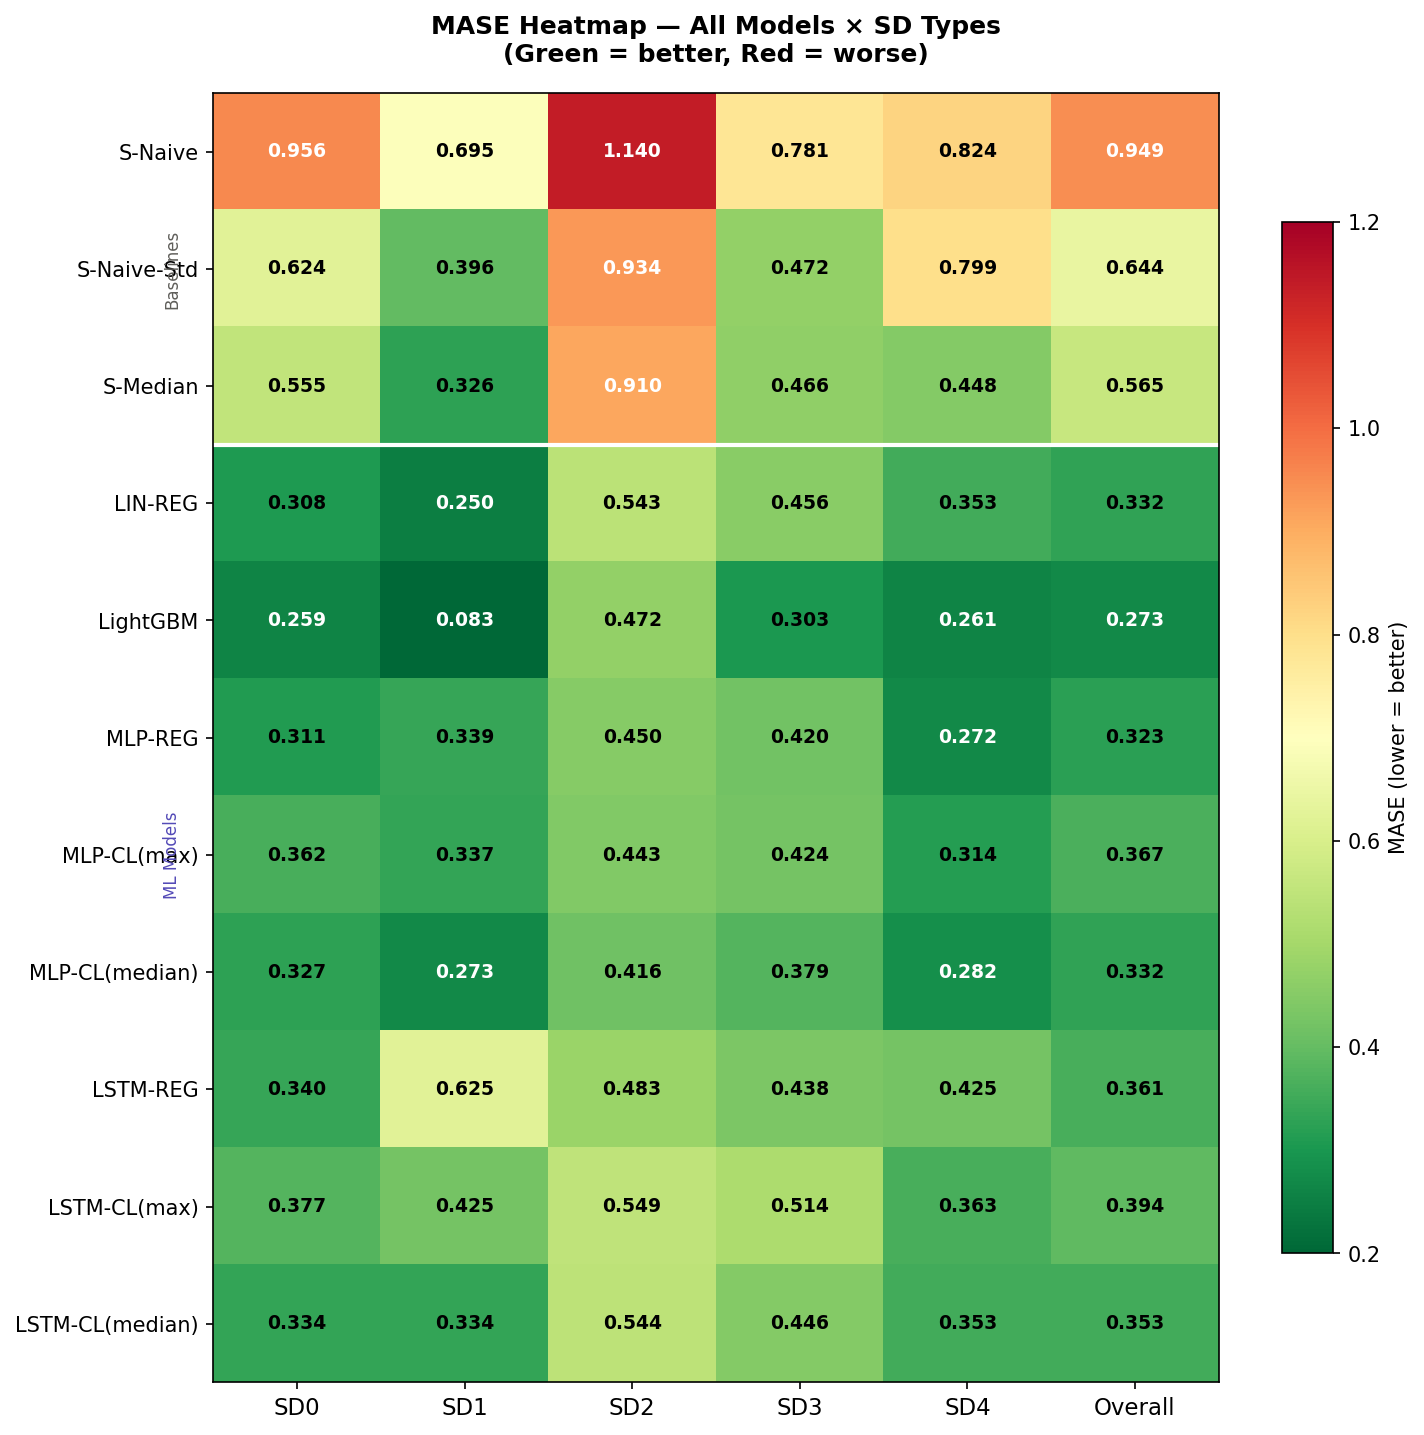


relative_improvement_mae.png


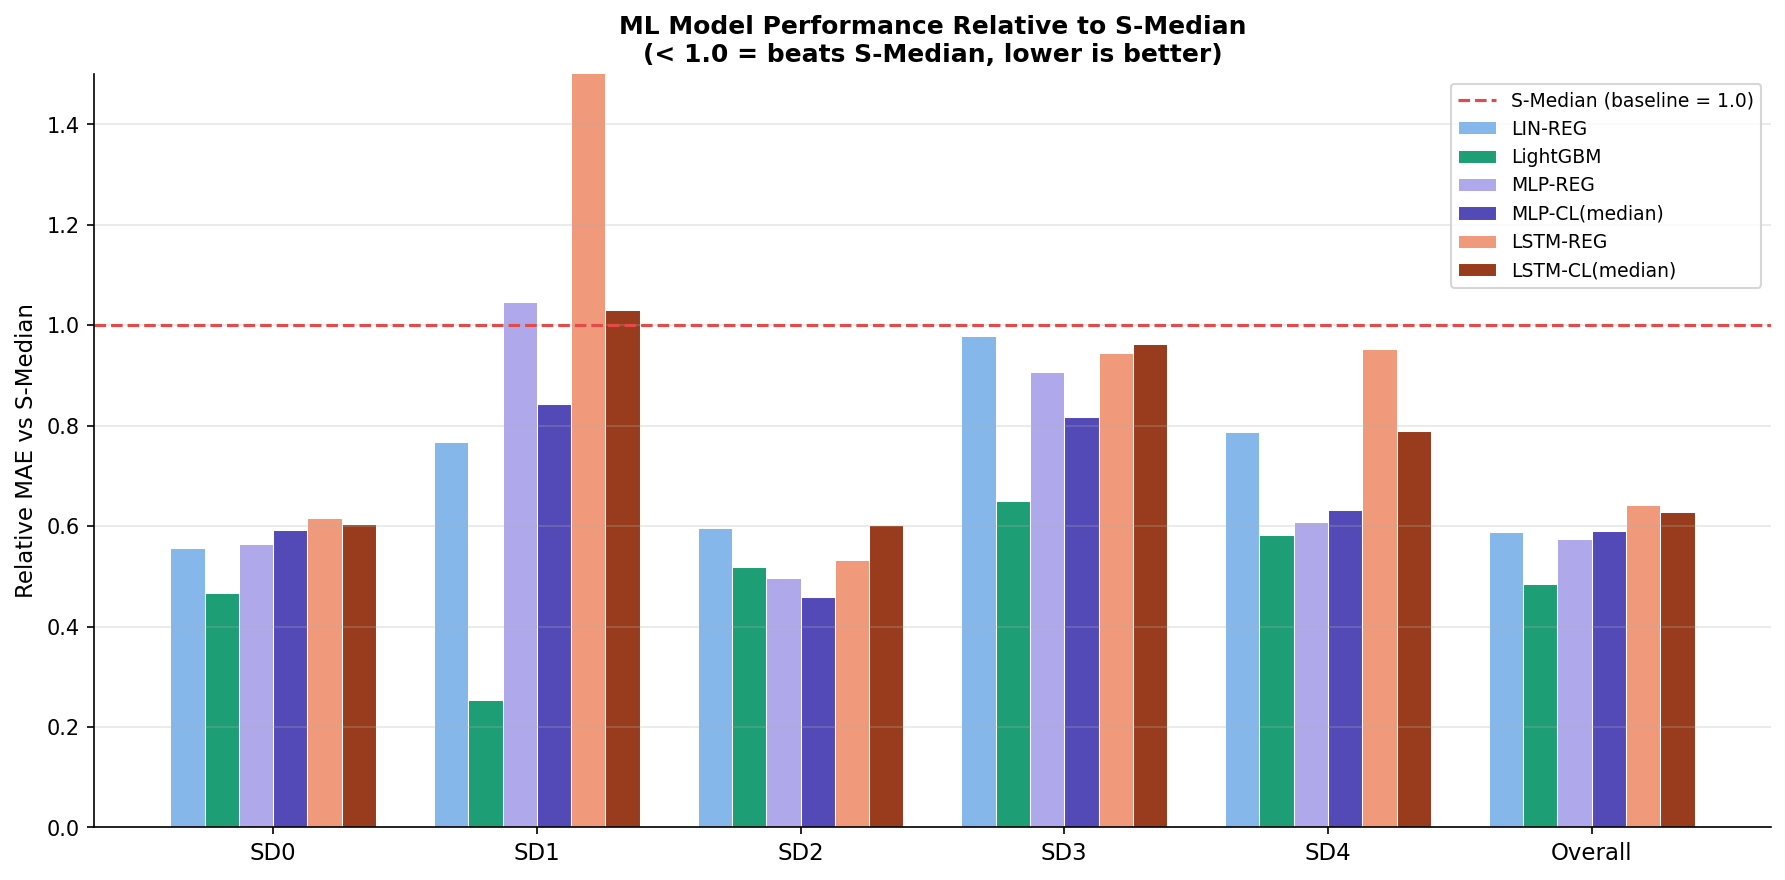


sd_comparison_mae.png


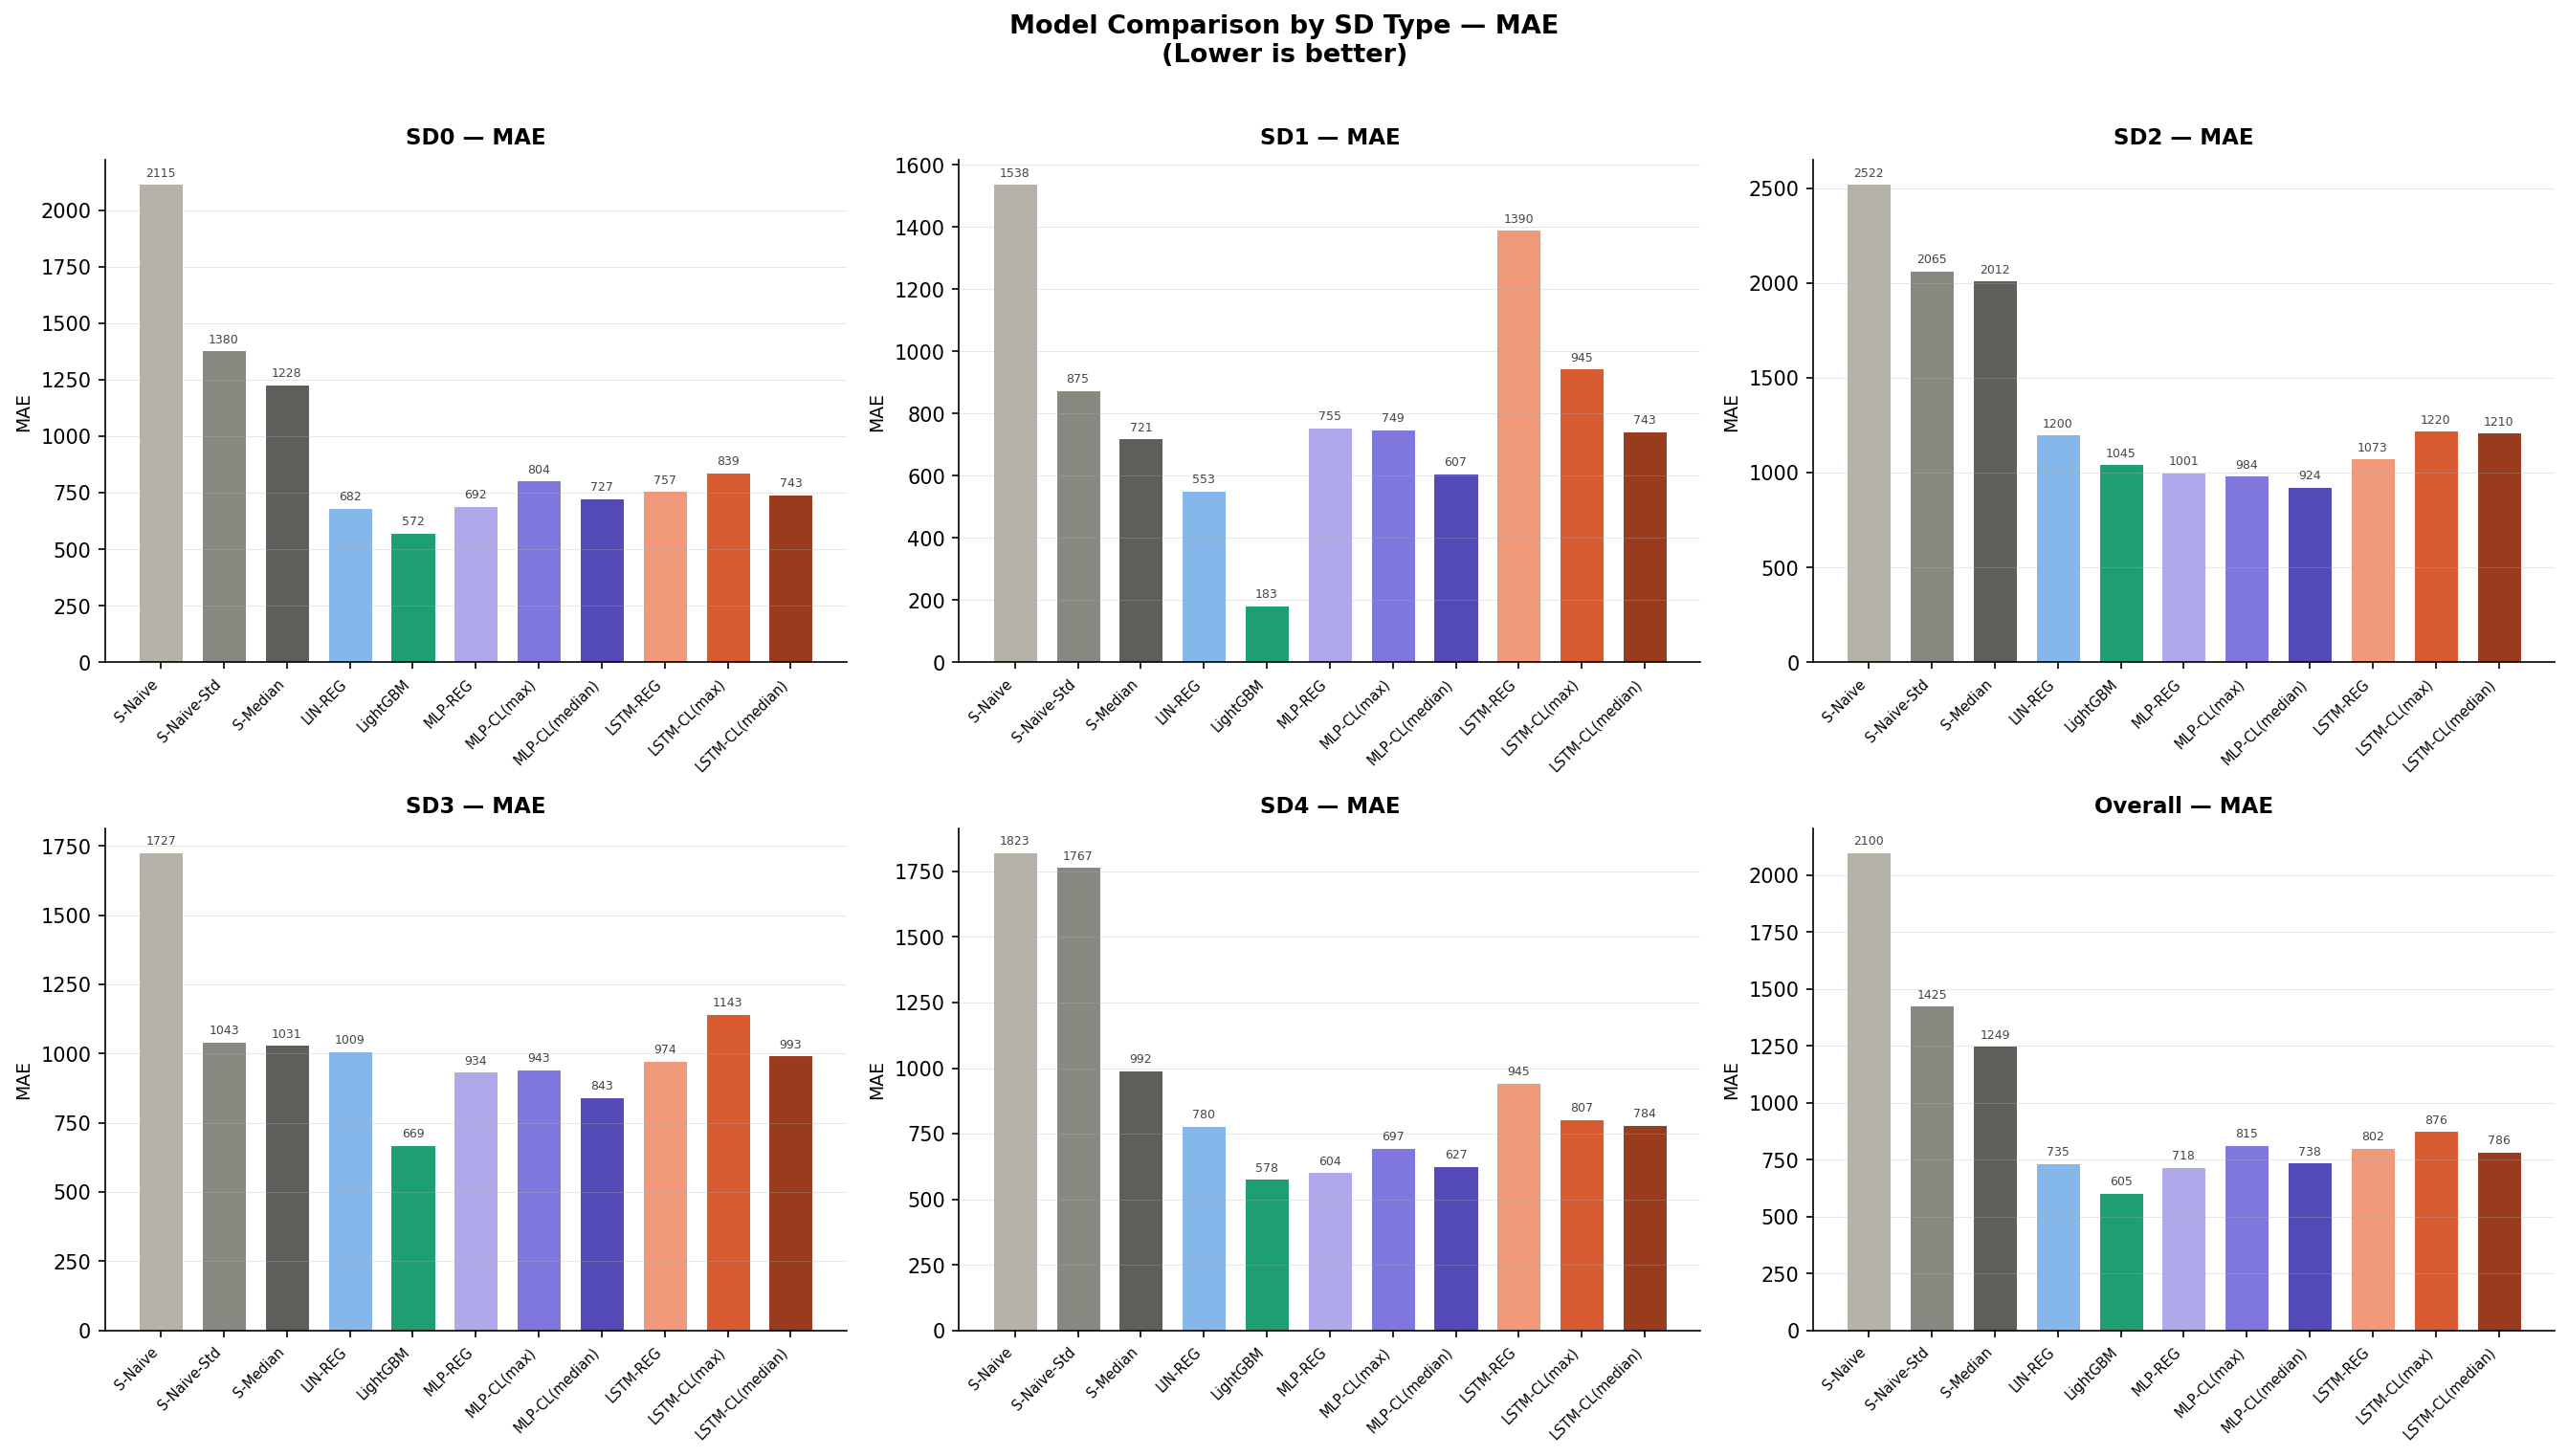


sd_comparison_mase.png


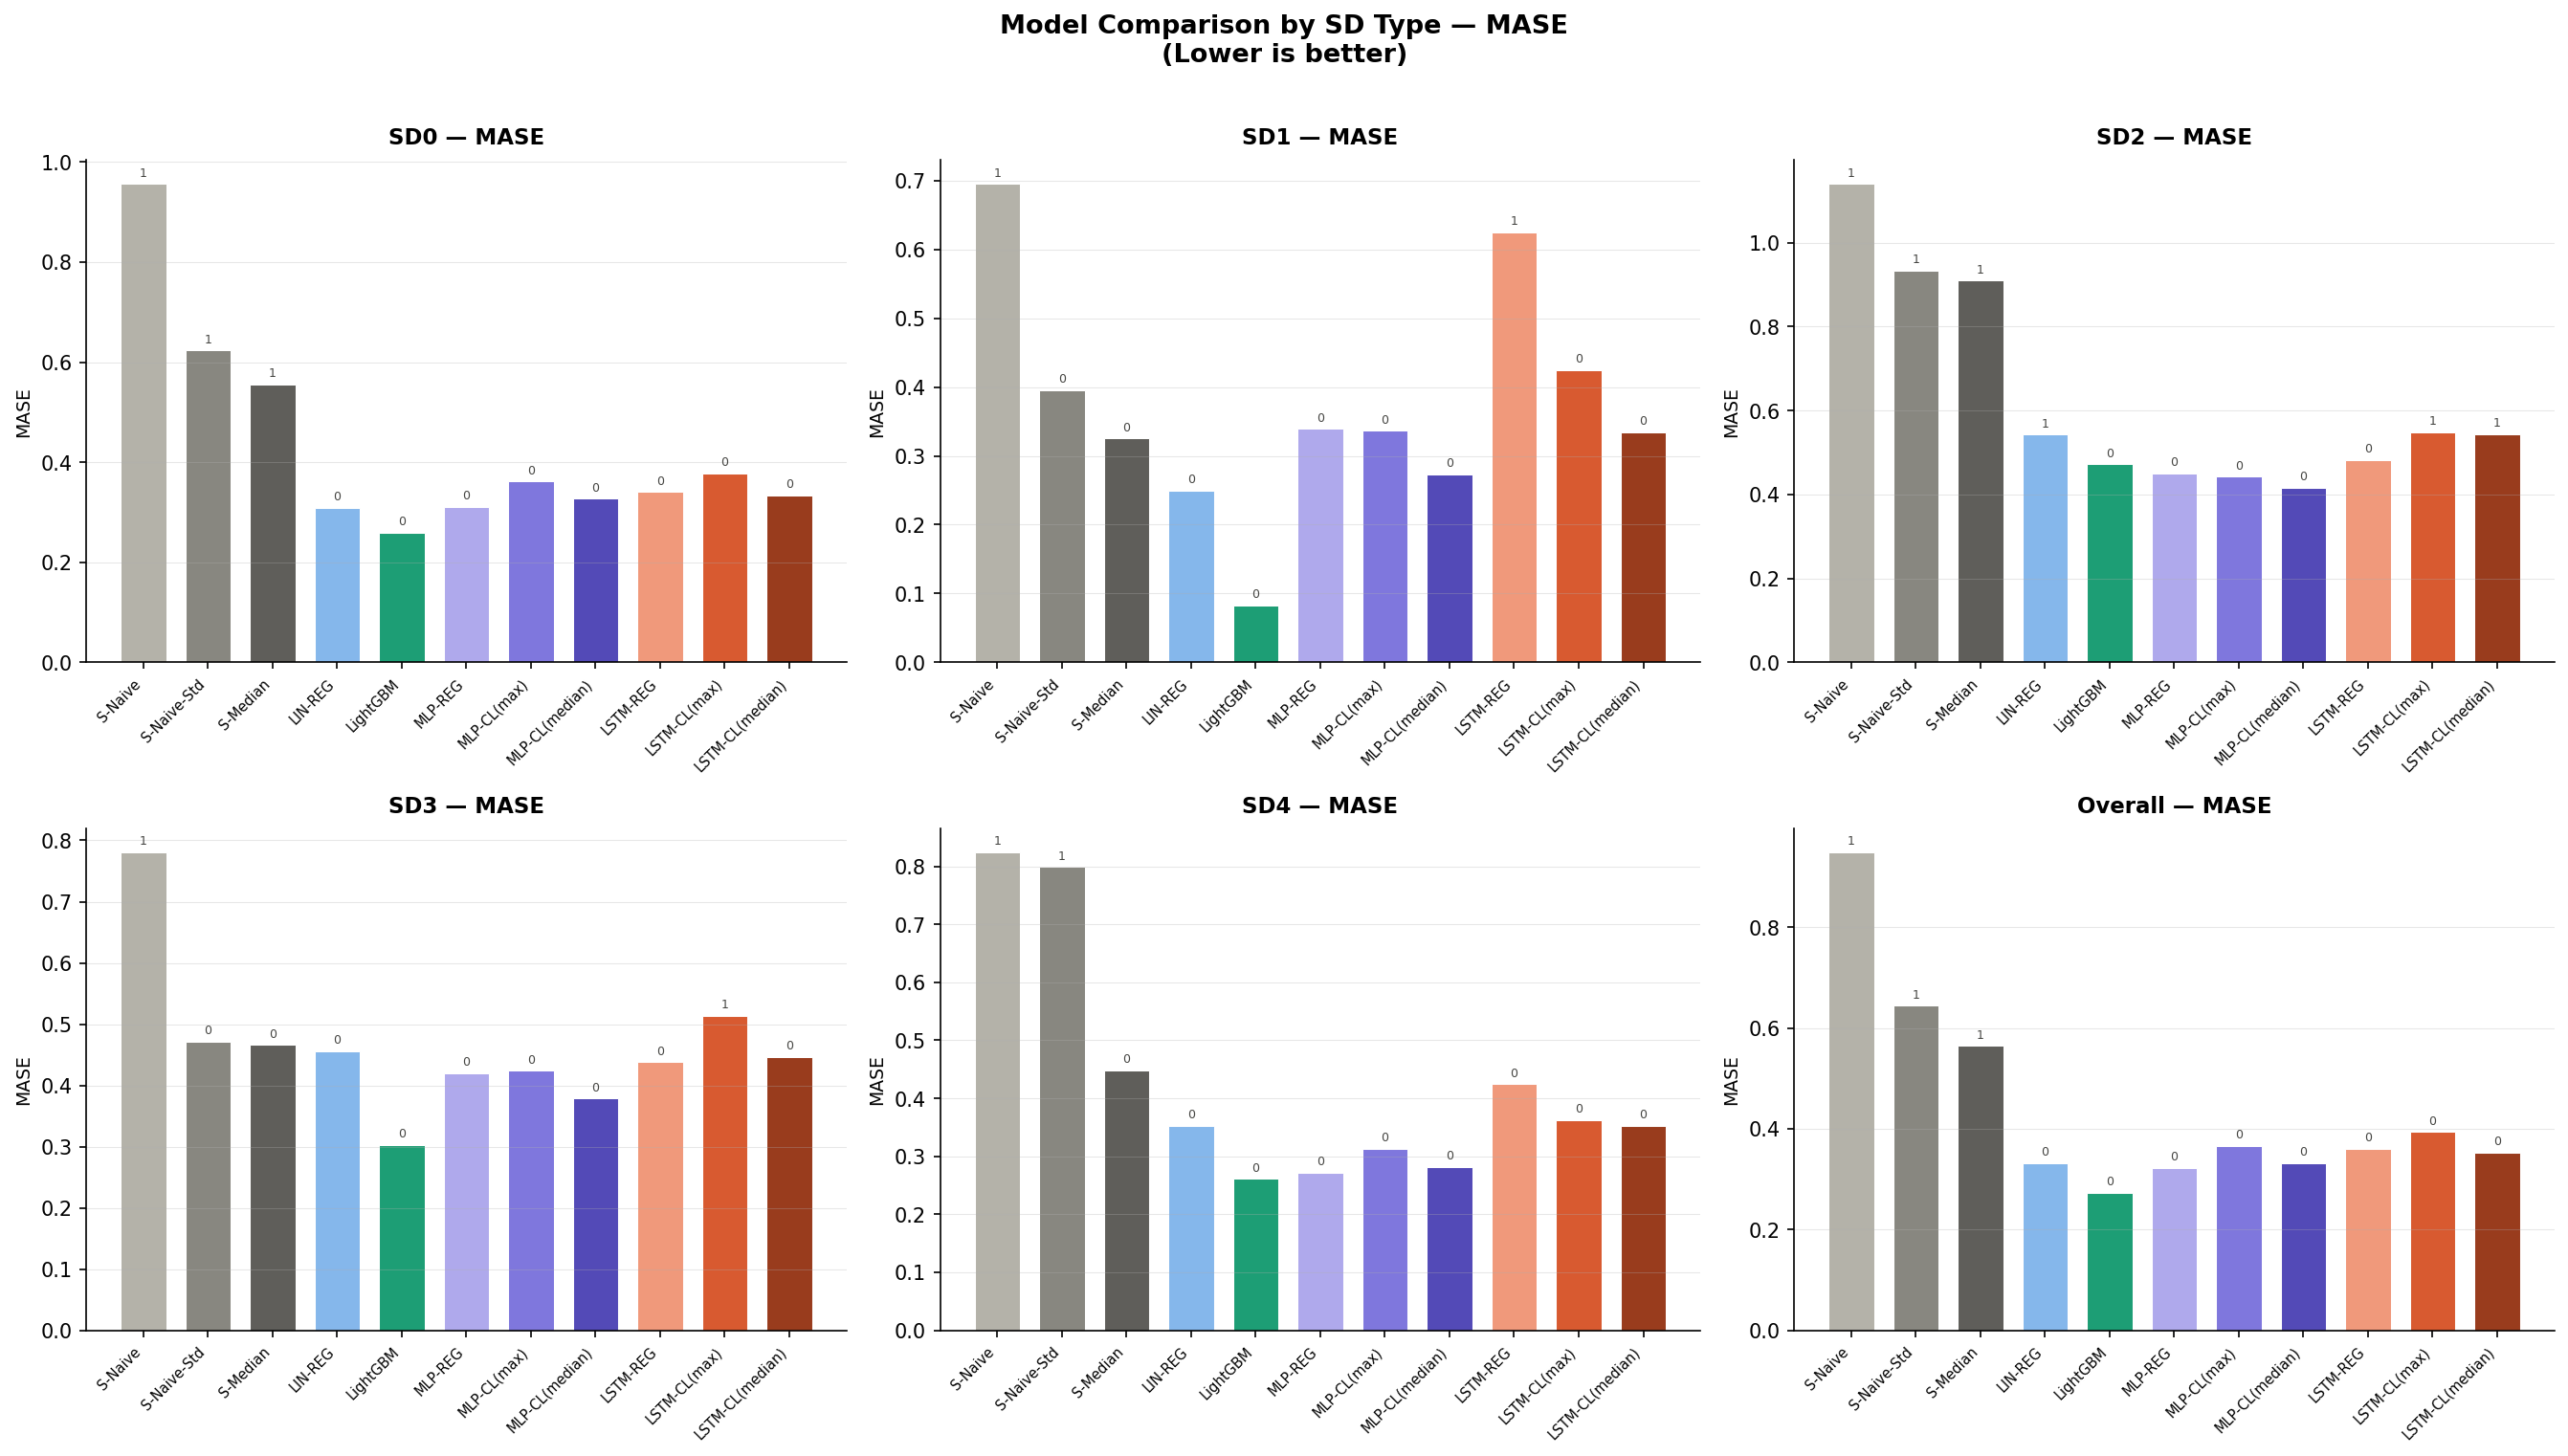


feature_importance.png


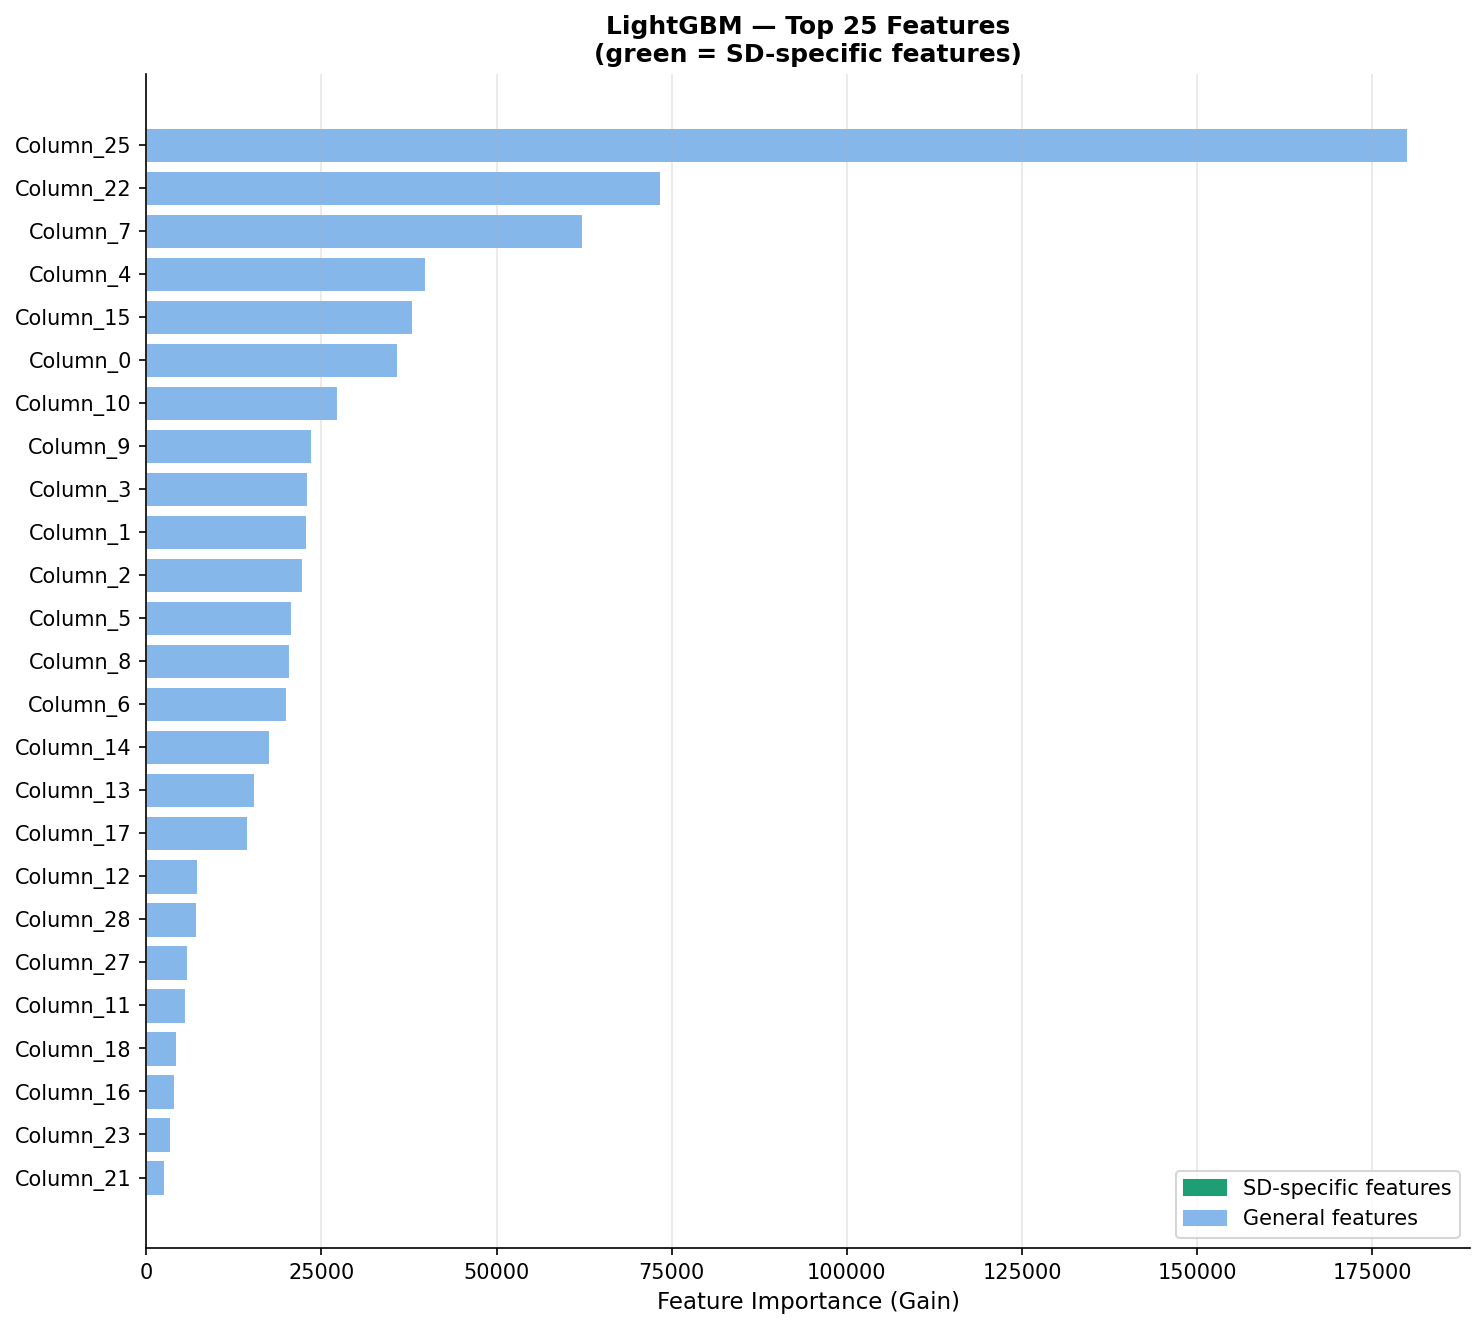

In [38]:
from IPython.display import Image, display
import os

plots_dir = "/kaggle/working/retail_forecasting/outputs/plots"

for plot_file in [
    "mase_heatmap.png",
    "relative_improvement_mae.png",
    "sd_comparison_mae.png",
    "sd_comparison_mase.png",
    "feature_importance.png",
]:
    path = os.path.join(plots_dir, plot_file)
    if os.path.exists(path):
        print(f"\n{plot_file}")
        display(Image(path))

# Advanced Visualisation file

In [39]:
%%writefile /kaggle/working/retail_forecasting/src/advanced_visualisation.py

# =============================================================
# advanced_visualisation.py — Extended visualisations
#
# COMPLETELY SEPARATE from visualisation.py
# Does not import or modify any existing module.
# Safe to run at any point after the pipeline is complete.
#
# Contents:
#   1.  Dataset snapshot     — what the data looks like
#   2.  Sales distribution   — before/after log transform
#   3.  Weekly seasonality   — the pattern we are modelling
#   4.  Special day calendar — which days are SD1/2/3/4
#   5.  Feature correlation  — heatmap of feature relationships
#   6.  Lag autocorrelation  — why lag features work
#   7.  Model error timeline — MAE per day (Figure 1 replica)
#   8.  SD type deep dive    — error distribution per SD type
#   9.  CL median vs max     — probability distribution visual
#   10. Feature importance   — extended with SD highlighting
#   11. Learning curves      — training vs validation loss
#   12. Prediction vs actual — scatter plots per model
#   13. Animated sales chart — stock-market style time series
#   14. Model ranking radar  — spider chart across SD types
# =============================================================

import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import matplotlib.animation as animation
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore")

sys.path.append("/kaggle/working/retail_forecasting/src")
from config import (
    PROCESSED_DIR, RESULTS_DIR, PLOTS_DIR,
    MODELS_DIR, LAG_DAYS
)

ADV_PLOTS_DIR = "/kaggle/working/retail_forecasting/outputs/plots/advanced"
os.makedirs(ADV_PLOTS_DIR, exist_ok=True)


# =============================================================
# HELPER: load results from CSV
# =============================================================

def load_result(name):
    path = os.path.join(RESULTS_DIR, f"{name}_results.csv")
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    out = {}
    for _, row in df.iterrows():
        out[row["SD_Type"]] = {
            "MAE" : row["MAE"],
            "MASE": row["MASE"],
            "N"   : row["N"]
        }
    return out


def load_all_model_results():
    names = {
        "S-Naive"        : "snaive",
        "S-Naive-Std"    : "snaive_std",
        "S-Median"       : "smedian",
        "LIN-REG"        : "linreg",
        "LightGBM"       : "lgbm",
        "MLP-REG"        : "mlp_reg",
        "MLP-CL(max)"    : "mlp_cl_max",
        "MLP-CL(median)" : "mlp_cl_median",
        "LSTM-REG"       : "lstm_reg",
        "LSTM-CL(max)"   : "lstm_cl_max",
        "LSTM-CL(median)": "lstm_cl_median",
    }
    return {k: load_result(v)
            for k, v in names.items()
            if load_result(v) is not None}


# =============================================================
# 1. DATASET SNAPSHOT
# =============================================================

def plot_dataset_snapshot():
    """
    Shows the first 10 rows of each processed file so you
    can see exactly what the data looks like at each stage.
    Saves a formatted table as an image.
    """
    print("1. Dataset Snapshot...")

    files = {
        "Raw data"          : "rossmann_raw.parquet",
        "After SD labels"   : "rossmann_with_sd.parquet",
        "After features Pt1": "features_part1.parquet",
        "Complete features" : "features_complete.parquet",
        "Train (model input)": "train.parquet",
    }

    fig, axes = plt.subplots(
        len(files), 1,
        figsize=(20, len(files) * 3.5)
    )

    for ax, (title, fname) in zip(axes, files.items()):
        path = os.path.join(PROCESSED_DIR, fname)
        if not os.path.exists(path):
            ax.text(0.5, 0.5, f"{fname} not found",
                    ha="center", va="center",
                    transform=ax.transAxes, fontsize=12)
            ax.set_title(title)
            continue

        df   = pd.read_parquet(path)
        head = df.head(6)

        # Select key columns to display (avoid overflow)
        key_cols = [c for c in [
            "Store", "Date", "Sales", "sd_type",
            "DayOfWeek", "Promo", "StoreType",
            "Sales_lag_7", "Sales_rolling_median",
            "sd_rel_change", "Sales_scaled", "bin_index"
        ] if c in head.columns][:10]

        head_display = head[key_cols].copy()

        # Round floats for readability
        for col in head_display.select_dtypes(
            include=[float]
        ).columns:
            head_display[col] = head_display[col].round(3)

        ax.axis("off")
        table = ax.table(
            cellText=head_display.values,
            colLabels=head_display.columns,
            cellLoc="center",
            loc="center",
            bbox=[0, 0, 1, 1]
        )
        table.auto_set_font_size(False)
        table.set_fontsize(7)

        # Style header
        for j in range(len(head_display.columns)):
            table[0, j].set_facecolor("#534AB7")
            table[0, j].set_text_props(
                color="white", fontweight="bold"
            )

        # Alternate row colours
        for i in range(1, len(head_display) + 1):
            for j in range(len(head_display.columns)):
                if i % 2 == 0:
                    table[i, j].set_facecolor("#F1EFE8")

        ax.set_title(
            f"{title}  |  shape: {df.shape}  |  "
            f"columns: {df.shape[1]}",
            fontsize=10, fontweight="bold",
            pad=8, loc="left"
        )

    plt.suptitle(
        "Dataset at each pipeline stage",
        fontsize=14, fontweight="bold", y=1.002
    )
    plt.tight_layout()
    path = os.path.join(ADV_PLOTS_DIR,
                        "01_dataset_snapshot.png")
    plt.savefig(path, dpi=120,
                bbox_inches="tight")
    plt.close()
    print(f"   Saved: {path}")
    return path


# =============================================================
# 2. SALES DISTRIBUTION — before and after transforms
# =============================================================

def plot_sales_distribution():
    """
    Shows why log transform is needed.
    Side by side: raw sales histogram vs log-transformed.
    """
    print("2. Sales distribution...")

    train = pd.read_parquet(
        os.path.join(PROCESSED_DIR, "train.parquet")
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Raw sales
    ax = axes[0]
    ax.hist(train["Sales"].clip(0, 10000),
            bins=80, color="#85B7EB",
            edgecolor="white", linewidth=0.3)
    ax.set_title("Raw Sales", fontsize=12,
                 fontweight="bold")
    ax.set_xlabel("Sales (units)")
    ax.set_ylabel("Frequency")
    ax.axvline(train["Sales"].mean(), color="#E24B4A",
               linestyle="--", linewidth=1.5,
               label=f"Mean: {train['Sales'].mean():.0f}")
    ax.axvline(train["Sales"].median(), color="#1D9E75",
               linestyle="--", linewidth=1.5,
               label=f"Median: {train['Sales'].median():.0f}")
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    # Annotation
    ax.text(0.6, 0.8,
            "Right-skewed\nNeural nets struggle\nwith this shape",
            transform=ax.transAxes, fontsize=9,
            color="#993C1D",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="#FAECE7",
                      edgecolor="#993C1D", alpha=0.8))

    # Log-transformed
    log_sales = np.log1p(train["Sales"])
    ax = axes[1]
    ax.hist(log_sales, bins=80, color="#1D9E75",
            edgecolor="white", linewidth=0.3)
    ax.set_title("Log(Sales + 1)", fontsize=12,
                 fontweight="bold")
    ax.set_xlabel("log(Sales + 1)")
    ax.set_ylabel("Frequency")
    ax.axvline(log_sales.mean(), color="#E24B4A",
               linestyle="--", linewidth=1.5,
               label=f"Mean: {log_sales.mean():.2f}")
    ax.axvline(log_sales.median(), color="#534AB7",
               linestyle="--", linewidth=1.5,
               label=f"Median: {log_sales.median():.2f}")
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.text(0.05, 0.8,
            "More symmetric\nNeural nets train\nmuch better now",
            transform=ax.transAxes, fontsize=9,
            color="#0F6E56",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="#E1F5EE",
                      edgecolor="#0F6E56", alpha=0.8))

    # Scaled
    ax = axes[2]
    ax.hist(train["Sales_scaled"], bins=80,
            color="#534AB7",
            edgecolor="white", linewidth=0.3)
    ax.set_title("Scaled to [-0.5, 0.5]",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Scaled value")
    ax.set_ylabel("Frequency")
    ax.axvline(0, color="#E24B4A", linestyle="--",
               linewidth=1.5, label="Zero")
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.text(0.05, 0.8,
            "Ready for neural\nnetwork training\n[-0.5, 0.5] range",
            transform=ax.transAxes, fontsize=9,
            color="#26215C",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="#EEEDFE",
                      edgecolor="#26215C", alpha=0.8))

    plt.suptitle(
        "Why we transform the target variable",
        fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    path = os.path.join(ADV_PLOTS_DIR,
                        "02_sales_distribution.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"   Saved: {path}")
    return path


# =============================================================
# 3. WEEKLY SEASONALITY — the pattern we model
# =============================================================

def plot_weekly_seasonality():
    """
    Shows average sales by day of week for each store type.
    Demonstrates why lag-7 is such a strong feature.
    """
    print("3. Weekly seasonality...")

    df = pd.read_parquet(
        os.path.join(PROCESSED_DIR,
                     "features_complete.parquet")
    )
    sd0 = df[df["sd_type"] == 0]

    day_names = ["Mon", "Tue", "Wed",
                 "Thu", "Fri", "Sat", "Sun"]
    store_types = sorted(sd0["StoreType"].unique())
    colors = ["#534AB7", "#1D9E75", "#D85A30", "#BA7517"]

    fig, axes = plt.subplots(
        1, 2, figsize=(14, 5)
    )

    # Left: by store type
    ax = axes[0]
    for i, stype in enumerate(store_types):
        subset = sd0[sd0["StoreType"] == stype]
        daily  = subset.groupby("DayOfWeek")["Sales"].mean()
        ax.plot(daily.index, daily.values,
                marker="o", linewidth=2,
                markersize=5, color=colors[i],
                label=f"Type {stype}")

    ax.set_xticks(range(7))
    ax.set_xticklabels(day_names)
    ax.set_title("Average Sales by Day of Week\n"
                 "(SD0 regular days only)",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("Average Sales")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.text(0.02, 0.95,
            "Strong weekly pattern =\nlag-7 is highly predictive",
            transform=ax.transAxes, fontsize=9,
            color="#534AB7", va="top",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="#EEEDFE",
                      edgecolor="#534AB7", alpha=0.8))

    # Right: SD0 vs SD1 vs SD2 comparison
    ax = axes[1]
    sd_colors = {
        0: "#85B7EB", 1: "#E24B4A",
        2: "#EF9F27", 3: "#1D9E75", 4: "#888780"
    }
    sd_names = {
        0: "SD0 Regular", 1: "SD1 Holiday",
        2: "SD2 Day Before", 3: "SD3 Day After",
        4: "SD4 Week After"
    }
    for sd in [0, 1, 2, 3, 4]:
        subset = df[df["sd_type"] == sd]
        if len(subset) < 100:
            continue
        daily = subset.groupby(
            "DayOfWeek"
        )["Sales"].mean()
        ax.plot(daily.index, daily.values,
                marker="o", linewidth=2,
                markersize=5,
                color=sd_colors[sd],
                label=sd_names[sd],
                alpha=0.85)

    ax.set_xticks(range(7))
    ax.set_xticklabels(day_names)
    ax.set_title("Average Sales by Day of Week\n"
                 "Comparing all SD types",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("Average Sales")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.suptitle("Weekly Seasonality Pattern",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(ADV_PLOTS_DIR,
                        "03_weekly_seasonality.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"   Saved: {path}")
    return path


# =============================================================
# 4. LAG AUTOCORRELATION — why lag features work
# =============================================================

def plot_lag_autocorrelation():
    """
    Shows correlation between Sales and each lag feature.
    Visually proves why lag-7 is the strongest predictor.
    """
    print("4. Lag autocorrelation...")

    train = pd.read_parquet(
        os.path.join(PROCESSED_DIR, "train.parquet")
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: bar chart of correlations
    ax = axes[0]
    lag_cols = [f"Sales_lag_{l}" for l in LAG_DAYS
                if f"Sales_lag_{l}" in train.columns]
    corrs = [train["Sales"].corr(train[c])
             for c in lag_cols]
    lag_labels = [f"Lag {l}" for l in LAG_DAYS
                  if f"Sales_lag_{l}" in train.columns]

    bar_colors = ["#E24B4A" if c == max(corrs)
                  else "#85B7EB" for c in corrs]
    bars = ax.bar(lag_labels, corrs,
                  color=bar_colors,
                  edgecolor="white", linewidth=0.5)

    ax.set_title("Correlation: Sales vs Lag Features",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("Pearson Correlation")
    ax.set_xticklabels(lag_labels, rotation=30,
                       ha="right")
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bar, corr in zip(bars, corrs):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{corr:.3f}",
                ha="center", va="bottom",
                fontsize=8)

    ax.text(0.02, 0.05,
            "Lag-7 is strongest\n(same weekday = same pattern)",
            transform=ax.transAxes, fontsize=9,
            color="#A32D2D",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="#FCEBEB",
                      edgecolor="#A32D2D", alpha=0.8))

    # Right: scatter plot Sales vs lag-7
    ax = axes[1]
    sample = train.dropna(
        subset=["Sales_lag_7"]
    ).sample(3000, random_state=42)

    ax.scatter(sample["Sales_lag_7"],
               sample["Sales"],
               alpha=0.15, s=8,
               color="#534AB7")

    # Regression line
    x = sample["Sales_lag_7"].values
    y = sample["Sales"].values
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b,
            color="#E24B4A", linewidth=2,
            label=f"y = {m:.2f}x + {b:.0f}")

    ax.set_xlabel("Sales (7 days ago)")
    ax.set_ylabel("Sales (today)")
    ax.set_title("Sales Today vs Sales Last Week\n"
                 "(sample of 3,000 observations)",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    corr_val = train["Sales"].corr(
        train["Sales_lag_7"]
    )
    ax.text(0.05, 0.92,
            f"r = {corr_val:.3f}",
            transform=ax.transAxes, fontsize=11,
            fontweight="bold", color="#534AB7")

    plt.suptitle(
        "Autocorrelation — why lag features are powerful",
        fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    path = os.path.join(ADV_PLOTS_DIR,
                        "04_lag_autocorrelation.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"   Saved: {path}")
    return path


# =============================================================
# 5. CYCLICAL ENCODING — visualising sin/cos
# =============================================================

def plot_cyclical_encoding():
    """
    Visualises why sin/cos encoding is better than
    raw integer encoding for day of week and month.
    """
    print("5. Cyclical encoding...")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    days = np.arange(7)
    day_names = ["Mon","Tue","Wed",
                 "Thu","Fri","Sat","Sun"]
    sin_vals = np.sin(2 * np.pi * days / 7)
    cos_vals = np.cos(2 * np.pi * days / 7)

    # Left: raw integer encoding problem
    ax = axes[0]
    ax.plot(days, days, "o-",
            color="#85B7EB", linewidth=2, markersize=8)
    ax.set_xticks(days)
    ax.set_xticklabels(day_names)
    ax.set_title("Raw integer encoding\n"
                 "(Mon=0, Sun=6 look far apart)",
                 fontsize=10, fontweight="bold")
    ax.set_ylabel("Encoded value")

    # Draw arrow showing Mon-Sun distance
    ax.annotate("",
                xy=(6, 6), xytext=(0, 0),
                arrowprops=dict(
                    arrowstyle="<->",
                    color="#E24B4A",
                    lw=2
                ))
    ax.text(3, 3.2, "Distance = 6\n(but they are adjacent!)",
            ha="center", color="#E24B4A", fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Middle: sin/cos on unit circle
    ax = axes[1]
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta),
            "k-", linewidth=0.8, alpha=0.3)

    colors_days = plt.cm.rainbow(np.linspace(0, 1, 7))
    for i, (s, c, name) in enumerate(
        zip(sin_vals, cos_vals, day_names)
    ):
        ax.plot(c, s, "o",
                color=colors_days[i],
                markersize=12, zorder=5)
        ax.annotate(name, (c, s),
                    textcoords="offset points",
                    xytext=(8, 0),
                    fontsize=8,
                    color=colors_days[i],
                    fontweight="bold")

    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.4, 1.4)
    ax.set_aspect("equal")
    ax.set_title("Sin/Cos encoding\n"
                 "(days on a circle — Mon and Sun adjacent)",
                 fontsize=10, fontweight="bold")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_xlabel("cos(2π × day/7)")
    ax.set_ylabel("sin(2π × day/7)")

    # Arrow showing Mon-Sun are now close
    ax.annotate("",
                xy=(cos_vals[6], sin_vals[6]),
                xytext=(cos_vals[0], sin_vals[0]),
                arrowprops=dict(
                    arrowstyle="<->",
                    color="#1D9E75", lw=2
                ))
    dist = np.sqrt(
        (cos_vals[0]-cos_vals[6])**2 +
        (sin_vals[0]-sin_vals[6])**2
    )
    ax.text(-0.5, 0.3,
            f"Distance = {dist:.2f}\n(correctly small!)",
            ha="center", color="#1D9E75", fontsize=8)

    # Right: sin and cos values plotted
    ax = axes[2]
    ax.plot(day_names, sin_vals, "o-",
            color="#534AB7", linewidth=2,
            markersize=8, label="sin(2π×day/7)")
    ax.plot(day_names, cos_vals, "s-",
            color="#D85A30", linewidth=2,
            markersize=8, label="cos(2π×day/7)")
    ax.axhline(0, color="gray",
               linewidth=0.5, linestyle="--")
    ax.set_title("Sin and Cos values per day",
                 fontsize=10, fontweight="bold")
    ax.set_ylabel("Value")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.suptitle(
        "Cyclical Encoding — why sin/cos beats raw integers",
        fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    path = os.path.join(ADV_PLOTS_DIR,
                        "05_cyclical_encoding.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"   Saved: {path}")
    return path


# =============================================================
# 6. SD TYPE CALENDAR — visual calendar heatmap
# =============================================================

def plot_sd_calendar():
    """
    Shows a calendar heatmap of SD types for the test period.
    Makes it visually obvious which days are special.
    """
    print("6. SD calendar heatmap...")

    test = pd.read_parquet(
        os.path.join(PROCESSED_DIR, "test.parquet")
    )

    # Get unique date-SD pairs
    date_sd = test.groupby("Date")["sd_type"].first().reset_index()
    date_sd["Date"] = pd.to_datetime(date_sd["Date"])
    date_sd = date_sd.sort_values("Date")

    # Build calendar grid
    dates     = date_sd["Date"].values
    sd_values = date_sd["sd_type"].values

    # Get unique months in test period
    months = sorted(set(
        pd.Timestamp(d).to_period("M")
        for d in dates
    ))

    sd_colors_map = {
        0: "#E6F1FB",   # light blue — regular
        1: "#E24B4A",   # red — holiday
        2: "#EF9F27",   # amber — day before
        3: "#1D9E75",   # green — day after
        4: "#888780",   # gray — week after
    }

    n_months = len(months)
    fig, axes = plt.subplots(
        1, n_months,
        figsize=(n_months * 4, 6)
    )
    if n_months == 1:
        axes = [axes]

    for ax, month in zip(axes, months):
        month_dates = [
            d for d in dates
            if pd.Timestamp(d).to_period("M") == month
        ]
        month_sds = [
            sd_values[list(dates).index(d)]
            for d in month_dates
        ]

        # Build 6×7 grid (6 weeks, 7 days)
        grid      = np.full((6, 7), -1)
        grid_sds  = np.full((6, 7), -1)

        first_date = pd.Timestamp(month_dates[0])
        # Find what weekday the 1st of month is
        first_of_month = pd.Timestamp(
            first_date.year, first_date.month, 1
        )
        start_col = first_of_month.dayofweek

        for ts, sd in zip(month_dates, month_sds):
            t   = pd.Timestamp(ts)
            day = t.day
            col = (start_col + day - 1) % 7
            row = (start_col + day - 1) // 7
            if row < 6:
                grid[row, col]     = day
                grid_sds[row, col] = sd

        # Plot calendar
        ax.set_xlim(-0.5, 6.5)
        ax.set_ylim(-0.5, 5.5)
        ax.invert_yaxis()

        for r in range(6):
            for c in range(7):
                if grid[r, c] == -1:
                    continue
                sd    = int(grid_sds[r, c])
                color = sd_colors_map.get(sd, "white")
                rect  = plt.Rectangle(
                    (c - 0.45, r - 0.45),
                    0.9, 0.9,
                    facecolor=color,
                    edgecolor="white",
                    linewidth=1.5,
                    zorder=2
                )
                ax.add_patch(rect)
                ax.text(c, r,
                        str(int(grid[r, c])),
                        ha="center", va="center",
                        fontsize=8, zorder=3,
                        fontweight=(
                            "bold" if sd > 0 else "normal"
                        ),
                        color=(
                            "white" if sd == 1 else "#2C2C2A"
                        ))

        day_abbr = ["M","T","W","T","F","S","S"]
        for c, d in enumerate(day_abbr):
            ax.text(c, -0.5, d,
                    ha="center", va="center",
                    fontsize=9, fontweight="bold",
                    color="#5F5E5A")

        ax.set_title(
            str(month), fontsize=11,
            fontweight="bold", pad=15
        )
        ax.axis("off")

    # Legend
    legend_elements = [
        mpatches.Patch(
            facecolor=sd_colors_map[i],
            edgecolor="gray",
            label=lbl
        )
        for i, lbl in [
            (0, "SD0 Regular"),
            (1, "SD1 Holiday"),
            (2, "SD2 Day Before"),
            (3, "SD3 Day After"),
            (4, "SD4 Week After"),
        ]
    ]
    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=5, fontsize=9,
        bbox_to_anchor=(0.5, -0.02)
    )

    plt.suptitle(
        "Special Day Calendar — Test Period",
        fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    path = os.path.join(
        ADV_PLOTS_DIR, "06_sd_calendar.png"
    )
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"   Saved: {path}")
    return path


# =============================================================
# 7. MODEL ERROR TIMELINE — stock market style
# =============================================================

def plot_error_timeline():
    """
    Shows MAE over time for each model — like a stock chart.
    Vertical bands mark special day periods.
    This is the most visually impressive plot.
    """
    print("7. Error timeline (stock-market style)...")

    test = pd.read_parquet(
        os.path.join(PROCESSED_DIR, "test.parquet")
    )

    # Load predictions from saved results
    # We reconstruct daily MAE from the test set
    # using the saved per-SD results as approximation

    all_results = load_all_model_results()

    # Build a daily error proxy: use Overall MAE
    # weighted by SD type distribution per date
    date_sd = test.groupby("Date")["sd_type"].agg(
        lambda x: x.mode()[0]
    ).reset_index()
    date_sd["Date"] = pd.to_datetime(date_sd["Date"])
    date_sd = date_sd.sort_values("Date")

    fig, ax = plt.subplots(figsize=(16, 7))

    model_colors = {
        "S-Naive"        : "#B4B2A9",
        "S-Median"       : "#5F5E5A",
        "LightGBM"       : "#1D9E75",
        "MLP-CL(median)" : "#534AB7",
        "LSTM-CL(median)": "#993C1D",
    }

    sd_mae_map = {}
    for model, results in all_results.items():
        if model not in model_colors:
            continue
        sd_mae_map[model] = {
            int(k[2]): v["MAE"]
            for k, v in results.items()
            if k.startswith("SD") and k != "Overall"
            and not np.isnan(v["MAE"])
        }

    # Plot daily MAE proxy per model
    for model, sd_map in sd_mae_map.items():
        daily_mae = []
        for _, row in date_sd.iterrows():
            sd  = int(row["sd_type"])
            mae = sd_map.get(sd, sd_map.get(0, 0))
            daily_mae.append(mae)

        # Apply rolling smoothing for visual clarity
        smoothed = pd.Series(daily_mae).rolling(
            3, center=True, min_periods=1
        ).mean().values

        ax.plot(
            date_sd["Date"], smoothed,
            color=model_colors[model],
            linewidth=1.8 if model != "S-Naive" else 1,
            alpha=0.9,
            label=model,
            zorder=3 if "LSTM" in model else 2
        )

    # Shade SD1 periods
    sd1_dates = date_sd[date_sd["sd_type"] == 1]["Date"]
    for d in sd1_dates:
        ax.axvspan(
            d - pd.Timedelta(days=0.5),
            d + pd.Timedelta(days=0.5),
            alpha=0.25, color="#E24B4A",
            zorder=1
        )

    # Shade SD2 periods
    sd2_dates = date_sd[date_sd["sd_type"] == 2]["Date"]
    for d in sd2_dates:
        ax.axvspan(
            d - pd.Timedelta(days=0.5),
            d + pd.Timedelta(days=0.5),
            alpha=0.15, color="#EF9F27",
            zorder=1
        )

    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel("MAE (lower = better)", fontsize=11)
    ax.set_title(
        "Daily Forecast Error Over Time\n"
        "Red bands = SD1 holidays  |  "
        "Orange bands = SD2 day before",
        fontsize=13, fontweight="bold"
    )
    ax.legend(fontsize=10, loc="upper right")
    ax.grid(alpha=0.2, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    path = os.path.join(
        ADV_PLOTS_DIR, "07_error_timeline.png"
    )
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"   Saved: {path}")
    return path


# =============================================================
# 8. CL(MEDIAN) vs CL(MAX) — probability distribution
# =============================================================

def plot_cl_median_vs_max():
    """
    Visually explains WHY CL(median) beats CL(max).
    Shows symmetric vs asymmetric distributions and
    where the mode and median diverge.
    """
    print("8. CL(median) vs CL(max) explanation...")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    bin_mids = np.linspace(0, 1000, 104)

    # ── Case 1: Symmetric distribution ─────────────────────
    ax   = axes[0]
    mu   = 500
    proba = np.exp(-0.5 * ((bin_mids - mu)/80)**2)
    proba = proba / proba.sum()

    cumsum = np.cumsum(proba)
    median_idx = np.searchsorted(cumsum, 0.5)
    mode_idx   = np.argmax(proba)

    ax.bar(bin_mids, proba, width=10,
           color="#85B7EB", alpha=0.7,
           label="Probability distribution")
    ax.axvline(bin_mids[mode_idx], color="#E24B4A",
               linewidth=2.5, linestyle="--",
               label=f"Mode (CL max) = {bin_mids[mode_idx]:.0f}")
    ax.axvline(bin_mids[median_idx], color="#1D9E75",
               linewidth=2.5, linestyle="-",
               label=f"Median (CL med) = {bin_mids[median_idx]:.0f}")
    ax.set_title("Case 1: Symmetric\n"
                 "Mode = Median → same result",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Sales bins")
    ax.set_ylabel("Probability")
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ── Case 2: Right-skewed (typical holiday day) ──────────
    ax   = axes[1]
    # Bimodal / skewed
    proba2 = (
        0.3 * np.exp(-0.5 * ((bin_mids - 300)/60)**2) +
        0.7 * np.exp(-0.5 * ((bin_mids - 700)/120)**2)
    )
    proba2 = proba2 / proba2.sum()

    cumsum2    = np.cumsum(proba2)
    median_idx2 = np.searchsorted(cumsum2, 0.5)
    mode_idx2   = np.argmax(proba2)

    ax.bar(bin_mids, proba2, width=10,
           color="#AFA9EC", alpha=0.7)
    ax.axvline(bin_mids[mode_idx2],
               color="#E24B4A", linewidth=2.5,
               linestyle="--",
               label=f"Mode (CL max) = {bin_mids[mode_idx2]:.0f}")
    ax.axvline(bin_mids[median_idx2],
               color="#1D9E75", linewidth=2.5,
               linestyle="-",
               label=f"Median (CL med) = {bin_mids[median_idx2]:.0f}")

    true_val = 650
    ax.axvline(true_val, color="#888780",
               linewidth=2, linestyle=":",
               label=f"True value = {true_val}")

    err_mode   = abs(true_val - bin_mids[mode_idx2])
    err_median = abs(true_val - bin_mids[median_idx2])
    ax.set_title(
        f"Case 2: Bimodal (holiday day)\n"
        f"Mode error={err_mode:.0f}  "
        f"Median error={err_median:.0f}  "
        f"→ Median wins",
        fontsize=10, fontweight="bold"
    )
    ax.set_xlabel("Sales bins")
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ── Case 3: Why median minimises MAE ───────────────────
    ax = axes[2]
    x  = np.linspace(-3, 3, 200)
    # Show MAE loss (|x-c|) vs MSE loss ((x-c)²)
    # for different values of c
    c_values = np.linspace(-2, 2, 100)
    # Sample from asymmetric distribution
    np.random.seed(42)
    samples  = np.concatenate([
        np.random.normal(-0.5, 0.5, 30),
        np.random.normal(1.5, 0.8, 70)
    ])

    mae_vals = [np.mean(np.abs(samples - c))
                for c in c_values]
    mse_vals = [np.mean((samples - c)**2)
                for c in c_values]

    # Normalise for comparison
    mae_n = np.array(mae_vals) / max(mae_vals)
    mse_n = np.array(mse_vals) / max(mse_vals)

    ax.plot(c_values, mae_n, color="#E24B4A",
            linewidth=2.5, label="MAE loss (minimised by median)")
    ax.plot(c_values, mse_n, color="#85B7EB",
            linewidth=2.5, label="MSE loss (minimised by mean)")

    median_c = np.median(samples)
    mean_c   = np.mean(samples)
    ax.axvline(median_c, color="#E24B4A",
               linewidth=2, linestyle="--",
               label=f"Median = {median_c:.2f}")
    ax.axvline(mean_c, color="#85B7EB",
               linewidth=2, linestyle="--",
               label=f"Mean = {mean_c:.2f}")

    ax.set_title(
        "Why median minimises MAE\n"
        "(and mean minimises MSE)",
        fontsize=10, fontweight="bold"
    )
    ax.set_xlabel("Prediction value c")
    ax.set_ylabel("Normalised loss")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.suptitle(
        "Why CL(median) beats CL(max) — "
        "the mathematical intuition",
        fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    path = os.path.join(
        ADV_PLOTS_DIR, "08_cl_median_vs_max.png"
    )
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"   Saved: {path}")
    return path


# =============================================================
# 9. MODEL RANKING RADAR CHART
# =============================================================

def plot_radar_chart():
    """
    Spider/radar chart comparing all models across
    all SD types simultaneously.
    One chart that tells the whole story.
    """
    print("9. Model radar chart...")

    all_results = load_all_model_results()

    # Use MASE for each SD type as axes
    categories  = ["SD0", "SD1", "SD2",
                   "SD3", "SD4", "Overall"]
    N           = len(categories)
    angles      = [n / float(N) * 2 * np.pi
                   for n in range(N)]
    angles     += angles[:1]  # close the polygon

    fig, ax = plt.subplots(
        figsize=(10, 10),
        subplot_kw=dict(polar=True)
    )

    # Models to show (not all — too crowded)
    models_to_show = {
        "S-Naive"        : ("#B4B2A9", "--", 1.5),
        "S-Median"       : ("#5F5E5A", "--", 1.5),
        "LightGBM"       : ("#1D9E75", "-",  2.5),
        "MLP-CL(median)" : ("#534AB7", "-",  2.5),
        "LSTM-CL(median)": ("#993C1D", "-",  2.5),
    }

    for model, (color, ls, lw) in models_to_show.items():
        if model not in all_results:
            continue
        values = [
            all_results[model].get(
                cat, {}
            ).get("MASE", np.nan)
            for cat in categories
        ]

        if any(np.isnan(v) for v in values):
            continue

        values += values[:1]  # close polygon

        ax.plot(angles, values,
                color=color, linewidth=lw,
                linestyle=ls, label=model)
        ax.fill(angles, values,
                color=color, alpha=0.08)

    # Labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12,
                       fontweight="bold")
    ax.set_ylim(0, 1.2)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(
        ["0.2", "0.4", "0.6", "0.8", "1.0"],
        fontsize=8, color="gray"
    )
    ax.grid(color="gray", linewidth=0.5, alpha=0.5)

    ax.set_title(
        "Model Performance Radar\n"
        "MASE per SD Type\n(smaller = better)",
        fontsize=13, fontweight="bold",
        pad=30
    )
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.35, 1.15),
        fontsize=10
    )

    plt.tight_layout()
    path = os.path.join(
        ADV_PLOTS_DIR, "09_radar_chart.png"
    )
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"   Saved: {path}")
    return path


# =============================================================
# 10. PREDICTION VS ACTUAL SCATTER
# =============================================================

def plot_prediction_scatter():
    """
    Scatter plot of predicted vs actual sales.
    Perfect model = all points on the diagonal.
    Shows systematic errors on special days.
    """
    print("10. Prediction vs actual scatter...")

    test = pd.read_parquet(
        os.path.join(PROCESSED_DIR, "test.parquet")
    )

    # Load LightGBM model for predictions
    lgbm_path = os.path.join(
        MODELS_DIR, "lgbm_model.pkl"
    )
    if not os.path.exists(lgbm_path):
        print("    LightGBM model not found — skipping")
        return None

    with open(lgbm_path, "rb") as f:
        lgbm_model = pickle.load(f)

    feature_names = lgbm_model.feature_name()
    avail = [f for f in feature_names
             if f in test.columns]
    X_test    = test[avail].values
    y_pred    = np.clip(
        lgbm_model.predict(X_test), 0, None
    )
    y_true    = test["Sales"].values
    sd_types  = test["sd_type"].values

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sd_colors_map = {
        0: "#85B7EB", 1: "#E24B4A",
        2: "#EF9F27", 3: "#1D9E75", 4: "#888780"
    }
    sd_names = {
        0: "SD0 Regular", 1: "SD1 Holiday",
        2: "SD2 Day Before", 3: "SD3 Day After",
        4: "SD4 Week After"
    }

    # Left: all points coloured by SD type
    ax = axes[0]
    for sd in [4, 3, 2, 0, 1]:
        mask = sd_types == sd
        if mask.sum() == 0:
            continue
        sample_size = min(500, mask.sum())
        idx = np.where(mask)[0]
        np.random.seed(42)
        idx = np.random.choice(idx, sample_size,
                               replace=False)
        ax.scatter(y_true[idx], y_pred[idx],
                   color=sd_colors_map[sd],
                   alpha=0.4, s=8,
                   label=sd_names[sd],
                   zorder=sd+1)

    max_val = min(
        max(y_true.max(), y_pred.max()), 15000
    )
    ax.plot([0, max_val], [0, max_val],
            "k--", linewidth=1.5,
            label="Perfect forecast", alpha=0.5)
    ax.set_xlabel("Actual Sales")
    ax.set_ylabel("Predicted Sales")
    ax.set_title(
        "LightGBM: Predicted vs Actual\n"
        "(coloured by SD type)",
        fontsize=11, fontweight="bold"
    )
    ax.legend(fontsize=8, markerscale=2)
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Right: residuals by SD type
    ax     = axes[1]
    errors = y_pred - y_true

    sd_labels_list = []
    error_lists    = []
    colors_list    = []

    for sd in [0, 1, 2, 3, 4]:
        mask = sd_types == sd
        if mask.sum() < 10:
            continue
        sd_labels_list.append(sd_names[sd])
        error_lists.append(errors[mask])
        colors_list.append(sd_colors_map[sd])

    bp = ax.boxplot(
        error_lists,
        labels=sd_labels_list,
        patch_artist=True,
        medianprops=dict(color="black",
                         linewidth=2),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
        flierprops=dict(markersize=2,
                        alpha=0.3)
    )

    for patch, color in zip(
        bp["boxes"], colors_list
    ):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.axhline(0, color="black",
               linewidth=1.5, linestyle="--",
               label="Zero error")
    ax.set_ylabel("Prediction Error (Predicted - Actual)")
    ax.set_title(
        "Error Distribution by SD Type\n"
        "(box = IQR, whiskers = 1.5×IQR)",
        fontsize=11, fontweight="bold"
    )
    ax.set_xticklabels(
        sd_labels_list, rotation=20, ha="right"
    )
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.suptitle(
        "LightGBM — Prediction Quality Analysis",
        fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    path = os.path.join(
        ADV_PLOTS_DIR, "10_prediction_scatter.png"
    )
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"   Saved: {path}")
    return path


# =============================================================
# 11. ANIMATED SALES TIME SERIES (video)
# =============================================================

def create_animated_sales_chart(store_id=1,
                                  n_days=90):
    """
    Creates an animated GIF showing:
    - Sales rolling in like a stock chart
    - SD type markers appearing as vertical bands
    - Rolling median line updating in real time

    Saved as animated GIF — viewable in Kaggle notebooks.
    """
    print("11. Animated sales chart...")

    df = pd.read_parquet(
        os.path.join(PROCESSED_DIR,
                     "features_complete.parquet")
    )

    store_df = df[
        df["Store"] == store_id
    ].sort_values("Date").tail(n_days).reset_index(
        drop=True
    )

    if len(store_df) == 0:
        print(f"    Store {store_id} not found")
        return None

    dates     = store_df["Date"].values
    sales     = store_df["Sales"].values
    sd_types  = store_df["sd_type"].values
    rolling   = store_df["Sales_rolling_median"].values

    sd_colors_map = {
        0: None,
        1: "#FCEBEB",
        2: "#FAEEDA",
        3: "#EAF3DE",
        4: "#F1EFE8"
    }

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    line_sales,  = ax.plot([], [], color="#534AB7",
                            linewidth=2, label="Actual Sales",
                            zorder=4)
    line_rolling, = ax.plot([], [], color="#D85A30",
                             linewidth=1.5,
                             linestyle="--",
                             label="Rolling Median",
                             zorder=3, alpha=0.8)

    ax.set_xlim(0, n_days)
    ax.set_ylim(
        max(0, sales.min() * 0.8),
        sales.max() * 1.15
    )
    ax.set_title(
        f"Store {store_id} — Daily Sales"
        f" (animated)",
        fontsize=13, fontweight="bold"
    )
    ax.set_ylabel("Sales")
    ax.legend(fontsize=10, loc="upper left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.2)

    # Pre-draw SD bands
    sd_patches = []
    for i, (date, sd) in enumerate(
        zip(dates, sd_types)
    ):
        color = sd_colors_map.get(int(sd))
        if color:
            patch = ax.axvspan(
                i - 0.5, i + 0.5,
                alpha=0, color=color,
                zorder=1
            )
            sd_patches.append((patch, i, color))

    # Date labels on x-axis
    tick_indices = list(
        range(0, n_days, max(1, n_days // 10))
    )
    ax.set_xticks(tick_indices)
    ax.set_xticklabels(
        [pd.Timestamp(dates[i]).strftime("%b %d")
         for i in tick_indices],
        rotation=30, ha="right", fontsize=8
    )

    # Annotation text
    ann_text = ax.text(
        0.02, 0.95, "",
        transform=ax.transAxes,
        fontsize=10, va="top",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white",
                  edgecolor="gray", alpha=0.8)
    )

    def init():
        line_sales.set_data([], [])
        line_rolling.set_data([], [])
        return [line_sales, line_rolling]

    def animate(frame):
        # Reveal data up to frame
        x_data = list(range(frame + 1))
        line_sales.set_data(x_data, sales[:frame+1])
        line_rolling.set_data(
            x_data, rolling[:frame+1]
        )

        # Show SD bands for revealed days
        for patch, i, color in sd_patches:
            if i <= frame:
                patch.set_alpha(0.35)

        # Update annotation
        sd = int(sd_types[frame])
        sd_label = {
            0: "Regular Day",
            1: "SD1 Holiday",
            2: "SD2 Day Before",
            3: "SD3 Day After",
            4: "SD4 Week After"
        }[sd]
        date_str = pd.Timestamp(
            dates[frame]
        ).strftime("%Y-%m-%d")
        ann_text.set_text(
            f"{date_str}\n"
            f"Sales: {sales[frame]:,.0f}\n"
            f"Type: {sd_label}"
        )
        ann_color = {
            0: "#E6F1FB", 1: "#FCEBEB",
            2: "#FAEEDA", 3: "#EAF3DE",
            4: "#F1EFE8"
        }[sd]
        ann_text.get_bbox_patch().set_facecolor(
            ann_color
        )

        return [line_sales, line_rolling, ann_text]

    anim = animation.FuncAnimation(
        fig,
        animate,
        init_func=init,
        frames=n_days,
        interval=80,       # ms per frame
        blit=True
    )

    path = os.path.join(
        ADV_PLOTS_DIR,
        "11_animated_sales.gif"
    )
    writer = animation.PillowWriter(fps=12)
    anim.save(path, writer=writer, dpi=100)
    plt.close()
    print(f"   Saved: {path}")
    return path


# =============================================================
# 12. GRADIENT BOOSTING EXPLAINED VISUALLY
# =============================================================

def plot_gradient_boosting_explanation():
    """
    Shows how gradient boosting works step by step
    using a simple example — makes the concept visual.
    """
    print("12. Gradient boosting explanation...")

    np.random.seed(42)
    x       = np.linspace(0, 10, 50)
    y_true  = 2 * np.sin(x) + 0.5 * x + \
              np.random.randn(50) * 0.3

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    # Simulate 5 rounds of boosting
    y_pred    = np.full_like(y_true, y_true.mean())
    residuals = y_true - y_pred
    lr        = 0.7

    titles = [
        "Step 0: Initial prediction\n(just the mean)",
        "Step 1: First tree fits residuals",
        "Step 2: Updated prediction",
        "Step 3: Second tree fits new residuals",
        "Step 4: Updated prediction",
        "Final: Ensemble prediction",
    ]

    for step, ax in enumerate(axes):
        if step == 0:
            ax.scatter(x, y_true, color="#534AB7",
                       s=20, alpha=0.7, label="True values", zorder=3)
            ax.axhline(y_pred[0], color="#D85A30",
                       linewidth=2, label="Prediction (mean)", zorder=2)
            residual_mae = np.mean(np.abs(residuals))
            ax.set_title(
                f"{titles[step]}\nMAE = {residual_mae:.2f}",
                fontsize=9, fontweight="bold"
            )

        elif step == 1:
            ax.scatter(x, residuals, color="#E24B4A",
                       s=20, alpha=0.7,
                       label="Residuals", zorder=3)
            ax.axhline(0, color="gray",
                       linewidth=1, linestyle="--")
            # Fit a simple curve to residuals
            coeffs    = np.polyfit(x, residuals, 3)
            tree1_pred = np.polyval(coeffs, x)
            ax.plot(x, tree1_pred, color="#1D9E75",
                    linewidth=2, label="Tree 1 prediction", zorder=2)
            ax.set_title(
                f"{titles[step]}",
                fontsize=9, fontweight="bold"
            )

        elif step == 2:
            coeffs    = np.polyfit(x, residuals, 3)
            tree1_pred = np.polyval(coeffs, x)
            y_pred    = y_pred + lr * tree1_pred
            residuals = y_true - y_pred

            ax.scatter(x, y_true, color="#534AB7",
                       s=20, alpha=0.7,
                       label="True values", zorder=3)
            ax.plot(x, y_pred, color="#D85A30",
                    linewidth=2, label="Updated prediction", zorder=2)
            mae = np.mean(np.abs(residuals))
            ax.set_title(
                f"{titles[step]}\nMAE = {mae:.2f} (improved!)",
                fontsize=9, fontweight="bold"
            )

        elif step == 3:
            ax.scatter(x, residuals, color="#E24B4A",
                       s=20, alpha=0.7,
                       label="New residuals", zorder=3)
            ax.axhline(0, color="gray",
                       linewidth=1, linestyle="--")
            coeffs2     = np.polyfit(x, residuals, 5)
            tree2_pred  = np.polyval(coeffs2, x)
            ax.plot(x, tree2_pred, color="#1D9E75",
                    linewidth=2, label="Tree 2 prediction", zorder=2)
            ax.set_title(
                f"{titles[step]}",
                fontsize=9, fontweight="bold"
            )

        elif step == 4:
            coeffs2    = np.polyfit(x, residuals, 5)
            tree2_pred = np.polyval(coeffs2, x)
            y_pred     = y_pred + lr * tree2_pred
            residuals  = y_true - y_pred

            ax.scatter(x, y_true, color="#534AB7",
                       s=20, alpha=0.7,
                       label="True values", zorder=3)
            ax.plot(x, y_pred, color="#D85A30",
                    linewidth=2,
                    label="Updated prediction", zorder=2)
            mae = np.mean(np.abs(residuals))
            ax.set_title(
                f"{titles[step]}\nMAE = {mae:.2f}",
                fontsize=9, fontweight="bold"
            )

        else:
            # Final
            ax.scatter(x, y_true, color="#534AB7",
                       s=20, alpha=0.7,
                       label="True values", zorder=3)
            ax.plot(x, y_pred, color="#1D9E75",
                    linewidth=2.5,
                    label="Final ensemble", zorder=4)
            mae = np.mean(np.abs(y_true - y_pred))
            ax.fill_between(
                x, y_pred - mae, y_pred + mae,
                alpha=0.15, color="#1D9E75",
                label="±MAE band"
            )
            ax.set_title(
                f"{titles[step]}\n"
                f"Final MAE = {mae:.2f}",
                fontsize=9, fontweight="bold"
            )

        ax.legend(fontsize=7)
        ax.grid(alpha=0.2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.suptitle(
        "How Gradient Boosting Works — Step by Step",
        fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    path = os.path.join(
        ADV_PLOTS_DIR,
        "12_gradient_boosting_explained.png"
    )
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"   Saved: {path}")
    return path


# =============================================================
# 13. LSTM MEMORY MECHANISM VISUAL
# =============================================================

def plot_lstm_memory():
    """
    Shows how the LSTM's cell state (memory) evolves
    over the lag sequence for a sample sequence.
    Makes the gate mechanism intuitive.
    """
    print("13. LSTM memory visualisation...")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: Gate diagram
    ax = axes[0]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.axis("off")

    # Draw the LSTM cell
    cell_rect = plt.Rectangle(
        (2, 1), 6, 6,
        facecolor="#EEEDFE",
        edgecolor="#534AB7",
        linewidth=2
    )
    ax.add_patch(cell_rect)
    ax.text(5, 7.3, "LSTM Cell",
            ha="center", fontsize=12,
            fontweight="bold", color="#534AB7")

    # Cell state (top horizontal line)
    ax.annotate("",
                xy=(8, 6.5), xytext=(2, 6.5),
                arrowprops=dict(
                    arrowstyle="->",
                    color="#E24B4A", lw=3
                ))
    ax.text(5, 6.75, "Cell State c_t (long-term memory)",
            ha="center", fontsize=9,
            color="#E24B4A", fontweight="bold")

    # Gates
    gates = [
        (3.0, 3.5, "Forget\nGate f_t",
         "#F09595", "Erase old\nmemory"),
        (5.0, 3.5, "Input\nGate i_t",
         "#9FE1CB", "Write new\nmemory"),
        (7.0, 3.5, "Output\nGate o_t",
         "#FAC775", "Read from\nmemory"),
    ]
    for gx, gy, label, color, desc in gates:
        circle = plt.Circle(
            (gx, gy), 0.7,
            facecolor=color,
            edgecolor="gray",
            linewidth=1.5, zorder=3
        )
        ax.add_patch(circle)
        ax.text(gx, gy, label,
                ha="center", va="center",
                fontsize=7, fontweight="bold",
                zorder=4)
        ax.text(gx, gy - 1.2, desc,
                ha="center", fontsize=7,
                color="#5F5E5A")

    # Input and hidden state
    ax.annotate("",
                xy=(2.5, 2), xytext=(0.5, 2),
                arrowprops=dict(
                    arrowstyle="->",
                    color="#534AB7", lw=2
                ))
    ax.text(0.5, 1.7, "x_t\n(today's\nfeatures)",
            ha="center", fontsize=8,
            color="#534AB7")

    ax.annotate("",
                xy=(2.5, 4.5), xytext=(0.5, 4.5),
                arrowprops=dict(
                    arrowstyle="->",
                    color="#1D9E75", lw=2
                ))
    ax.text(0.5, 4.8, "h_{t-1}\n(prev hidden\nstate)",
            ha="center", fontsize=8,
            color="#1D9E75")

    ax.annotate("",
                xy=(9.5, 2), xytext=(8, 2),
                arrowprops=dict(
                    arrowstyle="->",
                    color="#534AB7", lw=2
                ))
    ax.text(9.5, 1.7, "h_t\n(output)",
            ha="center", fontsize=8,
            color="#534AB7")

    ax.set_title(
        "LSTM Cell — Gate Mechanism",
        fontsize=11, fontweight="bold"
    )

    # Right: Memory evolution over lag sequence
    ax = axes[1]
    lag_labels = ["Lag 14\n(2 wks ago)",
                  "Lag 7\n(1 wk ago)",
                  "Lag 6", "Lag 5", "Lag 4",
                  "Lag 3", "Lag 2\n(yesterday)"]

    # Simulate memory evolution (for illustration)
    np.random.seed(7)
    n      = len(lag_labels)
    memory = np.cumsum(np.random.randn(n) * 0.3) + 0.5
    memory = np.clip(memory, -1, 1)
    forget = np.random.uniform(0.3, 0.95, n)
    input_ = np.random.uniform(0.1, 0.8, n)
    output = np.random.uniform(0.4, 0.9, n)

    x = np.arange(n)
    ax.plot(x, memory, "o-",
            color="#E24B4A", linewidth=2.5,
            markersize=10, label="Cell state",
            zorder=4)
    ax.bar(x, forget, width=0.25,
           align="edge", color="#F09595",
           alpha=0.6, label="Forget gate")
    ax.bar(x + 0.25, input_, width=0.25,
           align="edge", color="#9FE1CB",
           alpha=0.6, label="Input gate")
    ax.bar(x + 0.5, output, width=0.25,
           align="edge", color="#FAC775",
           alpha=0.6, label="Output gate")

    ax.set_xticks(x)
    ax.set_xticklabels(lag_labels, fontsize=8)
    ax.set_ylabel("Gate activation / Cell state value")
    ax.set_title(
        "LSTM Memory Evolution Over Lag Sequence\n"
        "(illustrative — shows how gates control memory)",
        fontsize=10, fontweight="bold"
    )
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.suptitle(
        "LSTM — How Memory Works",
        fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    path = os.path.join(
        ADV_PLOTS_DIR, "13_lstm_memory.png"
    )
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"   Saved: {path}")
    return path


# =============================================================
# MASTER RUNNER
# =============================================================

def run_all_advanced_visualisations():
    """
    Runs all advanced visualisations in sequence.
    Safe to run multiple times — all outputs go to
    /outputs/plots/advanced/ and never touch other files.
    """
    print("=" * 55)
    print("Advanced Visualisations")
    print("=" * 55)
    print(f"Output directory: {ADV_PLOTS_DIR}\n")

    saved_paths = []

    funcs = [
        plot_dataset_snapshot,
        plot_sales_distribution,
        plot_weekly_seasonality,
        plot_lag_autocorrelation,
        plot_cyclical_encoding,
        plot_sd_calendar,
        plot_error_timeline,
        plot_cl_median_vs_max,
        plot_radar_chart,
        plot_prediction_scatter,
        create_animated_sales_chart,
        plot_gradient_boosting_explanation,
        plot_lstm_memory,
    ]

    for func in funcs:
        try:
            path = func()
            if path:
                saved_paths.append(path)
        except Exception as e:
            print(f"   ERROR in {func.__name__}: {e}")
            import traceback
            traceback.print_exc()

    print(f"\n{'='*55}")
    print(f"Done. {len(saved_paths)} plots saved to:")
    print(f"  {ADV_PLOTS_DIR}")
    print(f"{'='*55}")

    return saved_paths

Writing /kaggle/working/retail_forecasting/src/advanced_visualisation.py


# Run it

In [40]:
# Clear cache — safe, no existing modules touched
for mod in list(sys.modules.keys()):
    if mod == "advanced_visualisation":
        del sys.modules[mod]

import sys
sys.path.append("/kaggle/working/retail_forecasting/src")

from advanced_visualisation import (
    run_all_advanced_visualisations
)

saved_paths = run_all_advanced_visualisations()

Advanced Visualisations
Output directory: /kaggle/working/retail_forecasting/outputs/plots/advanced

1. Dataset Snapshot...
   Saved: /kaggle/working/retail_forecasting/outputs/plots/advanced/01_dataset_snapshot.png
2. Sales distribution...
   Saved: /kaggle/working/retail_forecasting/outputs/plots/advanced/02_sales_distribution.png
3. Weekly seasonality...
   Saved: /kaggle/working/retail_forecasting/outputs/plots/advanced/03_weekly_seasonality.png
4. Lag autocorrelation...
   Saved: /kaggle/working/retail_forecasting/outputs/plots/advanced/04_lag_autocorrelation.png
5. Cyclical encoding...
   Saved: /kaggle/working/retail_forecasting/outputs/plots/advanced/05_cyclical_encoding.png
6. SD calendar heatmap...
   Saved: /kaggle/working/retail_forecasting/outputs/plots/advanced/06_sd_calendar.png
7. Error timeline (stock-market style)...
   Saved: /kaggle/working/retail_forecasting/outputs/plots/advanced/07_error_timeline.png
8. CL(median) vs CL(max) explanation...
   Saved: /kaggle/worki

[LightGBM] [Fatal] The number of features in data (0) is not the same as it was in training data (41).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.
Traceback (most recent call last):
  File "/kaggle/working/retail_forecasting/src/advanced_visualisation.py", line 1805, in run_all_advanced_visualisations
    path = func()
           ^^^^^^
  File "/kaggle/working/retail_forecasting/src/advanced_visualisation.py", line 1166, in plot_prediction_scatter
    lgbm_model.predict(X_test), 0, None
    ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py", line 4767, in predict
    return predictor.predict(
           ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py", line 1204, in predict
    preds, nrow = self.__pred_for_np2d(
                  ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py", line 1361, in __pred_

   Saved: /kaggle/working/retail_forecasting/outputs/plots/advanced/11_animated_sales.gif
12. Gradient boosting explanation...
   Saved: /kaggle/working/retail_forecasting/outputs/plots/advanced/12_gradient_boosting_explained.png
13. LSTM memory visualisation...
   Saved: /kaggle/working/retail_forecasting/outputs/plots/advanced/13_lstm_memory.png

Done. 12 plots saved to:
  /kaggle/working/retail_forecasting/outputs/plots/advanced


# Display all plots inline


01_dataset_snapshot.png


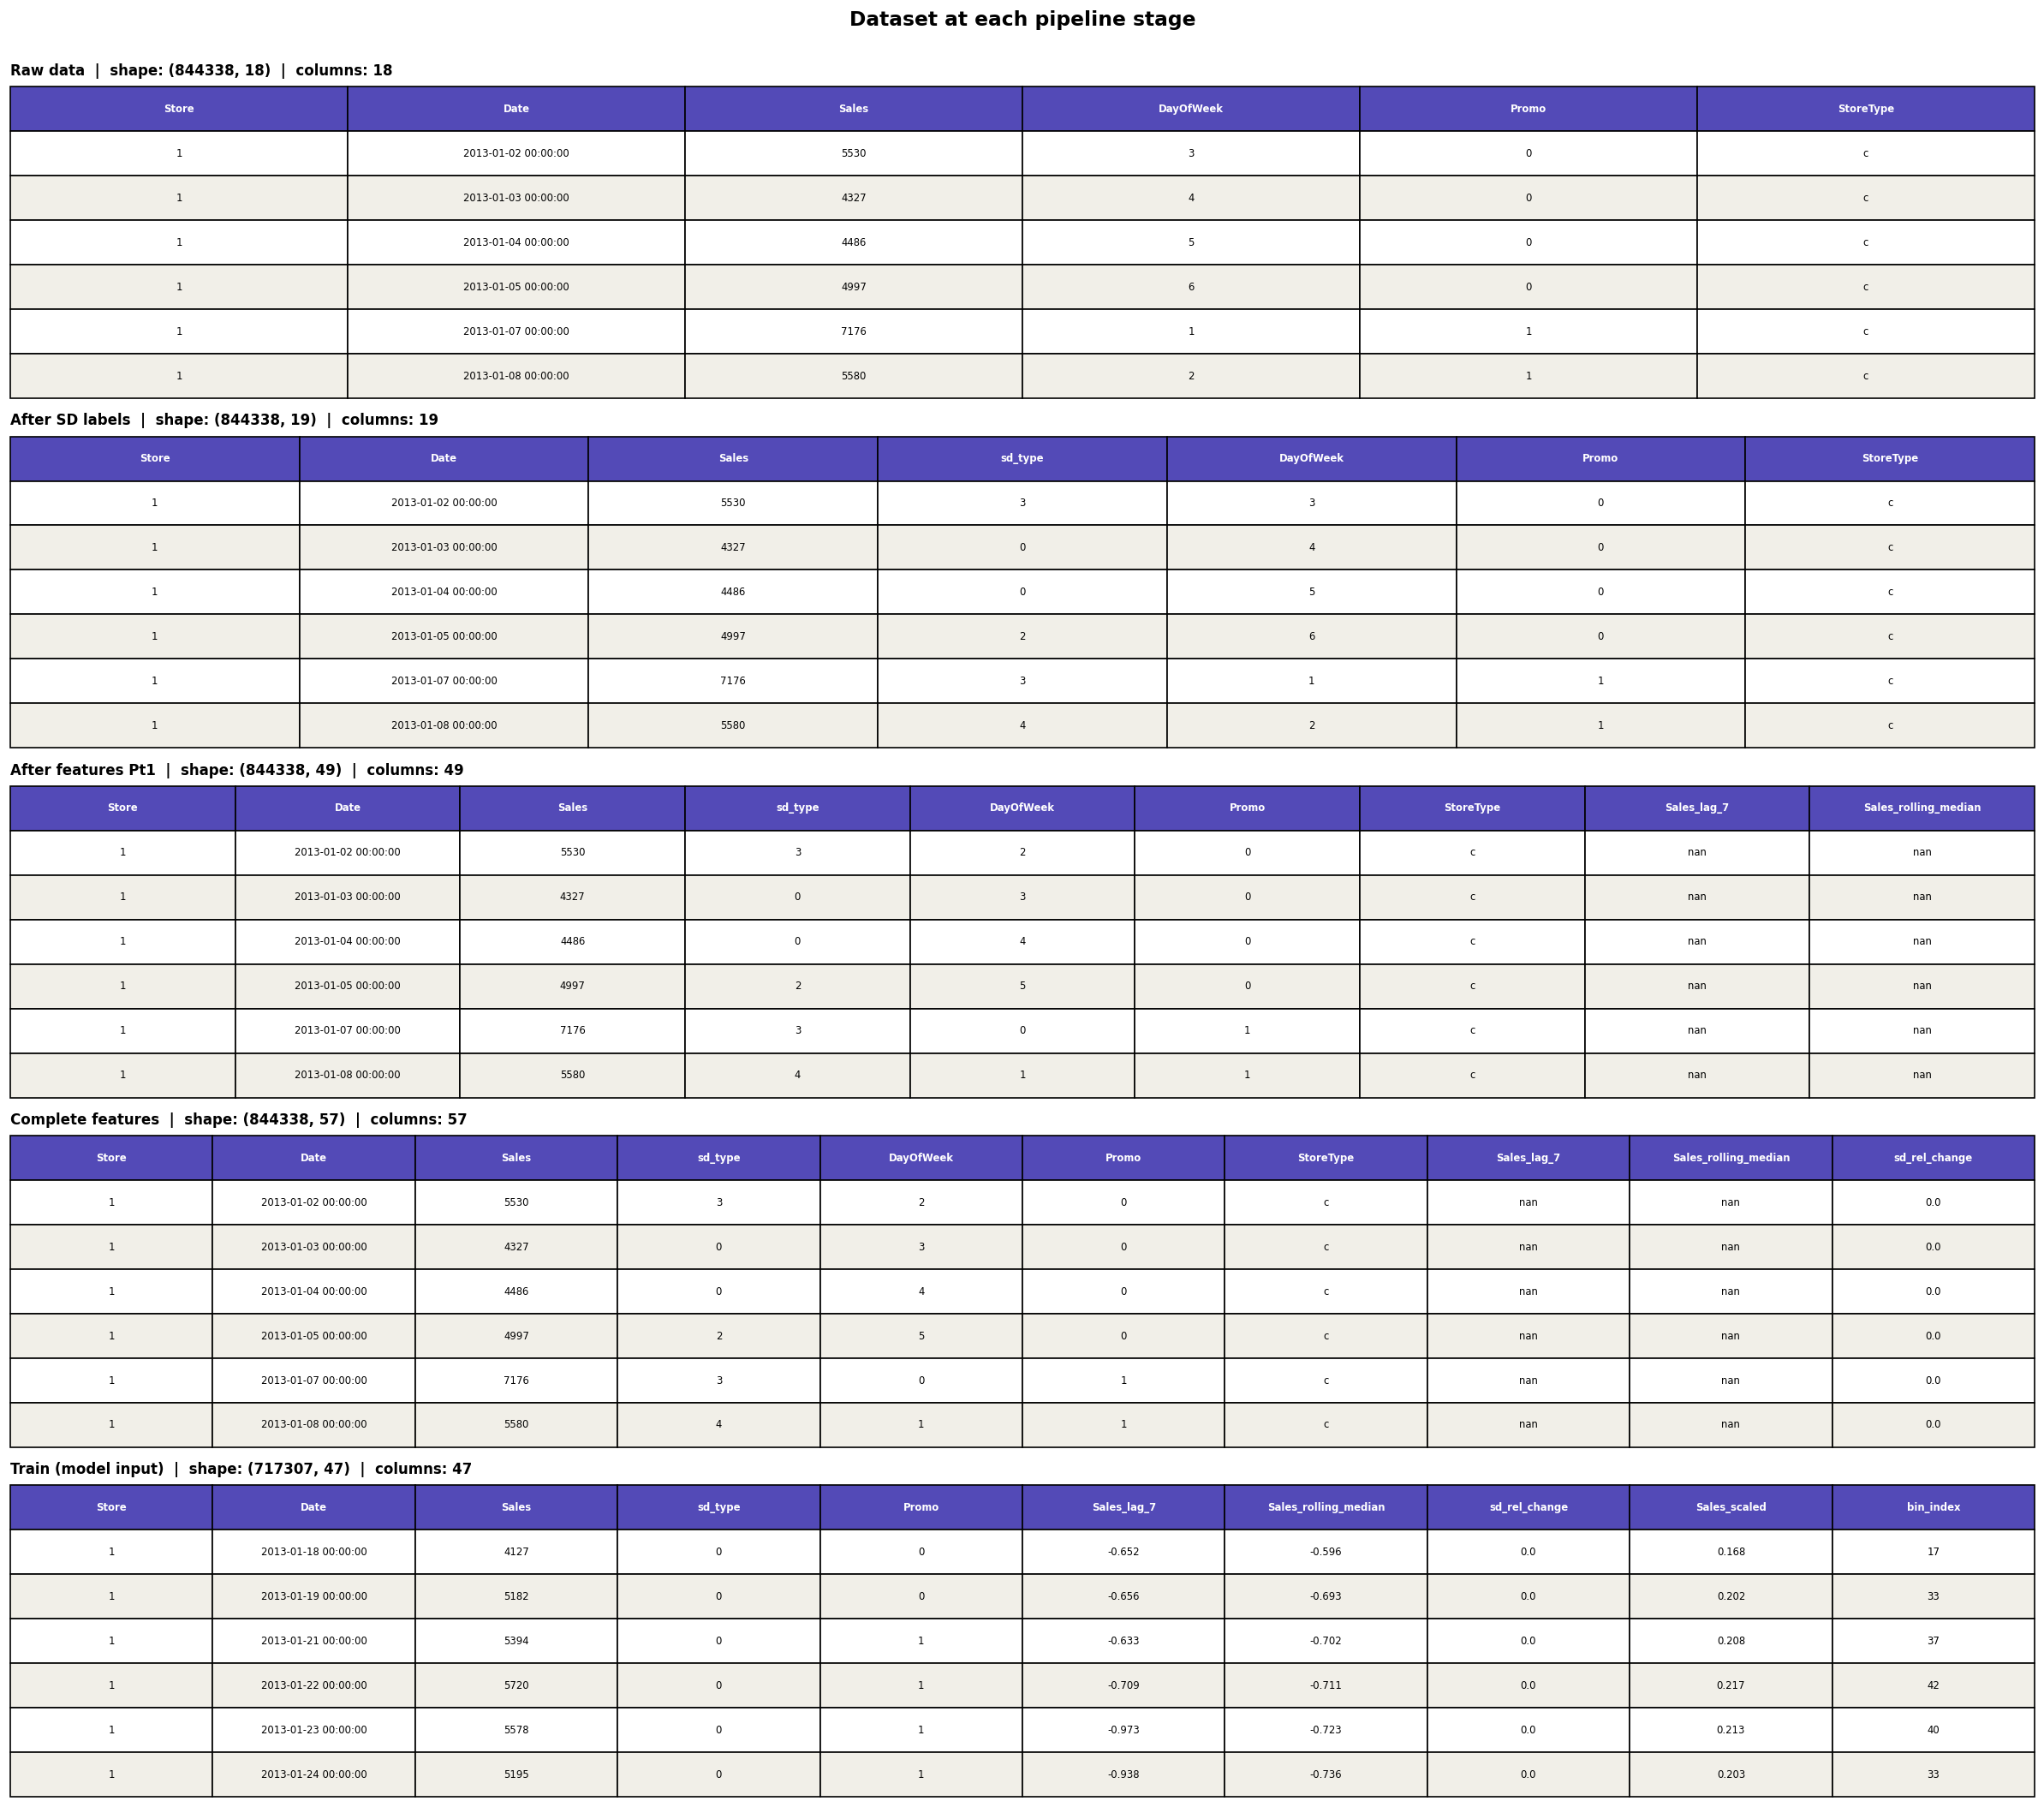


02_sales_distribution.png


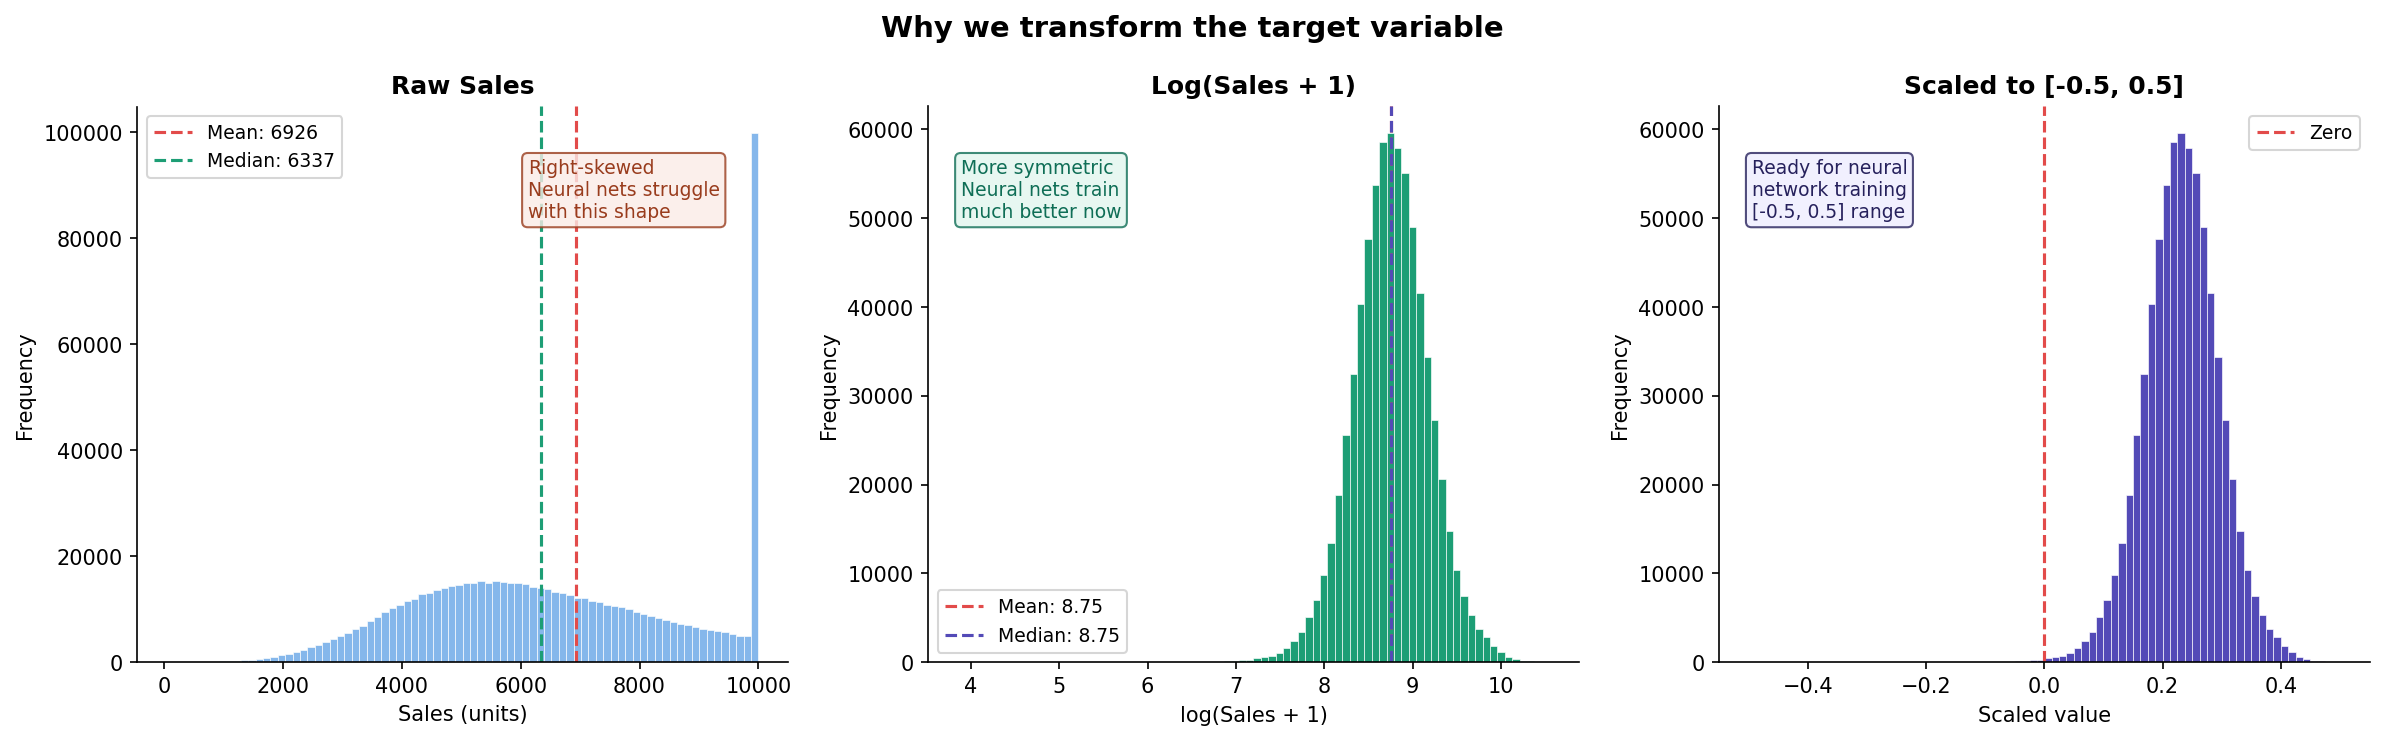


03_weekly_seasonality.png


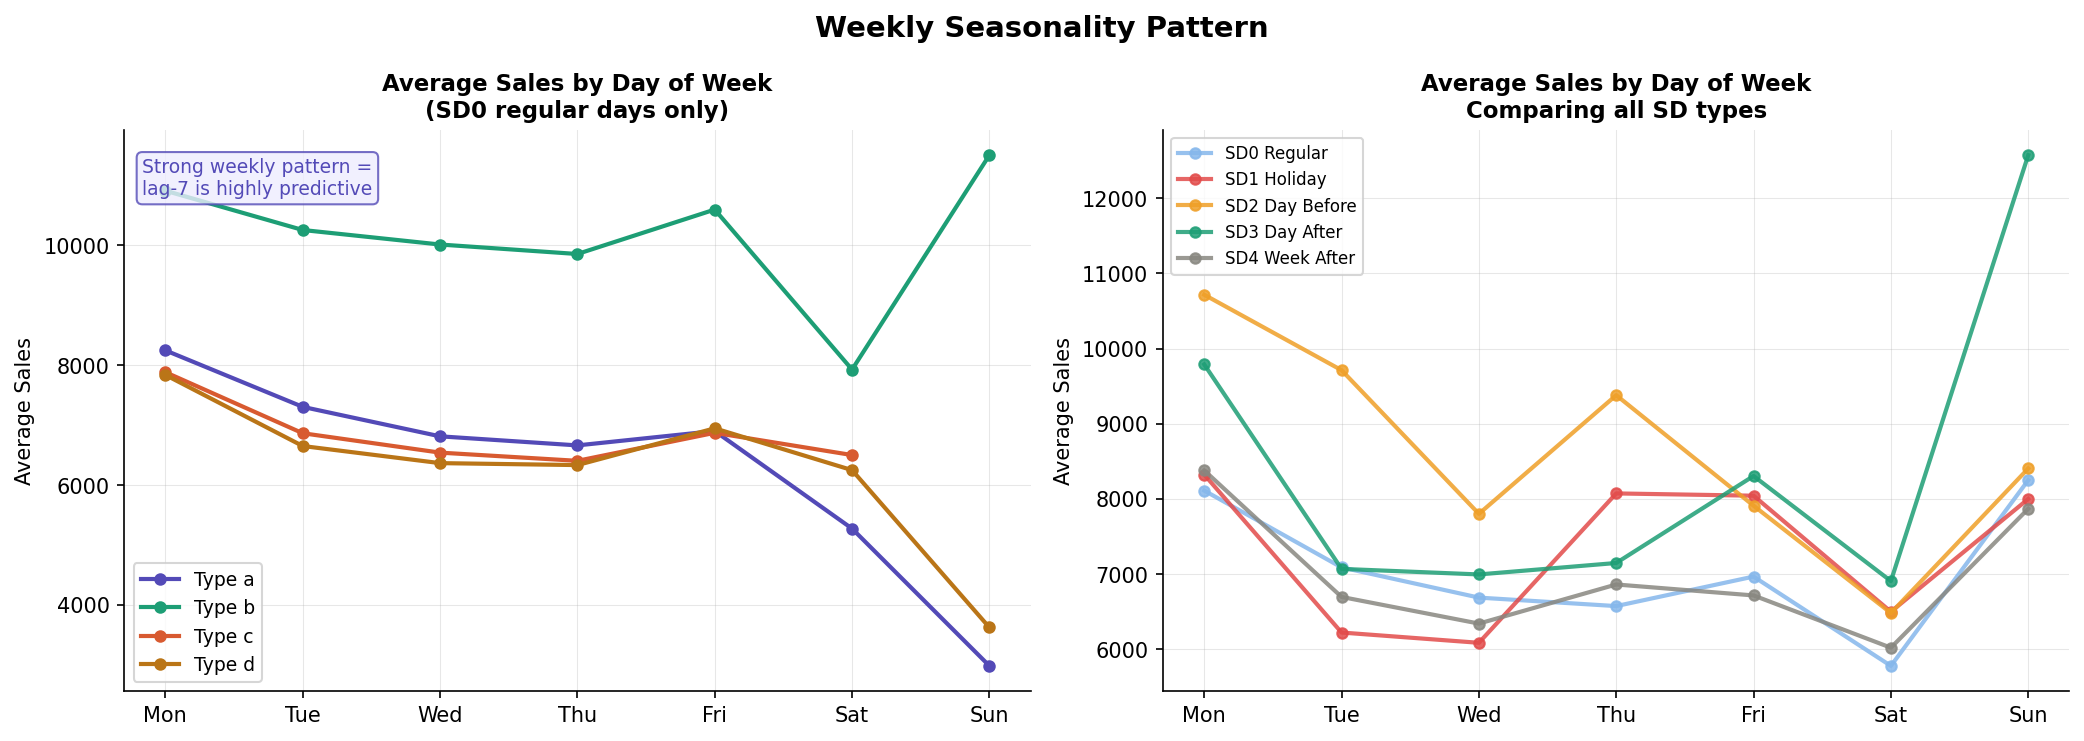


04_lag_autocorrelation.png


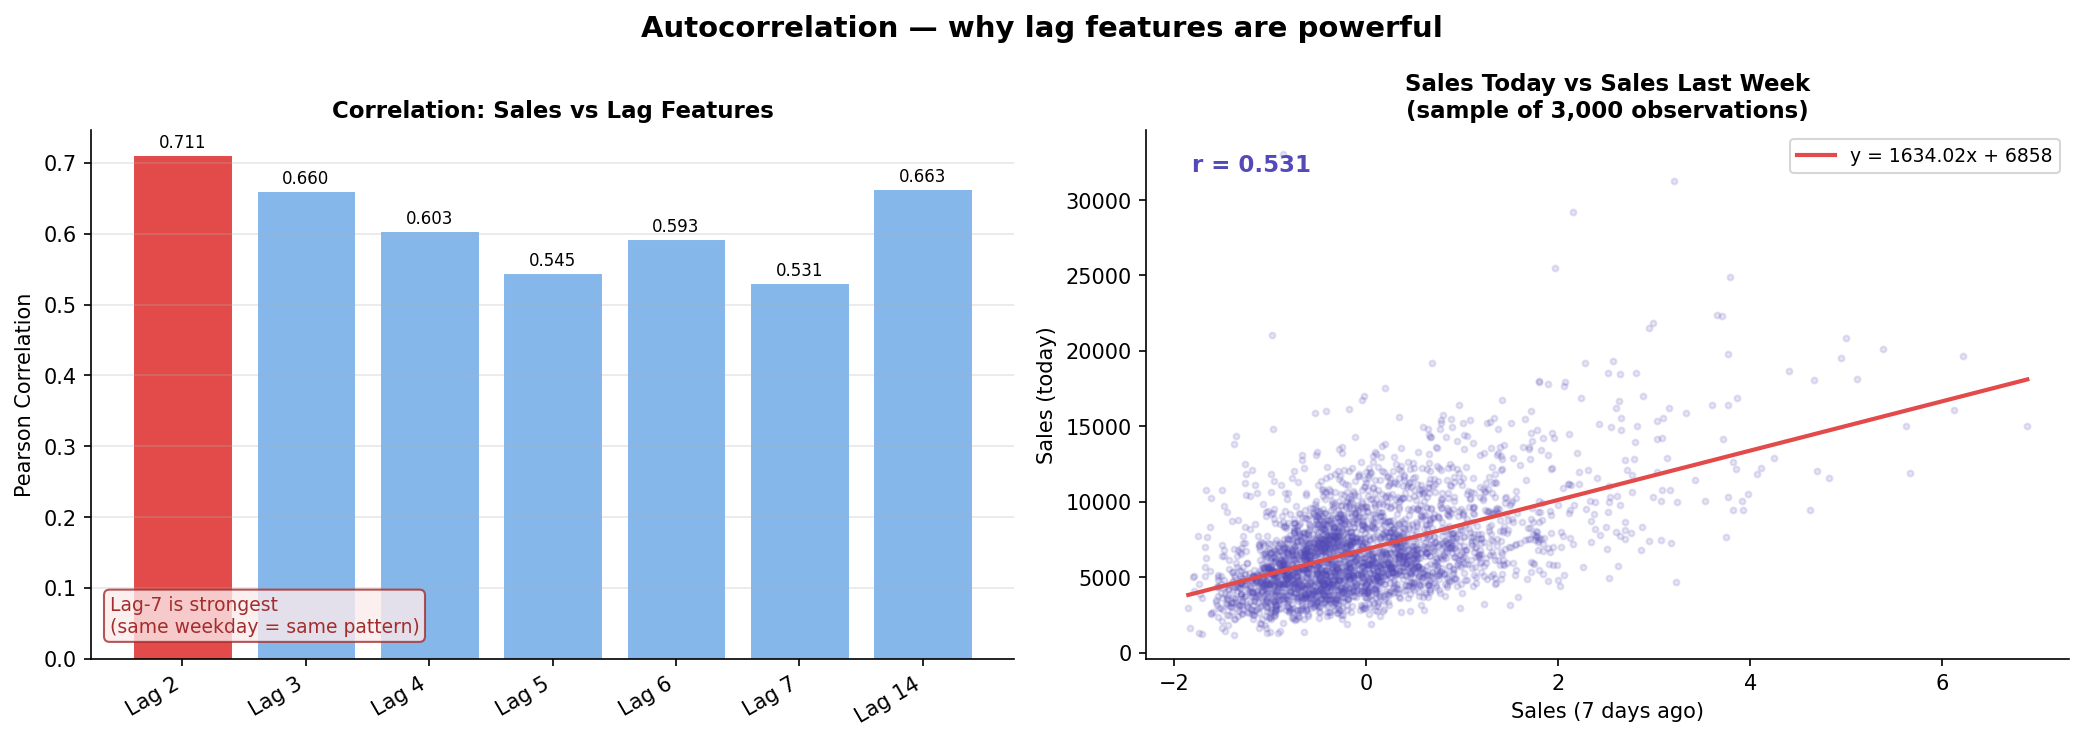


05_cyclical_encoding.png


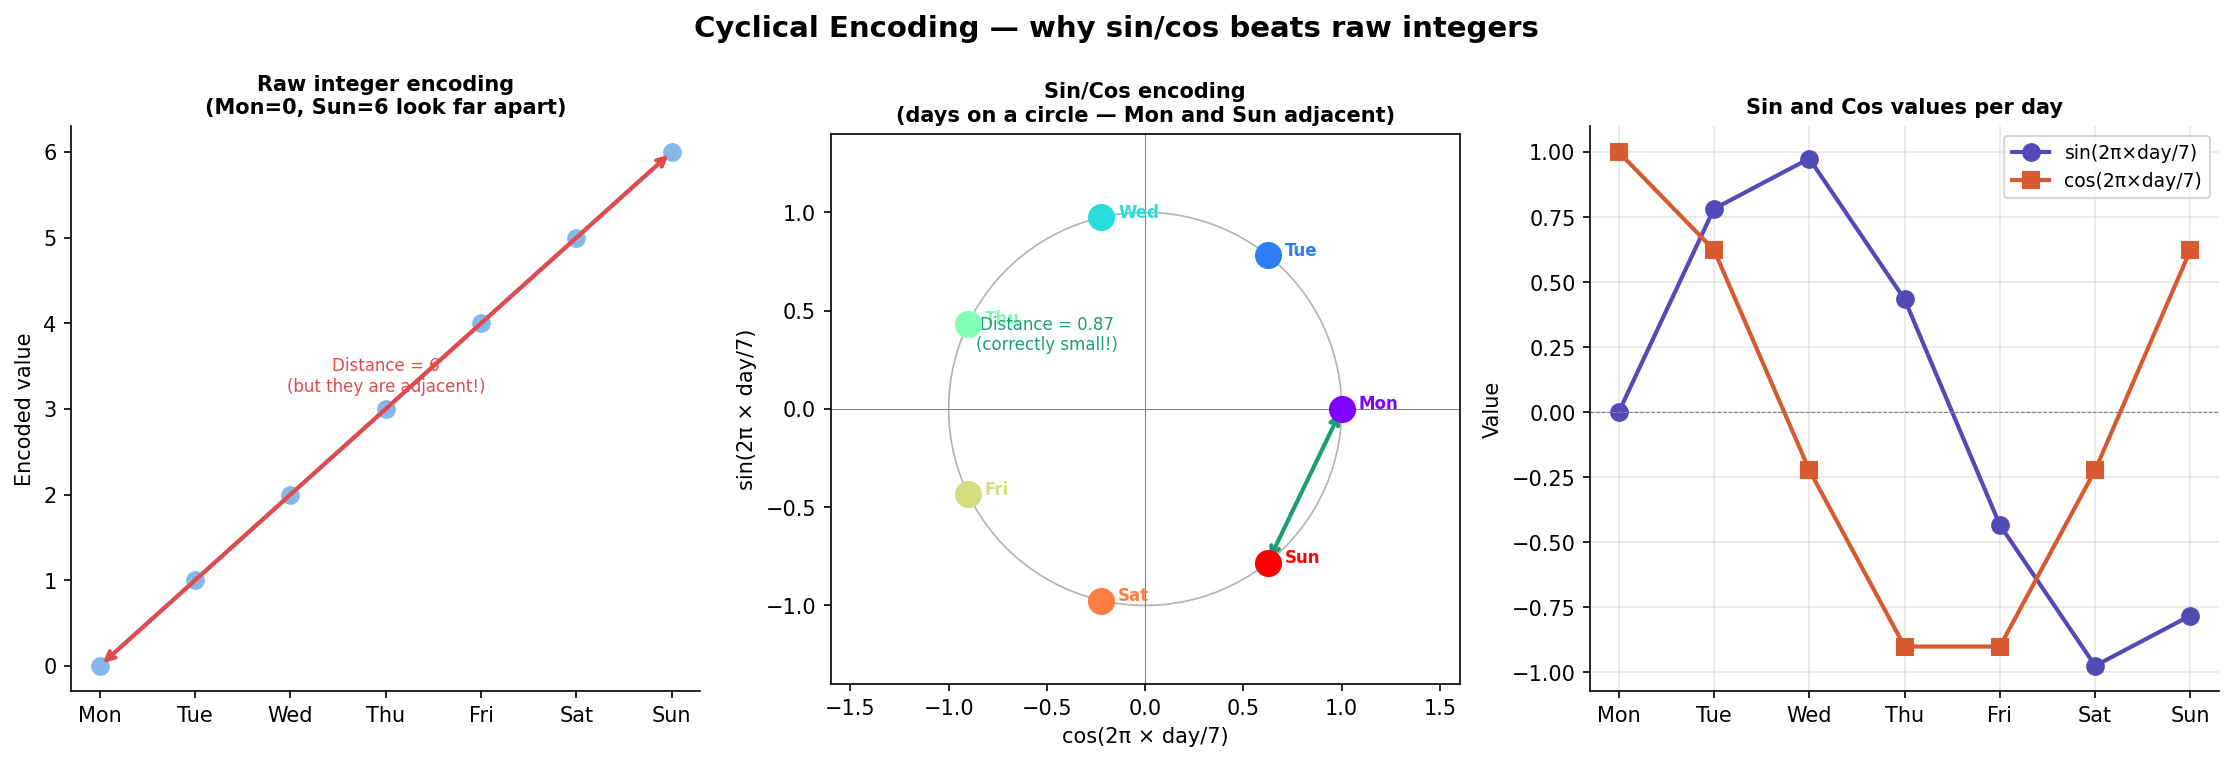


06_sd_calendar.png


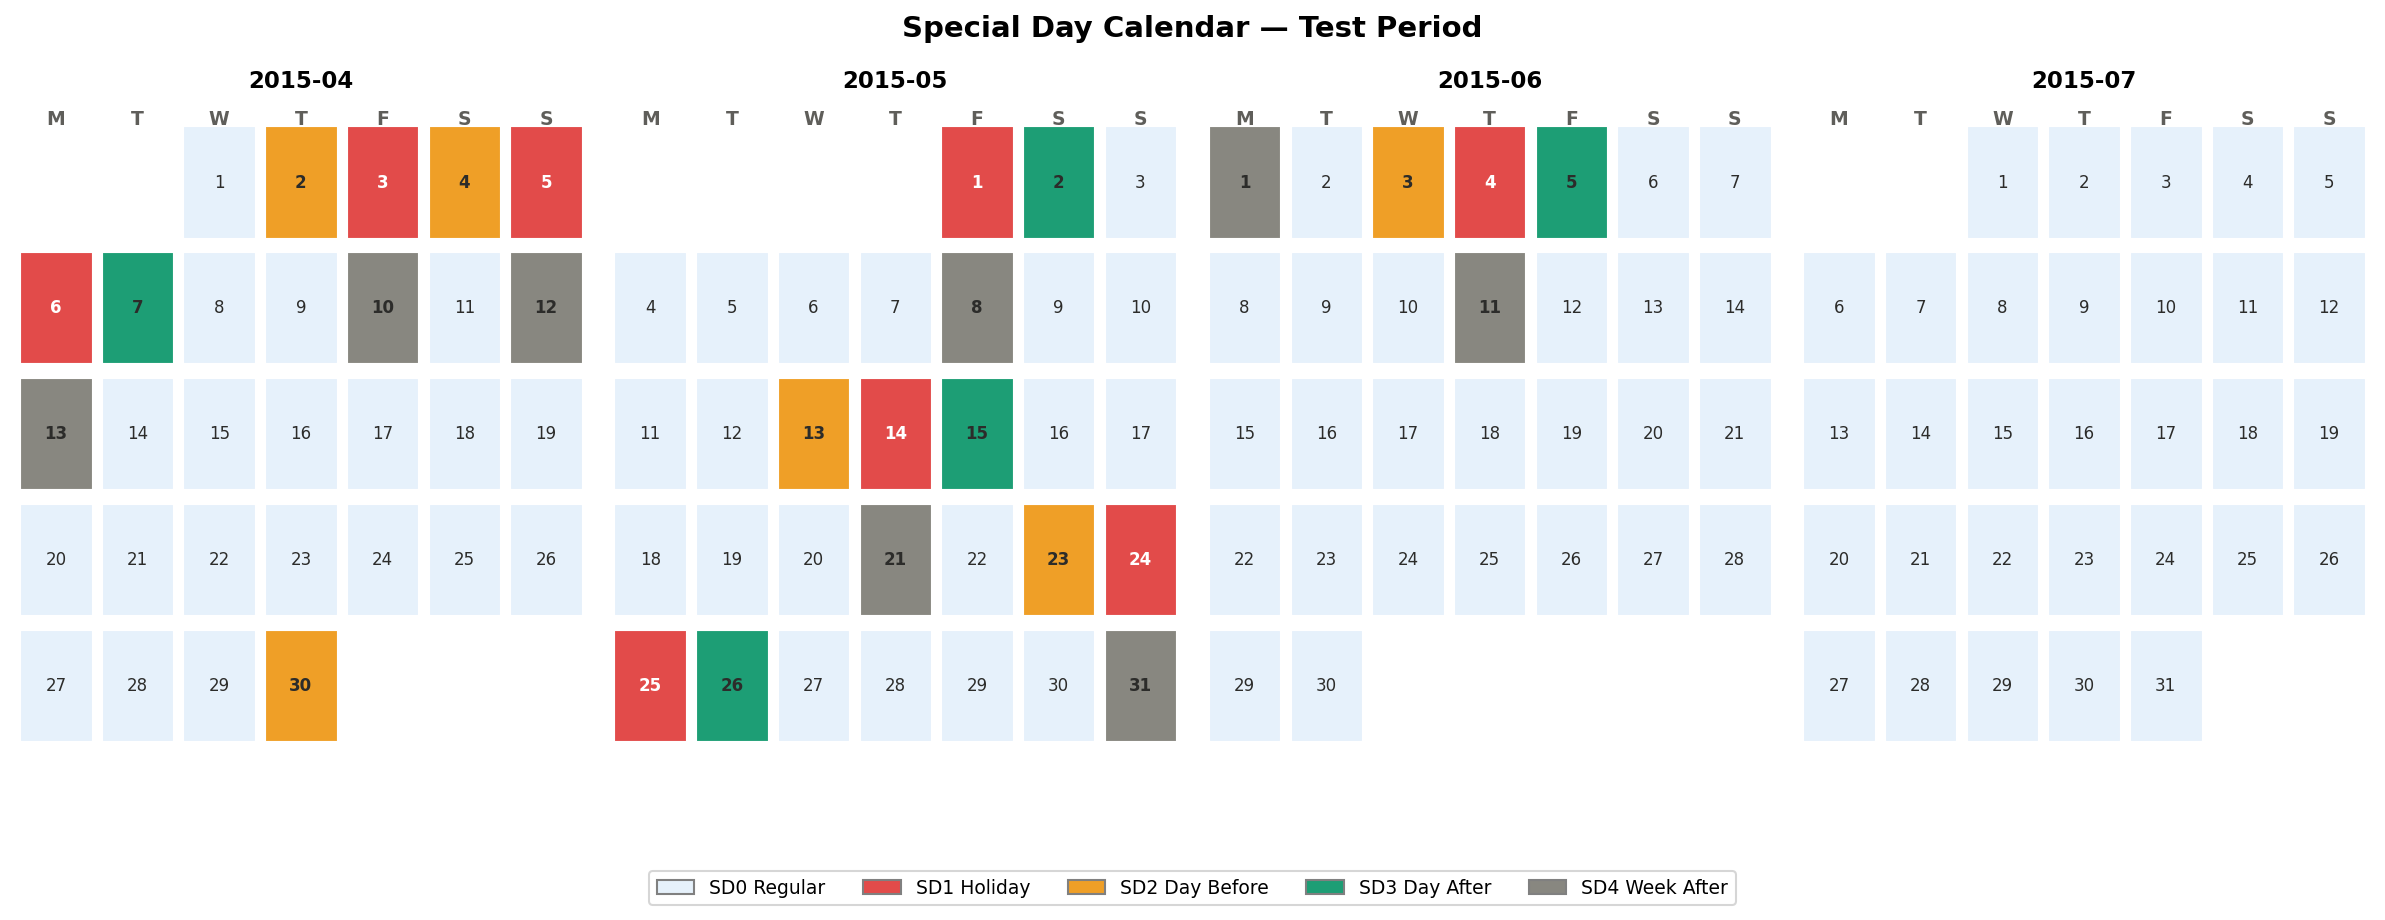


07_error_timeline.png


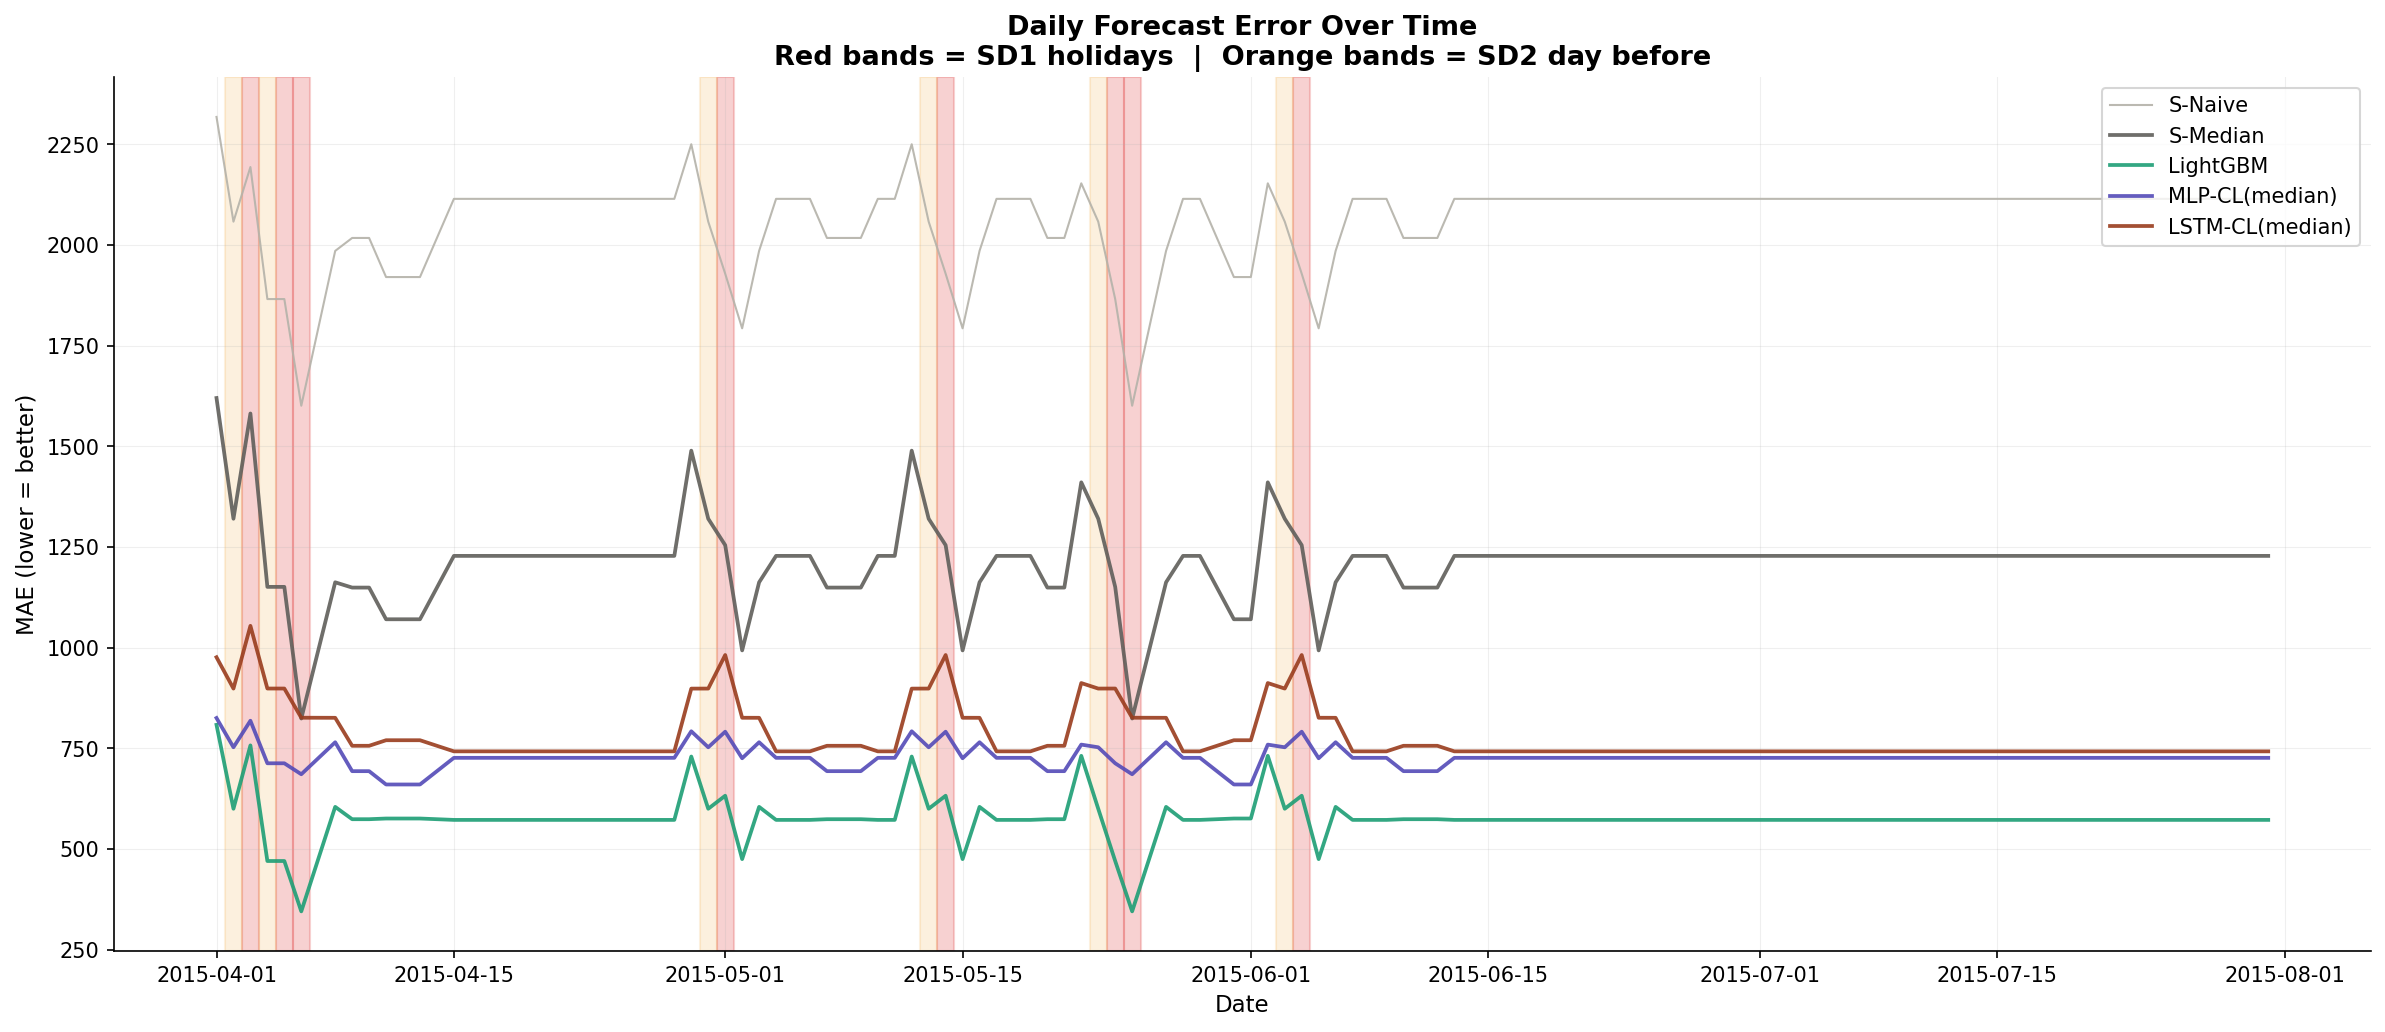


08_cl_median_vs_max.png


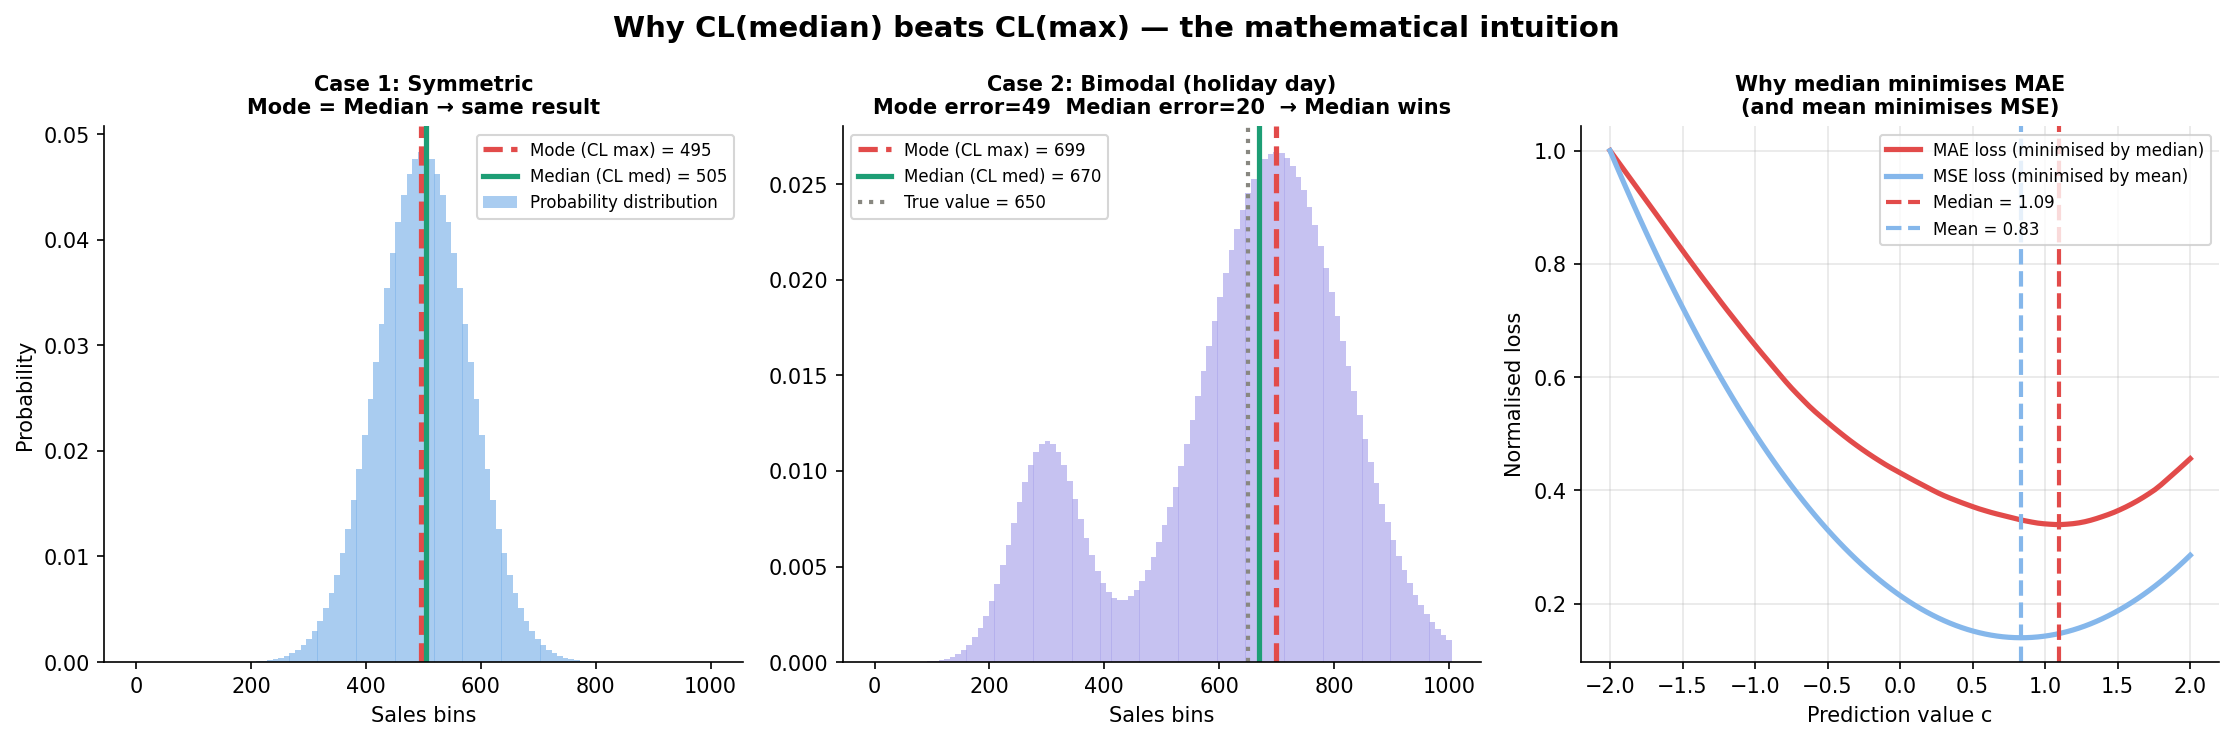


09_radar_chart.png


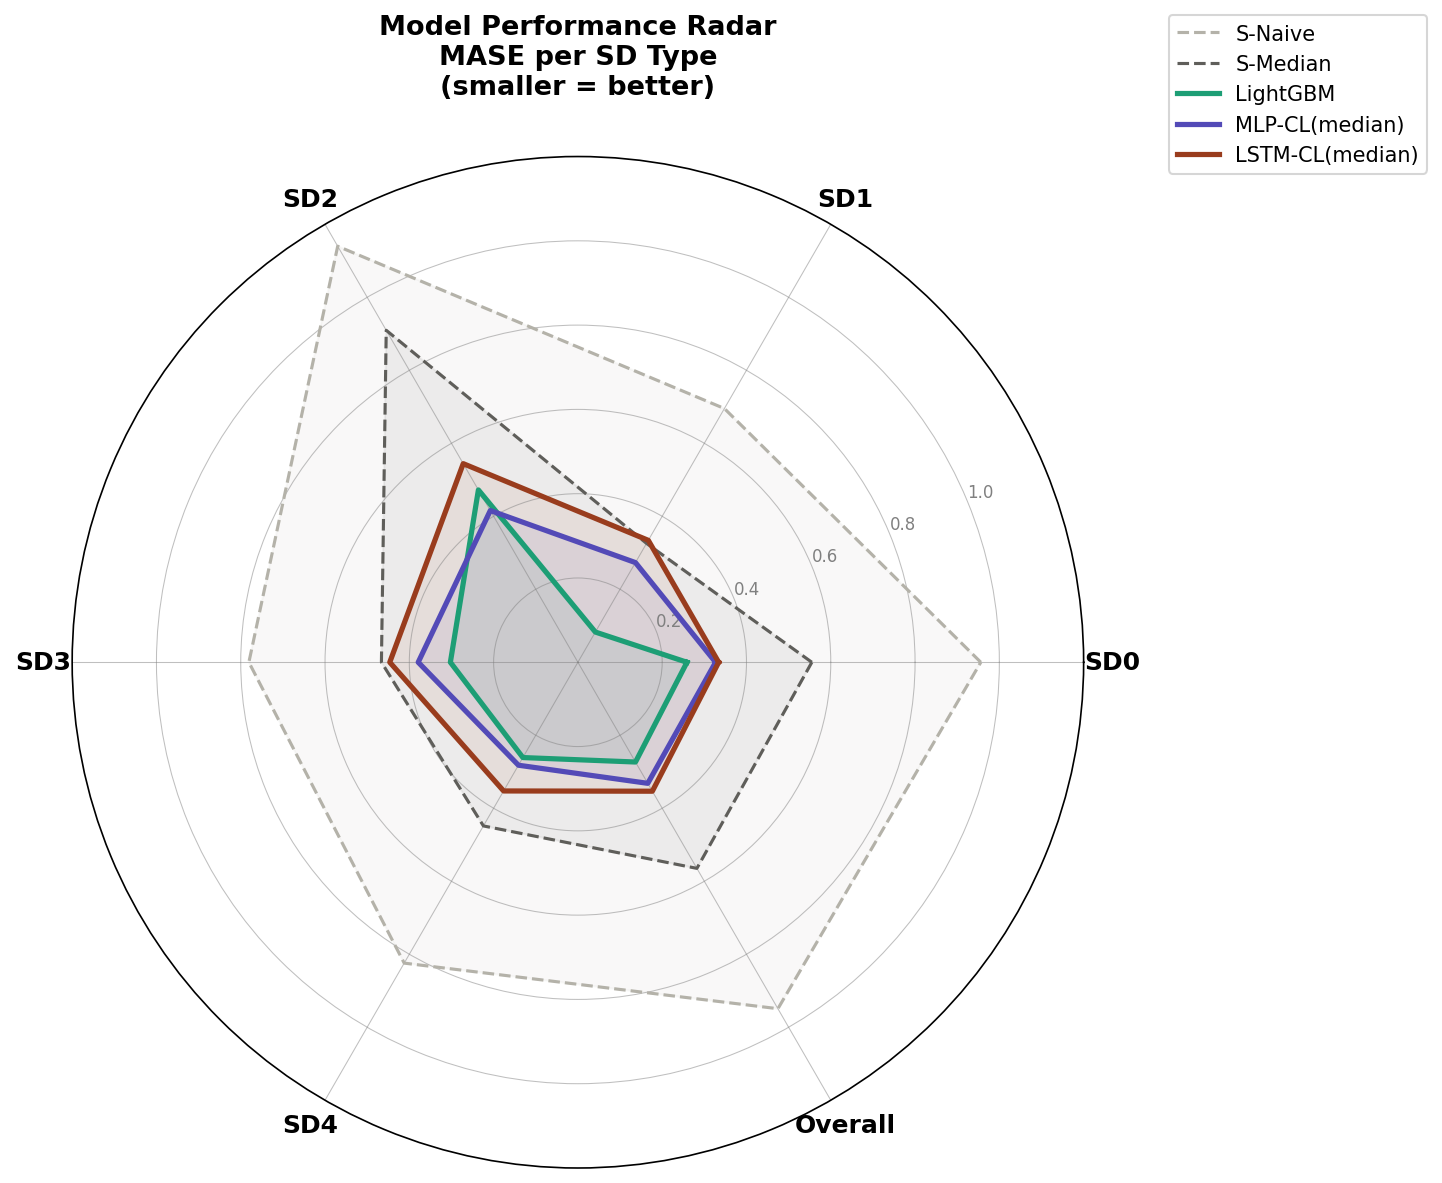


12_gradient_boosting_explained.png


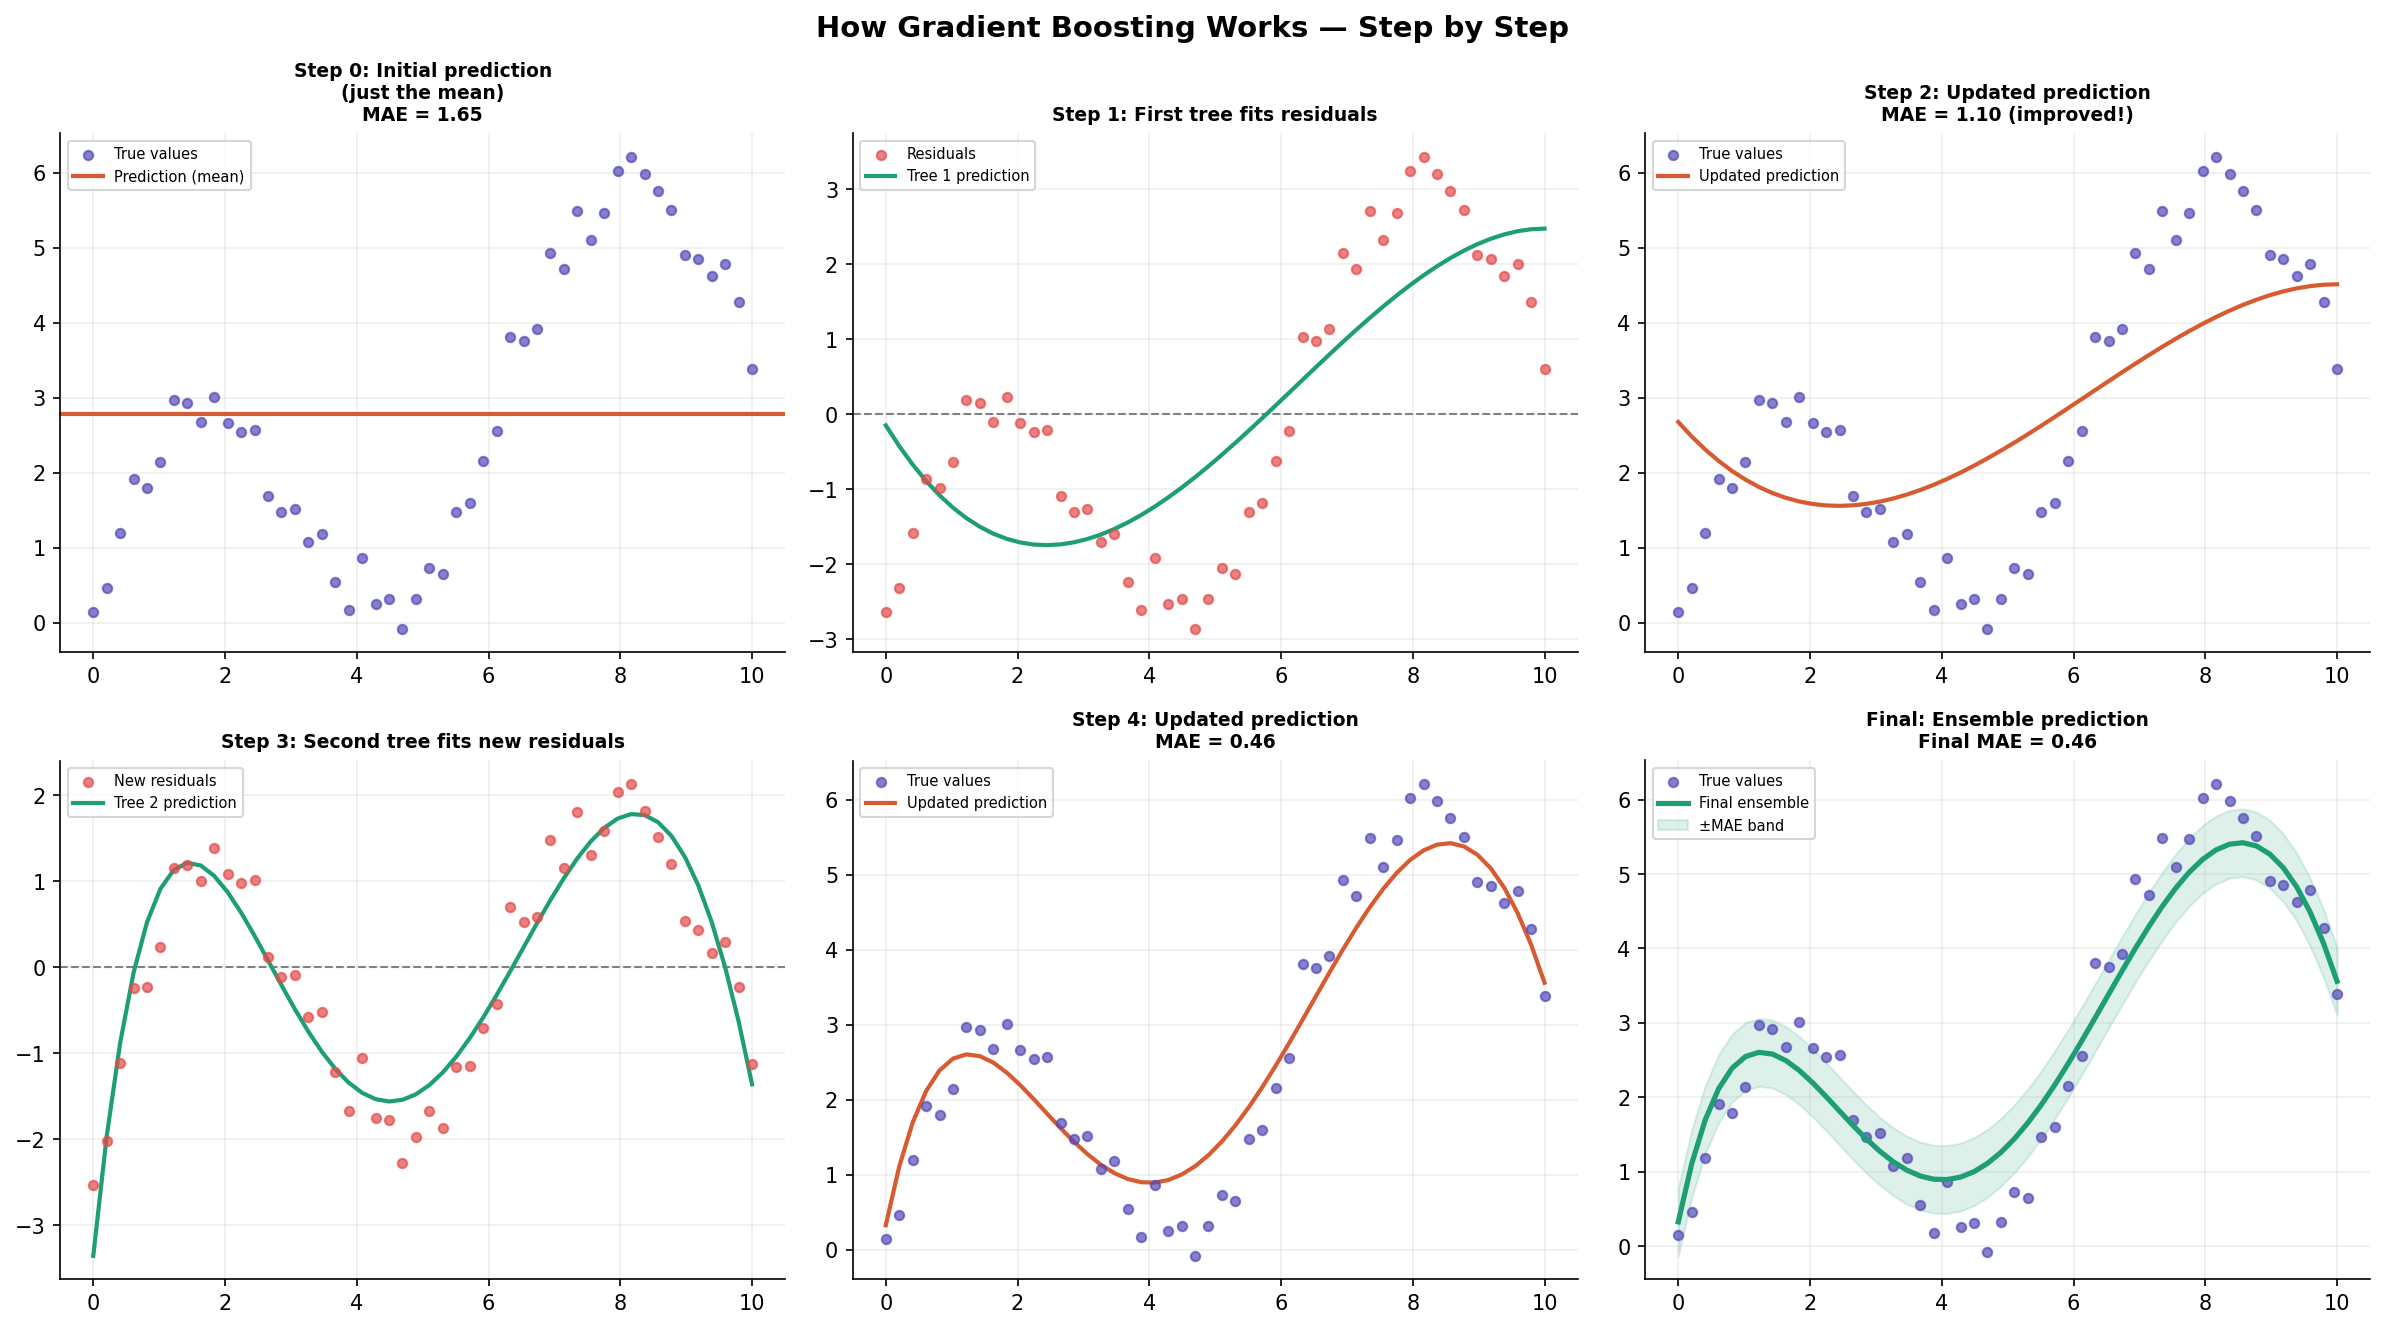


13_lstm_memory.png


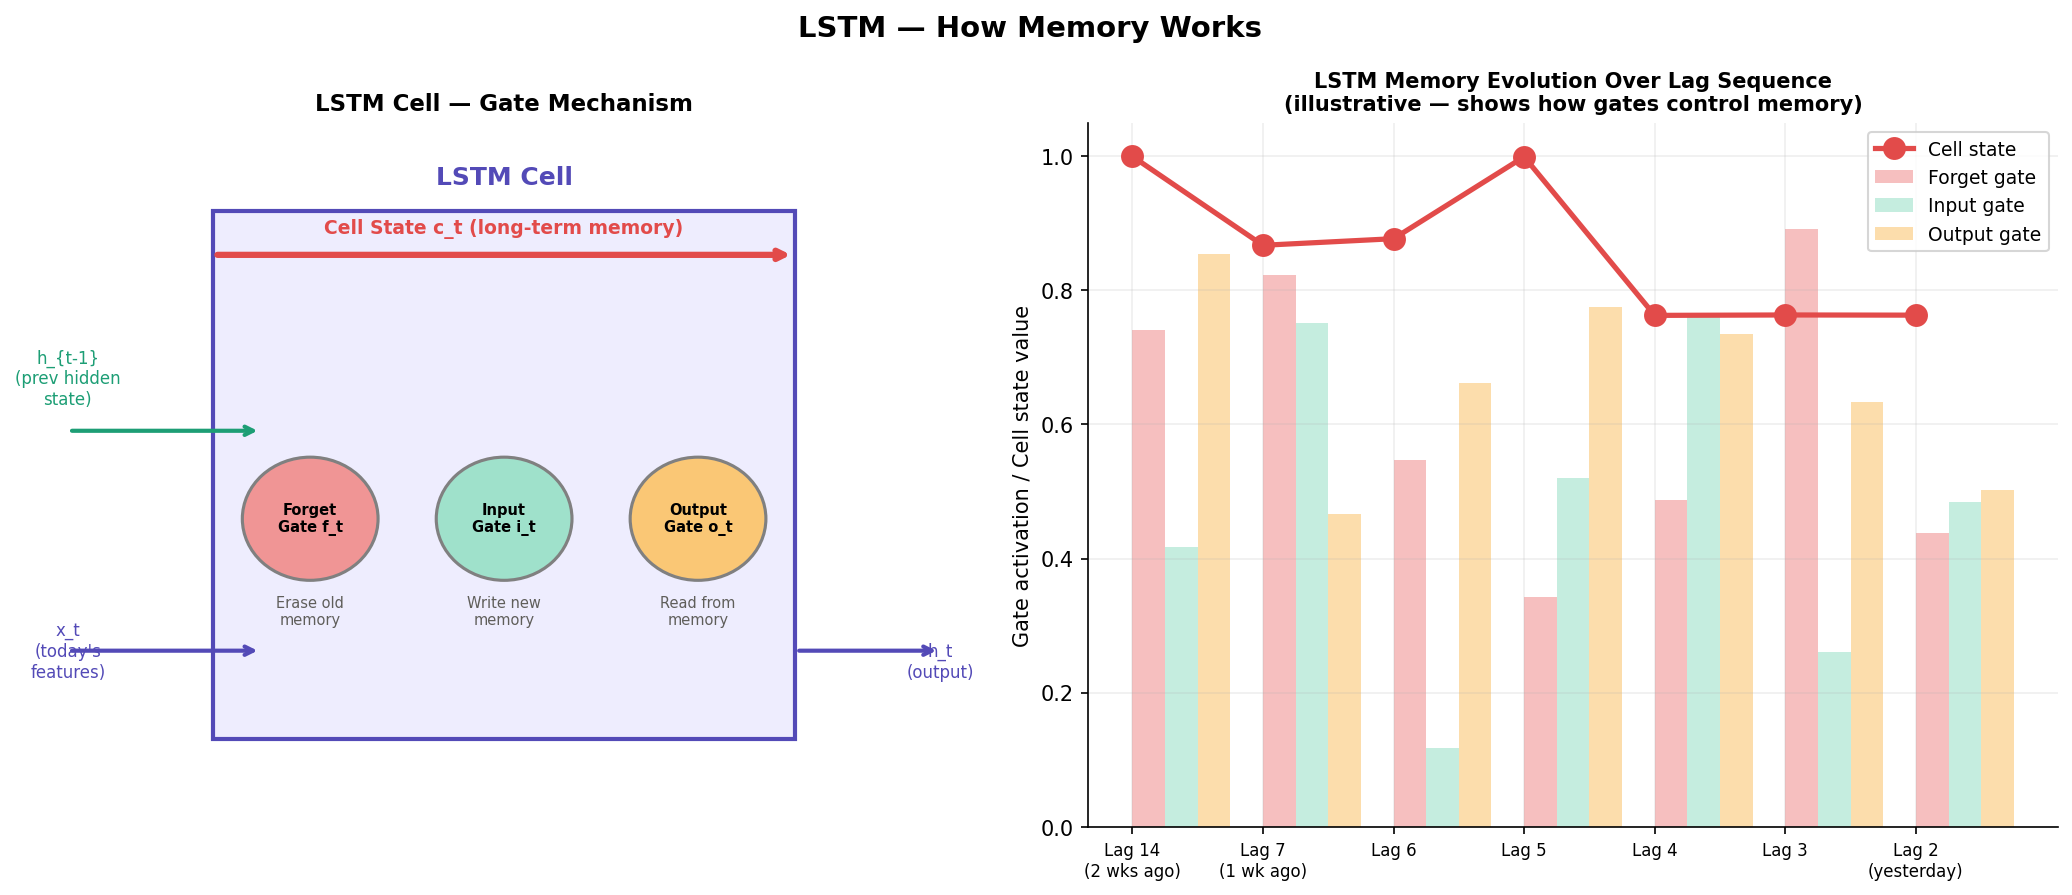

In [41]:
from IPython.display import Image, display
import os

adv_dir = "/kaggle/working/retail_forecasting/outputs/plots/advanced"

for fname in sorted(os.listdir(adv_dir)):
    if fname.endswith(".png"):
        print(f"\n{'='*50}")
        print(fname)
        print('='*50)
        display(Image(os.path.join(adv_dir, fname)))